# Abstract

본 연구는 미국 전역의 교통사고 데이터를 활용하여 사고 심각도(Severity)를 예측하는 기계학습 모델을 구축하였다. 분석에는 시간적 요인(시간대, 계절), 기상 조건(기온, 시정, 강수량), 도로 기하구조(신호등, 교차로, 횡단보도 유무) 및 공간 정보 등 그룹으로 나눈 다각적인 설명 변수가 투입되었다. 데이터 불균형 환경에서도 인명 피해와 직결된 고위험 사고(Severity 4)를 탐지하는 데 주안점을 두었으며, 분석 결과 Kappa Statistic 0.5143 및 Severity 4 재현율(Recall) 29%를 달성하여 통계적 유효성을 검증하였다. 이는 정밀도보다는 위험 상황의 미탐지(False Negative)를 최소화하는 데 최우선 가치를 둔 결과이다. 본 모델은 운전자 경보 시스템 및 교통 정책 수립을 위한 기초 자료로서의 활용 가능성을 시사하나, 정적 도로 정보와 기상 변수에 주로 의존한다는 한계가 있다. 향후 실시간 교통량(Traffic Volume)이나 평균 주행 속도와 같은 동적 데이터(Dynamic Data)를 결합하고, 컴퓨팅 자원을 확충하여 770만 건(7.7 million records)의 전체 데이터를 학습한다면 모델의 정교함을 획기적으로 제고할 수 있을 것이다.

# 1. 데이터 선정

###1.1 기계학습으로 해결하고자 하는 문제 (과제/목표)

이번 프로젝트에서는 미국 전역의 교통사고 데이터를 활용하여, 사고의 심각도(Severity)를 예측하는 분류 모델을 구축하는 것이 목표이다. 사고 당시의 기상 정보, 도로 조건, 시간대 등 다양한 요인을 종합적으로 고려하여 사고가 경미한 수준인지, 심각한 상황으로 이어질 수 있는지를 사전에 예측하고자 한다. 건축사회환경공학부에 재학 중인 나는, 이번 학기 초 수업에서 교수님이 강조하신 “기계학습은 도메인 지식과 결합되어야 실질적인 통찰을 줄 수 있다”는 메시지를 바탕으로, 교통공학에서의 실질적인 활용 가능성을 직접 탐구해보고자 이 주제를 선정했다.

###1.2 데이터셋 설명 및 출처

사용한 데이터는 Kaggle에서 제공하는 US Accidents Dataset이며, 2016년부터 2023년까지 미국 49개 주에서 발생한 약 770만 건의 사고 데이터를 포함한다. 사고의 발생 시간, 위치, 도로 특성, 기상 조건, 가시거리, 신호기 여부 등 ID를 제외하면 45개의 feature로 구성되어 있으며, 분류 타깃인 Severity(1~4단계) 변수도 명확히 포함되어 있다. 본 데이터셋은 텀프로젝트 요구사항인 최소 10개 이상의 feature와 5,000건 이상의 instance를 충족하며, 사고 위험 요인을 교통공학적 시각에서 해석하고자 하는 본 프로젝트에 적합하다.

분석 효율성과 연산 자원 문제를 고려하여, 본 프로젝트에서는 Kaggle에서 제공하는 동일 데이터셋의 샘플 버전(500,000건)을 사용하였다. 이 샘플 데이터는 원본 데이터에서 추출된 대표 샘플로 구성되어 있어 구조와 feature는 동일하게 유지되며, 데이터의 특성과 패턴을 충분히 반영할 수 있다. 또한 Kaggle에서도 해당 샘플을 보다 효율적인 분석 및 처리 용도로 활용할 수 있도록 별도로 제공하고 있어, 텀프로젝트 목적에 적합한 선택이라 판단하였다.

In [8]:
# 필수 라이브러리 임포트
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import random

# 데이터셋 로드
#df_raw = pd.read_csv('/content/drive/MyDrive/US_Accidents_March23_sampled_500k.csv')
df_raw = pd.read_csv('./US_Accidents_March23_sampled_500k.csv')

In [9]:
df_raw.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-2047758,Source2,2,2019-06-12 10:10:56,2019-06-12 10:55:58,30.641211,-91.153481,NaN,NaN,0.000,...,False,False,False,False,True,False,Day,Day,Day,Day
1,A-4694324,Source1,2,2022-12-03 23:37:14.000000000,2022-12-04 01:56:53.000000000,38.990562,-77.399070,38.990037,-77.398282,0.056,...,False,False,False,False,False,False,Night,Night,Night,Night
2,A-5006183,Source1,2,2022-08-20 13:13:00.000000000,2022-08-20 15:22:45.000000000,34.661189,-120.492822,34.661189,-120.492442,0.022,...,False,False,False,False,True,False,Day,Day,Day,Day
3,A-4237356,Source1,2,2022-02-21 17:43:04,2022-02-21 19:43:23,43.680592,-92.993317,43.680574,-92.972223,1.054,...,False,False,False,False,False,False,Day,Day,Day,Day
4,A-6690583,Source1,2,2020-12-04 01:46:00,2020-12-04 04:13:09,35.395484,-118.985176,35.395476,-118.985995,0.046,...,False,False,False,False,False,False,Night,Night,Night,Night


In [10]:
# 데이터 형태(Shape) 및 컬럼명 확인
print(df_raw.shape)
print(df_raw.columns)

(500000, 46)
Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')


# 2. 문제 설정 및 전체적인 과제 설계

###2.1 기계학습 모델의 활용 방안

본 프로젝트는 사고 발생 당시의 다양한 환경 데이터를 입력받아 사고의 심각도(Severity)를 예측하는 모델을 구축하는 것이다. 이를 통해 기계학습 모델을 교통공학적 관점에서 다음과 같이 활용하고자 한다.

- 운전자 Alertness(주의 수준) 강화 및 사전 경보 시스템: 단순히 사고 발생 가능성을 예측하는 것을 넘어, 사고 발생 시 그 결과가 심각할 것으로 예측되는 고위험 상황을 식별한다. 모델이 예측한 위험 구간 진입 전, 내비게이션이나 가변 정보 표지판(VMS)을 통해 운전자에게 경고를 제공함으로써 운전자의 Alertness(주의 수준)를 높인다. 이는 운전자의 인지-반응 시간(Perception-Reaction Time)을 단축시켜 사고를 미연에 방지하거나 피해를 경감시키는 데 기여할 수 있다.

- 데이터 기반 교통 안전 요인 분석: 모델의 Feature Importance(변수 중요도) 분석을 통해, 수많은 환경 변수 중 사고 심각도에 결정적인 영향을 미치는 핵심 요인을 파악한다. 이 분석 결과는 도로 기하구조 개선, 안전 시설물 확충 등 데이터에 근거한 실질적인 교통 정책 수립 및 예산 배분의 기초 자료로 활용될 수 있다.

###2.2 해당 문제에서 현재 사용되고 있는 방법/해결책

교통사고 심각도(Severity) 분석은 교통공학 분야의 주요 연구 주제 중 하나이며, 기존에는 통계적 기반의 회귀 분석 방법들이 주로 사용되어 왔다.

전통적인 교통공학 연구에서는 모델의 해석 용이성을 중시하여, 각 변수가 사고 심각도에 미치는 영향을 명확히 설명할 수 있는 선형 기반의 통계 모형을 주로 사용해 왔다. 이는 사고 요인을 규명하고, 현상을 설명하는 데에는 효과적이지만 복잡한 현실 세계를 단순화하여 가정한다는 특징이 있다.

그러나, 실제 교통사고는 기상, 도로, 시간 등 수많은 요인들이 복합적으로 작용하여 발생하는 현상이다. 본 프로젝트에서 활용할 기계학습 모델은 이러한 복잡한 상호작용과 비선형적인 패턴을 학습하기에 유리하다. 따라서, 단순한 설명을 넘어, 실제 현장에서 사고 심각도를 정확히 예측하고 대응해야 하는 실제 적용의 측면에서는 기계학습의 접근 방식이 보다 높은 효과를 기대할 수 있으리라 생각한다.

###2.3 문제 정의

본 프로젝트는 입력된 데이터(X)를 바탕으로 사고 심각도(Y)를 예측하는 문제로, Y가 연속적인 값이 아닌 1, 2, 3, 4의 이산적인 범주를 가지고 주어지므로 지도 학습 중 다중 클래스 분류 문제로 정의한다.

In [11]:
# 타겟 변수(Severity) 클래스 분포 확인
# 클래스별 개수 계산
severity_counts = df_raw['Severity'].value_counts().sort_index()

# 클래스별 비율(%) 계산
severity_ratio = df_raw['Severity'].value_counts(normalize=True).sort_index() * 100

print("Severity Class Counts")
print(severity_counts)
print("\nSeverity Class Proportions (%)")
print(severity_ratio)

Severity Class Counts
Severity
1      4274
2    398142
3     84520
4     13064
Name: count, dtype: int64

Severity Class Proportions (%)
Severity
1     0.8548
2    79.6284
3    16.9040
4     2.6128
Name: proportion, dtype: float64


###2.4 성능 지표 선택

본 프로젝트의 데이터셋은 전체 사고의 대다수가 경미한 사고(Severity 2)에 집중된 데이터 불균형의 특징을 가지며, 예측해야 할 타겟이 4개의 범주인 다중 클래스 분류 문제이다.

정확도는 불균형 데이터에서 성능을 과대평가할 위험이 있으므로, 도메인 특성을 고려하여 다음 3가지 지표를 선정하였다.

1. Macro F1 Score

Macro F1 Score는 각 클래스별로 Precision과 Recall의 조화 평균을 계산한 후, 이를 평균낸 값이다.

데이터가 불균형할 때, 데이터 수가 많은 클래스(Severity 2) 위주로 학습하면 전체 정확도는 높으나 소수 클래스의 예측력은 현저히 떨어질 수 있다. Macro 방식은 클래스별 데이터 수와 관계없이 모든 클래스에 동등한 가중치를 부여하므로, 희소하지만 중요한 심각한 사고를 얼마나 잘 예측하는지 평가하기에 가장 적합한 지표 중 하나이다.

2. Kappa Statistic

Kappa Statistic은 관찰된 정확도에서 우연히 일치할 확률을 제외하여 보정한 통계랑이다.

불균형 데이터에서는 모델이 학습하지 않고 무조건 다수 클래스로만 찍어도 높은 정확도가 나올 수 있다. Kappa 통계량은 이러한 우연한 적중을 수치적으로 제거해준다. 즉, 모델이 단순히 통계적 분포에 기대지 않고, 기상이나 도로 조건 등 변수 간의 인과관계를 실제로 학습하여 예측하고 있는지 검증하는 데 필수적인 지표이다.

3. Accuracy

Accuracy는 전체 데이터 중 올바르게 분류된 데이터의 비율이다.

모델의 전반적인 분류 성능을 직관 적으로 파악하기 위한 기준으로 사용한다. 단, 앞서 언급한 불균형 데이터에서의 한계를 인지하고, 반드시 위의 두 지표와 병행하여 해석할 필요가 있다.

교통공학적 관점에서 사고 예측 모델의 핵심 목표는 발생 빈도가 높은 경미한 사고를 맞추는 것보다, 발생 빈도는 낮지만 인명 피해가 큰 '심각한 사고'를 사전에 탐지하여 이를 줄이고자 하는 것이다. 따라서 소수 클래스(특히 Severity 3, 4)에 대한 예측 성능을 민감하게 반영하는 Macro F1 Score, 그리고 데이터 쏠림에 의한 착시를 방지하는 Kappa Statistic을 사용하는 것이 본 문제의 목표 달성을 측정하는 가장 타당한 방법이라 생각한다.

###2.5 성능 목표 설정

본 프로젝트의 핵심 목표는 사고의 심각성을 미리 인지하여 운전자에게 경고하고, 사고를 방지하는 것이다. 따라서 전체적인 Accuracy도 중요하지만, 드물게 발생하는 '심각한 사고(Severity 3, 4)'를 놓치지 않고 탐지해내는 능력이 필수적이다. 이를 위해 소수 클래스의 성능을 반영하는 Macro F1-Score와 오분류 양상을 보여주는 Confusion Matrix를 선정하였으며, 이는 문제의 목표와 정확히 일치한다.

Baseline 설정: 데이터의 대부분을 차지하는 'Severity 2'로만 모든 예측을 수행하는 모델(Majority Class Classifier)보다는 성능이 우수해야 의미가 있다.

정량적 목표:

1. Accuracy: Baseline의 정확도를 상회하는 75% 이상을 목표로 한다.

2. Macro F1-Score: 불균형 데이터를 고려하여 무작위 추측(Random Guess) 수준을 넘어서는 0.5 이상을 최소 목표로 설정한다.

3. Recall (Severity 3, 4): 심각한 사고에 대한 재현율(Recall)을 중점적으로 개선하여, 실제 위험 상황을 놓치는 비율을 최소화한다.

# 3. 데이터 탐색 및 분석(EDA)

###3.1 데이터셋 개요 및 변수 설명

In [12]:
# 분석 및 전처리를 위한 데이터 복사
data = df_raw.copy()

# Random Seed 고정 (결과 재현성 확보)
# 파이썬 기본 시드 고정
random.seed(42)
# 넘파이(Numpy) 시드 고정
np.random.seed(42)

# 데이터 구조 및 기술 통계량 확인
print(data.shape)
data.info()
data.describe().T

(500000, 46)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     500000 non-null  object 
 1   Source                 500000 non-null  object 
 2   Severity               500000 non-null  int64  
 3   Start_Time             500000 non-null  object 
 4   End_Time               500000 non-null  object 
 5   Start_Lat              500000 non-null  float64
 6   Start_Lng              500000 non-null  float64
 7   End_Lat                279623 non-null  float64
 8   End_Lng                279623 non-null  float64
 9   Distance(mi)           500000 non-null  float64
 10  Description            499999 non-null  object 
 11  Street                 499309 non-null  object 
 12  City                   499981 non-null  object 
 13  County                 500000 non-null  object 
 14  State                  

,count,mean,std,min,25%,50%,75%,max
Severity,500000.0,2.212748,0.486661,1.000000,2.000000,2.000000,2.000000,4.000000
Start_Lat,500000.0,36.206421,5.071411,24.562117,33.416823,35.832147,40.082443,48.999569
Start_Lng,500000.0,-94.736583,17.405761,-124.497420,-117.233047,-87.794365,-80.359601,-67.484130
End_Lat,279623.0,36.273192,5.265333,24.570110,33.474773,36.192669,40.181341,48.998901
End_Lng,279623.0,-95.776553,18.120211,-124.497419,-117.778324,-88.039013,-80.252449,-67.484130
Distance(mi),500000.0,0.564317,1.774872,0.000000,0.000000,0.029000,0.465000,193.479996
Temperature(F),489534.0,61.646254,19.000133,-77.800000,49.000000,64.000000,76.000000,207.000000
Wind_Chill(F),370983.0,58.229028,22.352246,-53.200000,43.000000,62.000000,75.000000,207.000000
Humidity(%),488870.0,64.834921,22.826158,1.000000,48.000000,67.000000,84.000000,100.000000
Pressure(in),491072.0,29.536621,1.008666,0.120000,29.370000,29.860000,30.030000,38.440000


In [13]:
# Feature 설명 딕셔너리 정의 (Kaggle 공식 설명 기반)
feature_descriptions = {
    'ID': 'This is a unique identifier of the accident record.',
    'Source': 'Source of raw accident data.',
    'Severity': 'Shows the severity of the accident, a number between 1 and 4, where 1 indicates the least impact on traffic.',
    'Start_Time': 'Shows start time of the accident in local time zone.',
    'End_Time': 'Shows end time of the accident in local time zone. End time here refers to when the impact of accident on traffic ends.',
    'Start_Lat': 'Shows latitude in GPS coordinate of the start point.',
    'Start_Lng': 'Shows longitude in GPS coordinate of the start point.',
    'End_Lat': 'Shows latitude in GPS coordinate of the end point.',
    'End_Lng': 'Shows longitude in GPS coordinate of the end point.',
    'Distance(mi)': 'The length of the road extent affected by the accident in miles.',
    'Description': 'Shows a human provided description of the accident.',
    'Street': 'Shows the street name in address field.',
    'City': 'Shows the city in address field.',
    'County': 'Shows the county in address field.',
    'State': 'Shows the state in address field.',
    'Zipcode': 'Shows the zipcode in address field.',
    'Country': 'Shows the country in address field.',
    'Timezone': 'Shows timezone based on the location of the accident (eastern, central, etc.).',
    'Airport_Code': 'Denotes an airport-based weather station which is the closest one to location of the accident.',
    'Weather_Timestamp': 'Shows the time-stamp of weather observation record (in local time).',
    'Temperature(F)': 'Shows the temperature (in Fahrenheit).',
    'Wind_Chill(F)': 'Shows the wind chill (in Fahrenheit).',
    'Humidity(%)': 'Shows the humidity (in percentage).',
    'Pressure(in)': 'Shows the air pressure (in inches).',
    'Visibility(mi)': 'Shows visibility (in miles).',
    'Wind_Direction': 'Shows wind direction.',
    'Wind_Speed(mph)': 'Shows wind speed (in miles per hour).',
    'Precipitation(in)': 'Shows precipitation amount in inches, if there is any.',
    'Weather_Condition': 'Shows the weather condition (rain, snow, thunderstorm, fog, etc.).',
    'Amenity': 'A POI annotation which indicates presence of amenity in a nearby location.',
    'Bump': 'A POI annotation which indicates presence of speed bump or hump in a nearby location.',
    'Crossing': 'A POI annotation which indicates presence of crossing in a nearby location.',
    'Give_Way': 'A POI annotation which indicates presence of give_way in a nearby location.',
    'Junction': 'A POI annotation which indicates presence of junction in a nearby location.',
    'No_Exit': 'A POI annotation which indicates presence of no_exit in a nearby location.',
    'Railway': 'A POI annotation which indicates presence of railway in a nearby location.',
    'Roundabout': 'A POI annotation which indicates presence of roundabout in a nearby location.',
    'Station': 'A POI annotation which indicates presence of station in a nearby location.',
    'Stop': 'A POI annotation which indicates presence of stop in a nearby location.',
    'Traffic_Calming': 'A POI annotation which indicates presence of traffic_calming in a nearby location.',
    'Traffic_Signal': 'A POI annotation which indicates presence of traffic_signal in a nearby location.',
    'Turning_Loop': 'A POI annotation which indicates presence of turning_loop in a nearby location.',
    'Sunrise_Sunset': 'Shows the period of day (i.e. day or night) based on sunrise/sunset.',
    'Civil_Twilight': 'Shows the period of day (i.e. day or night) based on civil twilight.',
    'Nautical_Twilight': 'Shows the period of day (i.e. day or night) based on nautical twilight.',
    'Astronomical_Twilight': 'Shows the period of day (i.e. day or night) based on astronomical twilight.'
}

In [14]:
# ---------------------------------------------------------
# 1. 변수 분석용 데이터프레임 초기화
# ---------------------------------------------------------
# 인덱스를 컬럼명으로 하는 DataFrame 생성
feature_info = pd.DataFrame(index=data.columns)

# ---------------------------------------------------------
# 2. 메타데이터(설명, 타입, 결측치 등) 계산
# ---------------------------------------------------------
# 설명(Description) 매핑
feature_info['Description'] = feature_info.index.map(feature_descriptions)

# 데이터 타입 및 결측치 정보 추가
feature_info['Data Type'] = data.dtypes
feature_info['Missing Values'] = data.isnull().sum()
feature_info['Missing Ratio (%)'] = (data.isnull().sum() / len(data)) * 100
feature_info['Unique Count'] = data.nunique()

# ---------------------------------------------------------
# 3. 변수 유형 자동 분류 로직 (Target vs Numeric vs Categorical)
# ---------------------------------------------------------
# 변수 유형 자동 분류 함수 (Target, Numerical, Categorical)
def classify_type(dtype, col_name):
    if col_name == 'Severity':
        return 'Target (Ordinal)'
    # 수치형 데이터라도 고유값이 2개(0, 1) 이하거나, POI(Point of Interest) 관련 변수면 Categorical(Binary)로 분류
    elif pd.api.types.is_numeric_dtype(dtype):
        if data[col_name].nunique() <= 2 or col_name in ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop']:
             return 'Categorical (Binary)'
        return 'Numerical'
    else:
        return 'Categorical'

feature_info['Type Classification'] = [classify_type(dt, col) for dt, col in zip(data.dtypes, data.columns)]

# ---------------------------------------------------------
# 4. 결과 포맷팅 및 출력
# ---------------------------------------------------------
# 첫 번째 행의 예시 값 추가
feature_info['Example Value'] = data.iloc[0]

# 컬럼 순서 재배치
cols = ['Description', 'Type Classification', 'Data Type', 'Missing Values', 'Missing Ratio (%)', 'Unique Count', 'Example Value']
feature_info = feature_info[cols]

# 결과 출력
print("Feature Analysis Table")
display(feature_info)

Feature Analysis Table


,Description,Type Classification,Data Type,Missing Values,Missing Ratio (%),Unique Count,Example Value
ID,This is a unique identifier of the accident re...,Categorical,object,0,0.0000,500000,A-2047758
Source,Source of raw accident data.,Categorical,object,0,0.0000,3,Source2
Severity,"Shows the severity of the accident, a number b...",Target (Ordinal),int64,0,0.0000,4,2
Start_Time,Shows start time of the accident in local time...,Categorical,object,0,0.0000,487027,2019-06-12 10:10:56
End_Time,Shows end time of the accident in local time z...,Categorical,object,0,0.0000,493821,2019-06-12 10:55:58
Start_Lat,Shows latitude in GPS coordinate of the start ...,Numerical,float64,0,0.0000,368965,30.641211
Start_Lng,Shows longitude in GPS coordinate of the start...,Numerical,float64,0,0.0000,370195,-91.153481
End_Lat,Shows latitude in GPS coordinate of the end po...,Numerical,float64,220377,44.0754,220333,NaN
End_Lng,Shows longitude in GPS coordinate of the end p...,Numerical,float64,220377,44.0754,221463,NaN
Distance(mi),The length of the road extent affected by the ...,Numerical,float64,0,0.0000,10627,0.0


In [15]:
# ---------------------------------------------------------
# 5. 변수 유형별 리스트 분리 (Identify Variable Types)
# ---------------------------------------------------------
# 수치형 변수(Numerical) 리스트 추출
num_cols = feature_info[feature_info['Type Classification'] == 'Numerical'].index.tolist()

# 범주형 변수(Categorical) 리스트 추출 (Binary 포함)
cat_cols = feature_info[feature_info['Type Classification'].str.contains('Categorical')].index.tolist()

print(f"수치형 변수 ({len(num_cols)}개): {num_cols}")
print(f"범주형 변수 ({len(cat_cols)}개): {cat_cols}")

수치형 변수 (12개): ['Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']
범주형 변수 (33개): ['ID', 'Source', 'Start_Time', 'End_Time', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Wind_Direction', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


1. 데이터셋 구조 및 개요:

 US Accidents Dataset은 총 500,000개의 Instance로 구성되며, Feature는 예측 목표 변수 사고 심각도(Severity)를 포함하여 총 46개이다. Feature Analysis Table을 통해 변수 유형을 분류한 결과, 12개의 수치형 변수(Numerical)와 33개의 범주형 변수(Categorical), 그리고 1개의 Target 변수로 구성됨을 확인하였다.

2. 분석 제외 및 제거 대상 변수 선별 초기 탐색 결과, 모델의 학습 효율을 저해하거나 불필요한 노이즈를 유발할 수 있는 다음 변수들을 전처리 단계에서 제거 대상으로 선정하였다.

식별자 및 비정형 데이터:

ID: 각 데이터의 고유 식별자로, 모델이 패턴이 아닌 고유값을 암기하는 과적합을 유발하므로 제거한다.

Source: 데이터 수집 원천 정보로 사고 심각도와의 인과관계가 부족하다.

Description: 자연어 형태의 비정형 데이터로 본 프로젝트 범위에서는 제외한다.

정보량이 없는 상수 변수:

Turning_Loop, Country: 해당 변수들은 고유값(Unique Value)이 1개로, 모든 데이터가 동일한 값을 가진다. 이는 모델 예측에 어떠한 정보량(Variance)도 제공하지 못하므로 제거한다.


추가적으로, Precipitation(in)(강수량)은 75% 지점까지 0.00으로 나타나 Zero-inflated 분포를 보인다. Bump, Roundabout 등 도로 시설물(POI) 변수 역시 True 값이 극히 적은 희소 데이터를 형성하고 있어, 이를 고려한 피처 엔지니어링이 요구된다.

###3.2 데이터 결측치, 이상치 확인

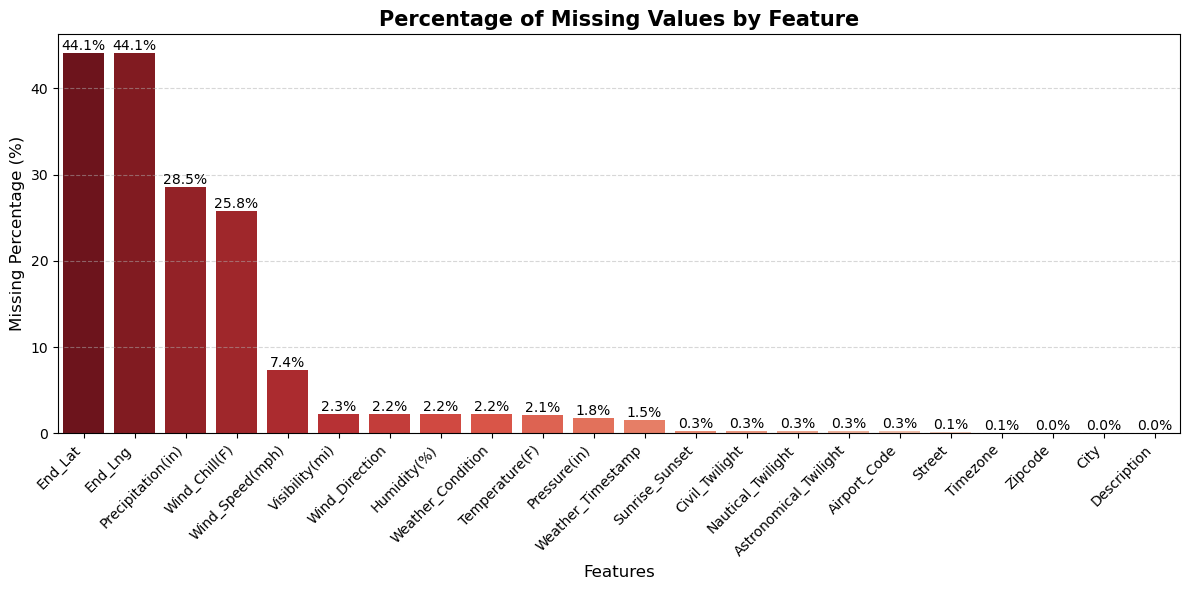

결측치 현황


,Missing Values,Percentage
End_Lat,220377,44.0754
End_Lng,220377,44.0754
Precipitation(in),142616,28.5232
Wind_Chill(F),129017,25.8034
Wind_Speed(mph),36987,7.3974
Visibility(mi),11291,2.2582
Wind_Direction,11197,2.2394
Humidity(%),11130,2.2260
Weather_Condition,11101,2.2202
Temperature(F),10466,2.0932


In [16]:
# =========================================================
# 3.2. 데이터 결측치, 이상치 확인
# =========================================================

# ---------------------------------------------------------
# 1. 결측치 비율 계산 (Calculate Missing Values)
# ---------------------------------------------------------
# 변수별 결측치 개수 및 비율 계산
missing_values = data.isnull().sum()
missing_percentage = (missing_values / len(data)) * 100

# 데이터프레임으로 변환
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})

# 결측치가 0보다 큰 변수만 필터링하고, 비율 기준 내림차순 정렬
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage', ascending=False)

# ---------------------------------------------------------
# 2. 결측치 시각화 (Visualize Missing Values)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

# 막대 그래프 생성
ax = sns.barplot(
    x=missing_df.index,
    y=missing_df['Percentage'],
    hue=missing_df.index,
    palette='Reds_r',
    legend=False
)

# 그래프 스타일 설정
plt.title('Percentage of Missing Values by Feature', fontsize=15, fontweight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Missing Percentage (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 막대 위에 수치(%) 표시
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. 상세 수치 출력 (Display Statistics)
# ---------------------------------------------------------
print("결측치 현황")
display(missing_df)

전체 46개 feature에 대한 결측치 분석 결과에서 다음과 같은 분석을 할 수 있다.

1. 결측치 분석 결과

- End_Lat, End_Lng이 약 44.1%의 가장 높은 결측률을 보이고 있다. 이는 데이터의 절반 가까이가 없는 상태로, 단순 대체를 적용하기에는 리스크가 크다.

- Precipitation,Wind_Chill이 각각 약 28.5%, 25.8%로 역시 높은 결측률을 보이고 있다. 하지만, 이 feature들은 기상 관련 변수로, 특정 상황(비가 안옴, 바람이 약함 등)에서 기록이 누락되는 현상이 나타난 것으로 추정된다.

- Wind_Speed는 7.4%의 결측률을 보이고 있으며, 이 feature 역시 기상 관련 변수로 바람이 약한 기상 상황에서 기록이 안된 현상이 나타난 것으로 추정할 수 있다.

2. 처리 전략

- End_Lat, End_Lng은 높은 결측률로 인해 사용이 어렵다. 또한, Start_Lat, Start_Lng과 함께 Distance는 결측이 없으므로, 이 feature들로 충분히 설명 가능하므로 제거하여 모델의 복잡도를 낮춘다.

- Wind_Chill은 25.8%의 결측률을 가지고 있으며 이는 체감온도로 기온과 풍속으로부터 파생되는 정보이므로, 제거를 고려할 수 있다.

- Precipitation에서 강수량 데이터의 결측은 '강수 없음'을 별도로 기록하지 않아 발생한 결측일 가능성이 높다. 따라서 결측치를 0으로 채우는 것이 합리적이다.

- 나머지 기상 변수는 결측률이 낮고 연속성을 가지므로, 중앙값으로 결측치를 대체한다.

In [17]:
# ---------------------------------------------------------
# 4. 결측치 심층 진단: Start_Time 복구 가능성 분석
# ---------------------------------------------------------
print("\n=== [심층 진단] Start_Time 복구 가능성 확인 ===")

# 조건 정의: Start_Time은 누락되었으나, 대체 가능한 Weather_Timestamp는 존재하는 경우
no_start = data['Start_Time'].isnull()
has_weather_time = data['Weather_Timestamp'].notnull()

# 복구 가능한 행의 개수 계산 (Intersection)
rescuable_count = data[no_start & has_weather_time].shape[0]

# Start_Time의 전체 결측치 개수 가져오기 (이전 단계의 missing_values 활용)
total_missing_start = missing_values['Start_Time']

# 결과 출력
print(f" - Start_Time 총 결측 건수: {total_missing_start:,} 건")
print(f" - Weather_Timestamp로 복구 가능한 건수: {rescuable_count:,} 건")
print(f" - 복구 가능 비율: {(rescuable_count / total_missing_start) * 100:.1f}%")


=== [심층 진단] Start_Time 복구 가능성 확인 ===
 - Start_Time 총 결측 건수: 0 건
 - Weather_Timestamp로 복구 가능한 건수: 0 건
 - 복구 가능 비율: nan%


C:\Users\skwns\AppData\Local\Temp\ipykernel_17032\1329639434.py:19: RuntimeWarning: invalid value encountered in scalar divide
  print(f" - 복구 가능 비율: {(rescuable_count / total_missing_start) * 100:.1f}%")


Start_Time의 결측치는 단순 평균으로 채울 경우 시간 패턴(Rush Hour 등)에 왜곡을 주므로, Weather_Timestamp 값을 사용하여 결측치를 역으로 추론·보간한다. 현재 Sample Data에는 결측치가 존재하지 않음으로, 그대로 사용 가능하다.

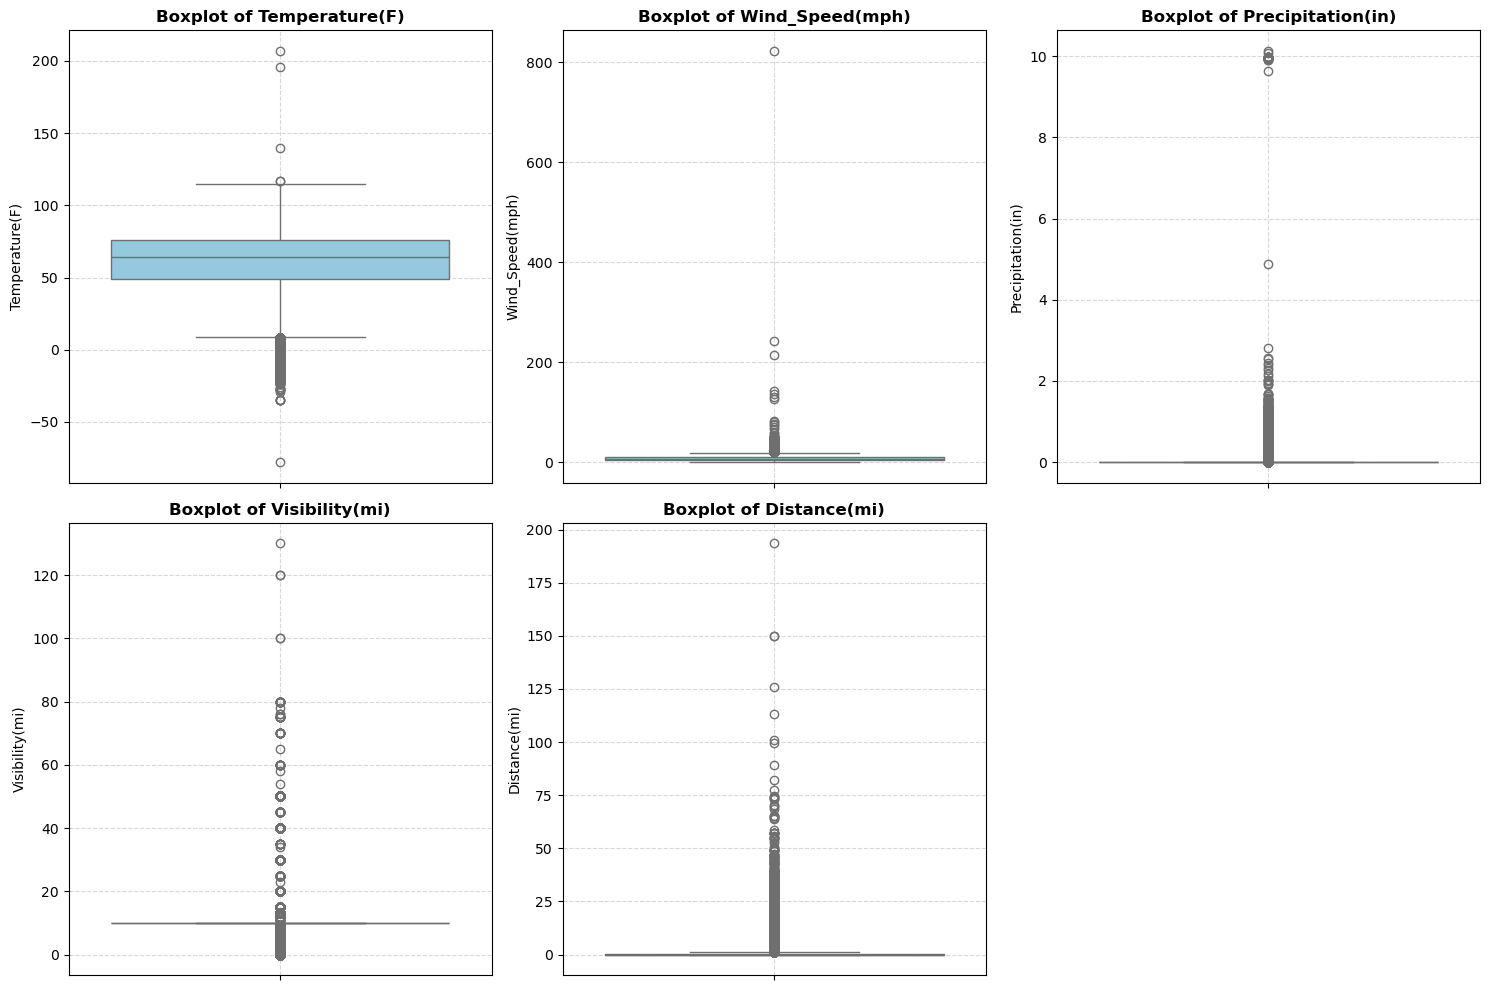

=== Top 10 Highest Values (Max Check) ===
[Temperature(F)] : [207.  196.  140.  117.  116.6 115.  115.  115.  115.  115. ]
[Wind_Speed(mph)] : [822.8 243.  214.  142.  135.8 131.  127.   82.   81.   77. ]
[Precipitation(in)] : [10.13 10.09  9.99  9.99  9.99  9.99  9.99  9.99  9.99  9.99]
[Visibility(mi)] : [130. 120. 120. 100. 100.  80.  80.  80.  80.  80.]
[Distance(mi)] : [193.47999573 149.69       149.687      125.682      112.968
 100.896       99.762       89.01000214  82.254       77.555     ]

=== Top 10 Lowest Values (Min Check for Temp) ===
[Temperature(F)] : [-77.8 -35.  -35.  -35.  -35.  -35.  -29.  -28.  -27.9 -27. ]


In [18]:
# ---------------------------------------------------------
# 5. 이상치 탐지 및 시각화 (Outlier Detection)
# ---------------------------------------------------------

# 이상치 확인이 필요한 주요 수치형 변수 정의
# Distance(mi): 사고 범위, 나머지: 기상 변수
outlier_cols = ['Temperature(F)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Visibility(mi)', 'Distance(mi)']

# 1. Boxplot 시각화 (Visualize Distribution)
plt.figure(figsize=(15, 10))

for i, col in enumerate(outlier_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=data[col], color='skyblue')

    # 그래프 스타일 설정
    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    plt.ylabel(col)
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 6. 극단값 상세 수치 확인 (Check Extreme Values)
# ---------------------------------------------------------
print("=== Top 10 Highest Values (Max Check) ===")
for col in outlier_cols:
    # 상위 10개 값 출력 (내림차순 정렬)
    top_10 = data[col].sort_values(ascending=False).head(10).values
    print(f"[{col}] : {top_10}")

print("\n=== Top 10 Lowest Values (Min Check for Temp) ===")
# 온도는 영하(Negative) 값 오류 가능성을 확인하기 위해 하위 10개 조회
bottom_10_temp = data['Temperature(F)'].sort_values(ascending=True).head(10).values
print(f"[Temperature(F)] : {bottom_10_temp}")

Boxplot 시각화 및 극단값(Top/Bottom 10) 조회 결과, 변수의 성격에 따라 명백한 오류와 자연적 이상치가 구분되었다.

유형 A: 물리적 오류 데이터 (Impossible Values)

Temperature(F): 최대값이 207.0°F (약 97°C), 196.0°F 등으로 나타났으며, 최저값은 -77.8°F (약 -61°C)가 기록되었다. 이는 지구상에서 일반적인 도로 환경에서 관측되기 불가능한 수치로, 센서 오작동으로 인한 데이터 오염(Corruption)임이 확실하다. (참고: 그 다음 상위값은 140°F, 하위값은 -35°F 수준으로 급격한 차이를 보임)

Wind_Speed(mph): 최대 풍속이 822.8 mph로, 이는 음속(767 mph)을 돌파하는 비현실적인 값이다. 그 외 243 mph, 214 mph 등도 일반적인 태풍 규모를 훨씬 상회하므로 신뢰하기 어렵다.

유형 B: 자연적 극단값 (Natural Outliers)

Precipitation(in): 최대 10.13 inch의 강수량이 기록되었다. 이는 매우 드문 폭우 사례이지만, 기상학적으로 불가능한 수치는 아니므로 사고 심각도(Severity)와 높은 연관성을 가질 수 있는 유의미한 정보이다.

Distance(mi): 사고 영향 범위가 최대 193.5 miles에 달하는 케이스가 확인되었다. 이는 단순 접촉 사고가 아닌 대규모 도로 통제나 폐쇄를 동반한 심각한 사고일 가능성이 높다.



이상치 제거 (Filtering): 물리적 오류로 판명된 데이터는 제거하여 모델 학습을 방해하지 않도록 한다.

Temperature(F): 미국 기상 관측 범위를 고려하여 -40°F ~ 120°F 범위를 벗어나는 데이터를 이상치로 규정하고 제거한다.

Wind_Speed(mph): 허리케인 등급을 고려하더라도 200 mph를 초과하는 값은 측정 오류일 가능성이 매우 높으므로 제거한다.

로그 변환 (Log Transformation):

Precipitation(in)과 Distance(mi)는 제거하지 않고 유지하되, 데이터가 소수 값에 극단적으로 쏠려 있는(Right-skewed) 분포를 보이므로, 추후 전처리 단계에서 Log 변환을 적용하여 데이터 분포를 정규분포에 가깝게 보정한다.

###3.3 주요 변수 그룹별 심층 분석 (Deep Analysis by Feature Groups)
1. 분석 개요 및 전략 앞선 단계에서 데이터의 물리적 품질(결측치, 이상치)을 진단했다면, 본 단계에서는 변수가 사고 심각도(Severity)에 미치는 실제적인 영향력을 규명하는 데 초점을 맞춘다. 46개에 달하는 다수의 설명 변수를 효율적으로 분석하고 도메인 특성을 반영하기 위해, 변수들을 성격에 따라 6가지 핵심 그룹(Target, Temporal, Weather, Infrastructure, Location, Astronomical)으로 범주화하여 심층 분석을 수행한다.

2. 변수 그룹 정의 (Feature Grouping)

Group 0: 타겟 변수 (Target Variable)

대상: Severity

목표: 클래스 불균형(Class Imbalance)의 심각성을 정량적으로 확인하고, 이를 해소하기 위한 샘플링 전략의 필요성을 검토한다.

Group A: 시계열 및 시간 변수 (Temporal Features)

대상: Start_Time (파생 변수: Hour, Weekday, Month)

목표: 인간의 활동 주기(출퇴근, 주말, 계절)에 따른 사고 발생 빈도와 심각도의 패턴 차이를 시각화한다.

Group B: 기상 및 환경 변수 (Weather Features)

대상: Temperature, Visibility, Precipitation, Weather_Condition 등

목표: "악천후 시 사고 위험이 증가한다"는 가설을 검증하고, 특정 기상 조건(예: 안개, 눈)이 치명적인 사고(Severity 3, 4)와 얼마나 강한 연관성을 갖는지 분석한다.

Group C: 도로 시설물 변수 (Infrastructure & POI Features)

대상: Bump, Crossing, Traffic_Signal, Junction 등

목표: 사고 현장에 특정 도로 시설물(신호등, 횡단보도 등)이 존재하는 것이 사고의 심각도를 완화하는지 혹은 가중시키는지 분석한다.

Group D: 위치 및 공간 변수 (Location & Spatial Features)

대상: Start_Lat, Start_Lng, State, Distance(mi)

목표: 사고 발생의 지리적 분포를 지도에 매핑하여 군집(Cluster)을 확인하고, 주(State)별 위험도 차이 및 사고 구간 길이(Distance)가 심각도에 미치는 영향을 분석한다.

Group E: 천문 및 기타 변수 (Astronomical & Other Features)

대상: Sunrise_Sunset, Twilight 관련 변수, Timezone

목표: 주간/야간(Day/Night) 여부에 따른 사고 패턴을 비교하고, 유사 변수 간의 정보 중복성(Redundancy)을 식별하여 제거 대상을 선별한다.

3. 시각화 방법론 각 그룹의 변수 특성(수치형/범주형/공간형)에 맞춰 다음과 같은 시각화 기법을 적용한다.

분포 확인 (Distribution): 히스토그램(Histogram) 등을 통해 데이터의 쏠림(Skewness)과 분포 형태를 파악한다.

심각도 연관성 분석 (Relation with Severity):

수치형 변수: Boxplot을 사용하여 심각도 단계별 값의 분포 차이와 이상치 여부를 비교한다.

범주형 변수: Barplot을 통해 각 범주 내에서 '심각한 사고(Severity 3 이상)'의 비율을 시각화하여 위험 요인을 식별한다.

공간 데이터 시각화 (Geospatial Visualization): 위도와 경도 좌표를 활용해 Scatter Plot으로 사고 발생 지점을 지도상에 시각화하고, 지역적 밀집도와 심각도 패턴을 직관적으로 파악한다.

In [19]:
# =========================================================
# 3.3. 주요 변수 그룹별 심층 분석
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. 심층 분석 및 시각화 함수 정의 (Define Analysis Function)
# ---------------------------------------------------------
def analyze_feature_group(df, feature_list, group_name):
    """
    [함수 설명]
    특정 변수 그룹의 분포와 사고 심각도(Severity) 간의 관계를 시각화합니다.
    """
    print(f"\n{'='*30} [Group Analysis] {group_name} {'='*30}")

    # Severity_Class 생성 (필요 시)
    if 'Severity_Class' not in df.columns:
        df['Severity_Class'] = df['Severity'].apply(lambda x: 'Severe (3-4)' if x >= 3 else 'Minor (1-2)')

    # 색상 매핑 규칙 (문자열 기준)
    color_map = {'False': 'skyblue', 'True': 'firebrick'}

    for col in feature_list:
        if col not in df.columns: continue
        if df[col].nunique() <= 1: continue

        print(f"\n>>> Analyzing Feature: {col}")

        # Boolean 값을 'False', 'True' 문자열로 변환하여 처리가 쉽도록 함
        plot_df = df[[col, 'Severity']].copy()
        plot_df[col] = plot_df[col].astype(str)

        # 정렬 순서 고정 (False -> True)
        # 데이터에 존재하는 값만 추려서 정렬
        existing_values = plot_df[col].unique()
        order_list = sorted(existing_values) # 알파벳순: 'False'가 'True'보다 먼저 옴

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        plt.subplots_adjust(wspace=0.3)

        # ---------------------------
        # A. 수치형 변수 (Numerical)
        # ---------------------------
        if pd.api.types.is_numeric_dtype(df[col]) and df[col].nunique() > 10:
            # (1) 분포 확인 (Histogram & KDE)
            sns.histplot(data=df, x=col, bins=50, kde=True, ax=axes[0], color='skyblue', edgecolor='white')
            axes[0].set_title(f'Distribution of {col}', fontweight='bold')

            # (2) 심각도별 차이 확인 (Boxplot)
            sns.boxplot(data=df, x='Severity', y=col, ax=axes[1], hue='Severity',
                        palette=['skyblue', 'skyblue', 'firebrick', 'firebrick'], legend=False)
            axes[1].set_title(f'{col} vs Severity (Boxplot)', fontweight='bold')

        # ---------------------------
        # B. 범주형 / Boolean 변수 (POI 등)
        # ---------------------------
        else:
            # (1) 빈도수 (Count)
            sns.countplot(data=plot_df, x=col, ax=axes[0], order=order_list, hue=col, palette='viridis', legend=False)
            axes[0].set_title(f'Count of {col}', fontweight='bold')
            axes[0].tick_params(axis='x', rotation=45)

            # (2) 심각도 비율 (Barplot)
            # 비율 계산
            props = plot_df.groupby(col)['Severity'].apply(lambda x: (x >= 3).mean() * 100).reindex(order_list)

            if set(order_list).issubset({'False', 'True'}):
                palette_to_use = [color_map[val] for val in order_list]
            else:
                palette_to_use = 'Reds'

            sns.barplot(x=props.index, y=props.values, ax=axes[1], order=order_list, hue=props.index, palette=palette_to_use, legend=False)

            axes[1].set_title(f'Severe Accident Rate (%) by {col}', fontweight='bold')
            axes[1].set_ylabel('Severe Ratio (%)')

            y_max = props.max() if len(props) > 0 else 0
            axes[1].set_ylim(0, y_max * 1.3 if y_max > 0 else 30)
            axes[1].tick_params(axis='x', rotation=45)

            # 수치 텍스트 표시
            for i, v in enumerate(props.values):
                # NaN 값 방지
                if pd.isna(v): continue
                axes[1].text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=11, fontweight='bold', color='black')

        plt.show()
        print("-" * 100)

=== Target Variable Analysis ===


C:\Users\skwns\AppData\Local\Temp\ipykernel_17032\3125770603.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Severity', data=data, palette='OrRd')


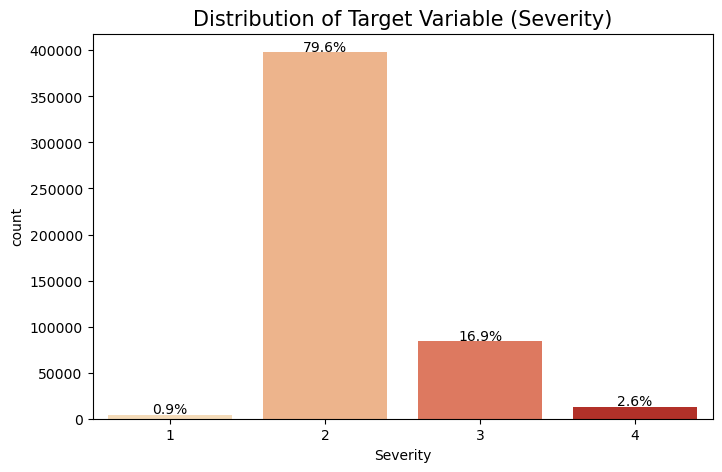

In [20]:
# ---------------------------------------------------------
# 2. 타겟 변수 분석 (Target Variable Analysis)
# ---------------------------------------------------------
print("=== Target Variable Analysis ===")

plt.figure(figsize=(8, 5))

# 1. 분포 시각화 (Countplot)
ax = sns.countplot(x='Severity', data=data, palette='OrRd')
plt.title('Distribution of Target Variable (Severity)', fontsize=15)

# 2. 비율(Percentage) 표시
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height + 1000,
            f'{height/len(data)*100:.1f}%', ha="center")

plt.show()

Group 0: 타겟 변수 (Target Variable) 분석
[분석 결과 Report]

타겟 변수인 사고 심각도(Severity)의 분포를 시각화한 결과, 데이터 내 클래스 간 불균형(Class Imbalance) 문제가 매우 심각한 것으로 확인되었다.

지배적인 다수 클래스: Severity 2(경미한 사고)가 전체 데이터의 79.6%를 차지하며 압도적인 비중을 보인다. 이는 대부분의 교통사고가 인명 피해가 적은 접촉 사고임을 의미한다.

소수 클래스 (관심 대상): 본 프로젝트의 핵심 예측 대상인 '심각한 사고'(Severity 3와 4)는 각각 16.9%와 2.6%에 불과하다. 특히, 가장 치명적인 Severity 4는 데이터의 극히 일부(2.6%)만을 구성하고 있다.

시사점 및 대응 전략:

이러한 극심한 불균형 상태에서 모델을 학습시킬 경우, 모델은 모든 사고를 빈도수가 높은 Severity 2로 예측하려는 편향(Bias)을 갖게 된다.

따라서 앞서 언급했듯이 단순 정확도(Accuracy)는 모델의 성능 지표로 부적합하며, 소수 클래스에 대한 예측력을 대변하는 Macro F1-Score를 주 지표로 사용해야 한다.

Analyzing Group A: Temporal Features...


C:\Users\skwns\AppData\Local\Temp\ipykernel_17032\482254372.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='viridis')
C:\Users\skwns\AppData\Local\Temp\ipykernel_17032\482254372.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='viridis')
C:\Users\skwns\AppData\Local\Temp\ipykernel_17032\482254372.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='viridis')


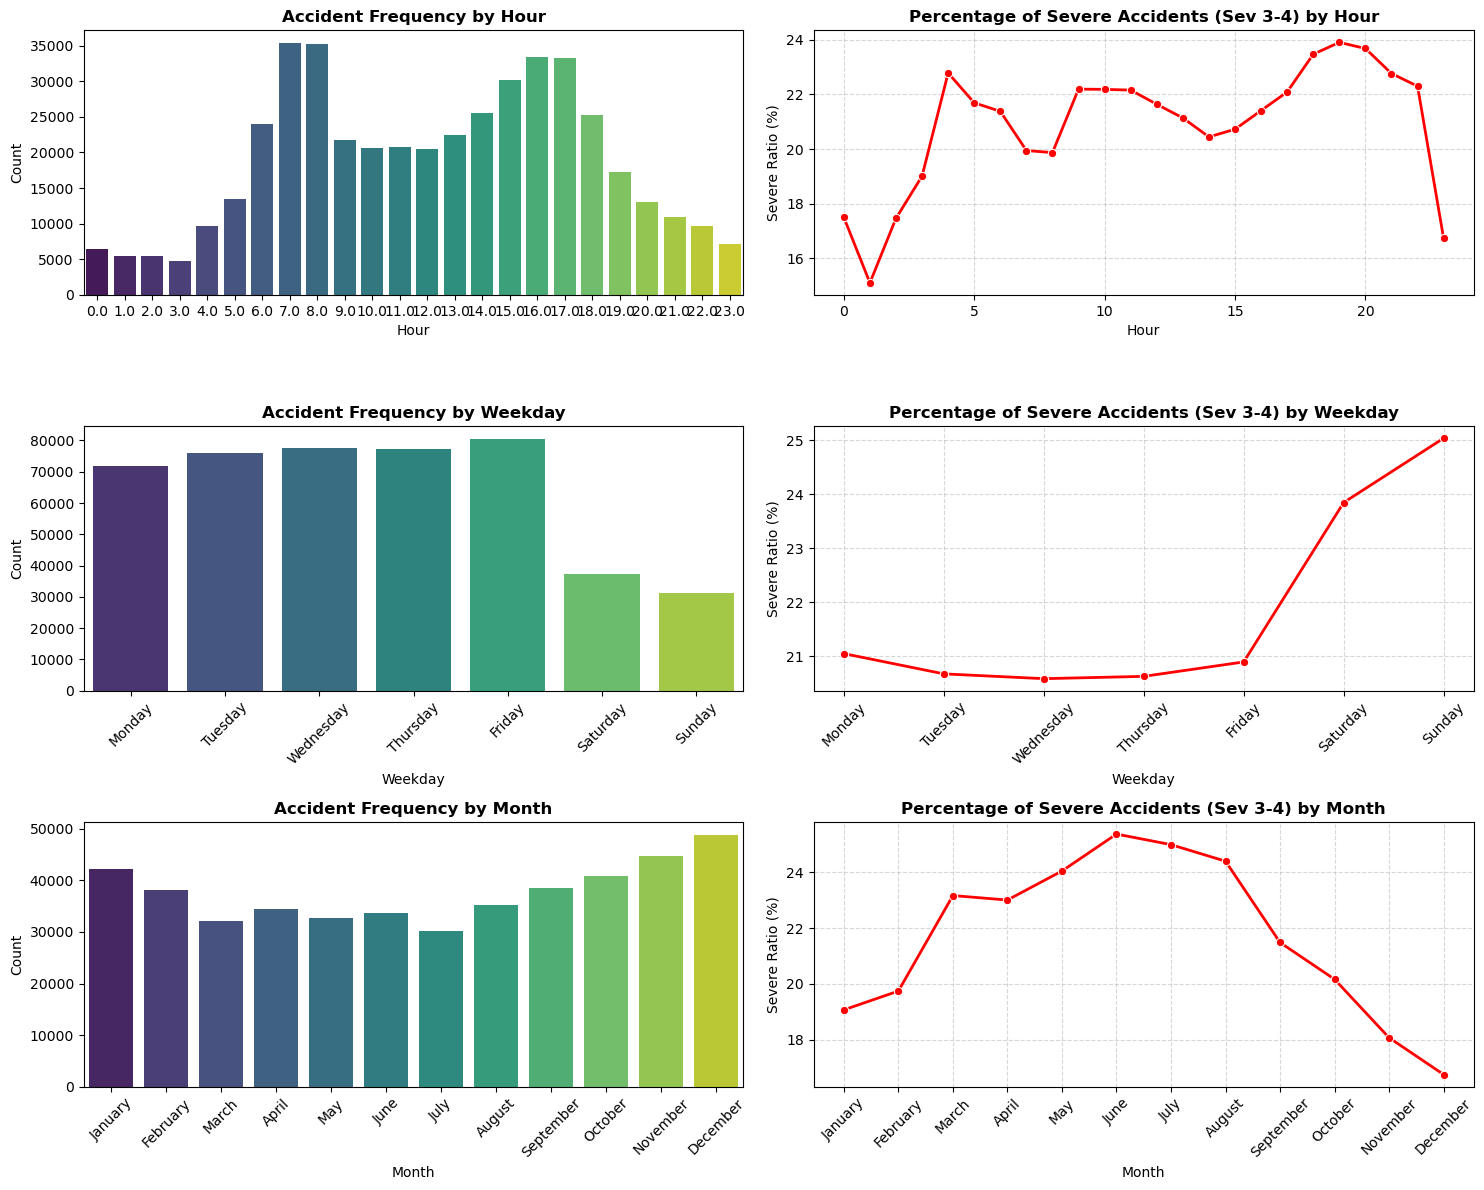

In [21]:
# ---------------------------------------------------------
# 3. Group A: 시계열 및 시간 변수 분석 (Temporal Features)
# ---------------------------------------------------------

# 1. 시계열 파생 변수 생성 (Feature Engineering)
# Start_Time을 datetime 객체로 변환 후, 시간/요일/월 추출
data['Start_Time'] = pd.to_datetime(data['Start_Time'], errors='coerce')

data['Hour'] = data['Start_Time'].dt.hour
data['Weekday'] = data['Start_Time'].dt.day_name()
data['Month'] = data['Start_Time'].dt.month_name()

# 2. 분석을 위한 정렬 순서 정의 (Define Sort Order)
order_day = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
order_month = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

# ---------------------------------------------------------
# 3. 시각화 함수 정의 (Group A 전용)
# ---------------------------------------------------------
def analyze_temporal_group(df):
    """
    [함수 설명]
    시간, 요일, 월별 사고 빈도(Frequency)와 심각도 비율(Severity Rate)을 시각화합니다.
    순서(Order)가 중요한 시계열 데이터 특성을 반영하여 정렬 기능을 포함합니다.
    """
    temporal_features = [('Hour', None), ('Weekday', order_day), ('Month', order_month)]

    # 심각한 사고(Severity 3,4) 여부 마킹 (0 or 1)
    df['Is_Severe'] = df['Severity'].apply(lambda x: 1 if x >= 3 else 0)

    plt.figure(figsize=(15, 12))

    for i, (col, order) in enumerate(temporal_features):
        # (1) 사고 발생 건수 (Frequency - Bar Plot)
        plt.subplot(3, 2, 2*i + 1)
        sns.countplot(data=df, x=col, order=order, palette='viridis')
        plt.title(f'Accident Frequency by {col}', fontsize=12, fontweight='bold')
        plt.ylabel('Count')
        if col != 'Hour': plt.xticks(rotation=45)

        # (2) 심각한 사고 발생 비율 (Severity Rate - Line Plot)
        plt.subplot(3, 2, 2*i + 2)

        # 그룹별 심각한 사고의 평균(비율) 계산
        severity_rate = df.groupby(col)['Is_Severe'].mean() * 100

        # 정렬 적용
        if order:
            severity_rate = severity_rate.reindex(order)

        sns.lineplot(x=severity_rate.index, y=severity_rate.values, marker='o', color='red', linewidth=2)
        plt.title(f'Percentage of Severe Accidents (Sev 3-4) by {col}', fontsize=12, fontweight='bold')
        plt.ylabel('Severe Ratio (%)')
        plt.grid(True, linestyle='--', alpha=0.5)
        if col != 'Hour': plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 4. 분석 실행 (Execute Analysis)
# ---------------------------------------------------------
print("Analyzing Group A: Temporal Features...")
analyze_temporal_group(data)

Group A: 시계열 및 시간 변수 (Temporal Features) 분석
1. 변수 추출 및 가공 (Feature Engineering) 원본 데이터의 Start_Time은 "2023-01-01 12:00:00" 형태의 문자열(String)로, 모델이 직접 학습하기에 부적합하다. 따라서 이를 datetime 객체로 변환한 후, 사고 패턴에 영향을 미치는 인간의 주기적 활동을 반영하기 위해 다음 3가지 파생 변수로 분해하였다.

Hour (시간): 하루 중 활동 주기(출퇴근, 심야 등)를 파악하기 위함.

Weekday (요일): 평일(업무)과 주말(여가)의 통행 패턴 차이를 분석하기 위함.

Month (월): 계절적 요인(휴가철, 결빙기 등)을 확인하기 위함.

2. 분석 결과 (Analysis Report)

(1) 시간대별 분석 (Hour of Day)

빈도(Frequency): 오전 7\~8시와 오후 16\~17시에 사고 발생량이 급증하는 전형적인 출퇴근 시간(Rush Hour) 패턴이 확인된다.

사고 심각도(Severity): 반면, 심각한 사고(Severity 3, 4)의 비율은 교통량이 줄어드는 새벽 3\~4시와 밤 19\~22시 구간에 최고조(약 22~24%)에 달한다.

해석: 낮 시간대에는 정체로 인한 경미한 접촉 사고가 주를 이루는 반면, 야간에는 차량 소통이 원활하여 과속(Speeding)이 발생하기 쉽고, 시야 확보가 어려워 치명적인 사고로 이어질 확률이 높다.

(2) 요일별 분석 (Day of Week)

빈도: 통근 차량이 많은 평일(월~금)의 사고 건수가 주말보다 높다.

사고 심각도(Severity): 반대로 심각도 비율은 일요일(Sunday)에 약 25%로 가장 높게 나타났다. 이는 주말 여가 통행의 특성(고속도로 이용, 장거리 운전 등)이 반영된 결과로 추정된다.

(3) 월별 분석 (Month of Year)

빈도: 연말로 갈수록(11월, 12월) 사고 빈도가 증가하는 경향을 보인다.

사고 심각도(Severity): 흥미롭게도 심각한 사고의 비율은 6월(June) 등 여름철에 가장 높고, 오히려 사고가 많은 12월에는 가장 낮게 나타났다. 이는 겨울철에는 눈길 등으로 인해 운전자가 서행(Defensive Driving)하는 반면, 여름철에는 고속 주행이 잦기 때문으로 해석된다.

3. 전처리 전략 도출

단순히 시간(Hour)을 수치로 넣기보다, 심각도가 높은 Is_Night (야간 여부)나 빈도가 높은 Is_Rush_Hour (출퇴근 여부)와 같은 파생 변수를 생성하여 모델에 명확한 힌트를 제공하는 것이 효과적일 것이다.

4. 불필요 변수 제거 및 데이터 누수 방지 (Redundancy & Data Leakage)

Weather_Timestamp: 사고 발생 시각(Start_Time)과 가장 가까운 기상 데이터를 매핑할 때 생성된 메타데이터에 불과하다. Start_Time과 정보가 중복되므로 모델의 복잡도를 낮추기 위해 제거한다.

End_Time: 사고 종료 시각은 사고가 발생하기 전에, 그리고 발생한 시점에는 알 수 없는 사후 정보(Post-event Information)이다. 이를 모델에 포함할 경우, '사고 처리 시간(Duration)'을 미리 알고 정답을 맞히는 데이터 누수(Data Leakage) 문제가 발생할 수 있으므로 우리의 목적과 맞지 않다. 이 feature는 예측 모델링에서 배제하도록 한다.

Analyzing Group B: Weather Features...

============================== [Group Analysis] Group B: Weather Features ==============================

>>> Analyzing Feature: Temperature(F)


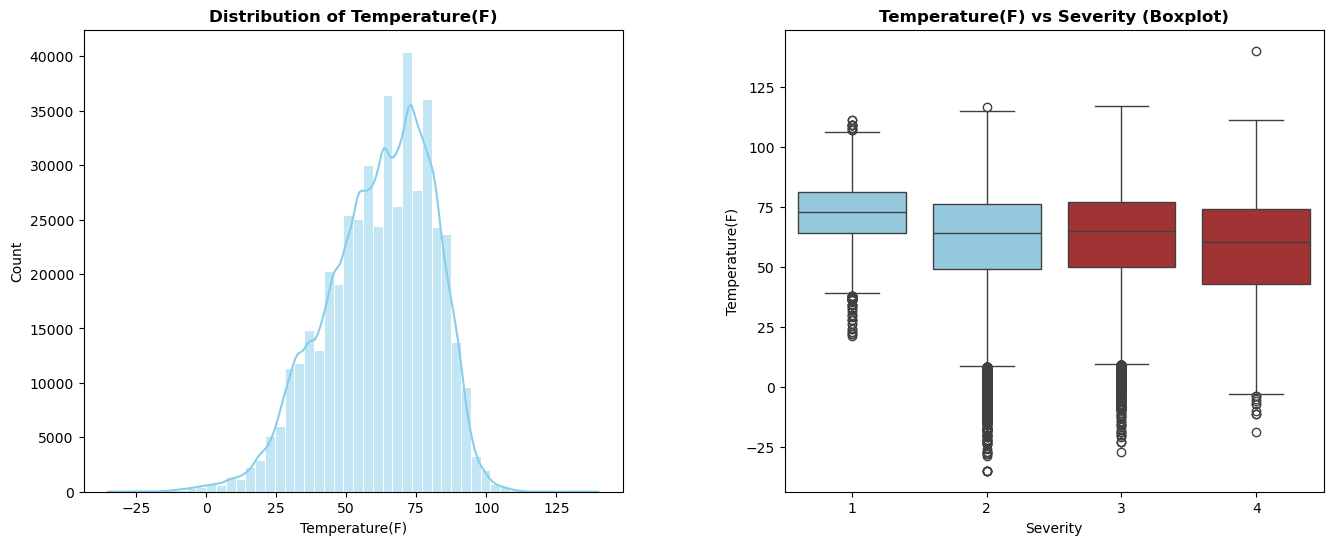

----------------------------------------------------------------------------------------------------

>>> Analyzing Feature: Humidity(%)


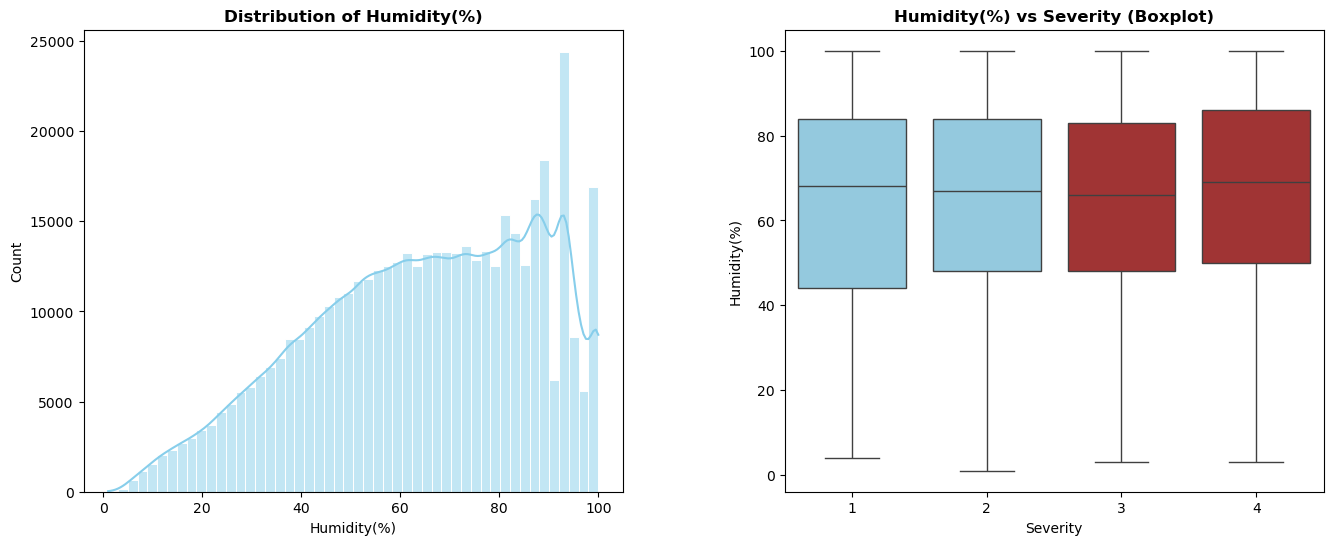

----------------------------------------------------------------------------------------------------

>>> Analyzing Feature: Visibility(mi)


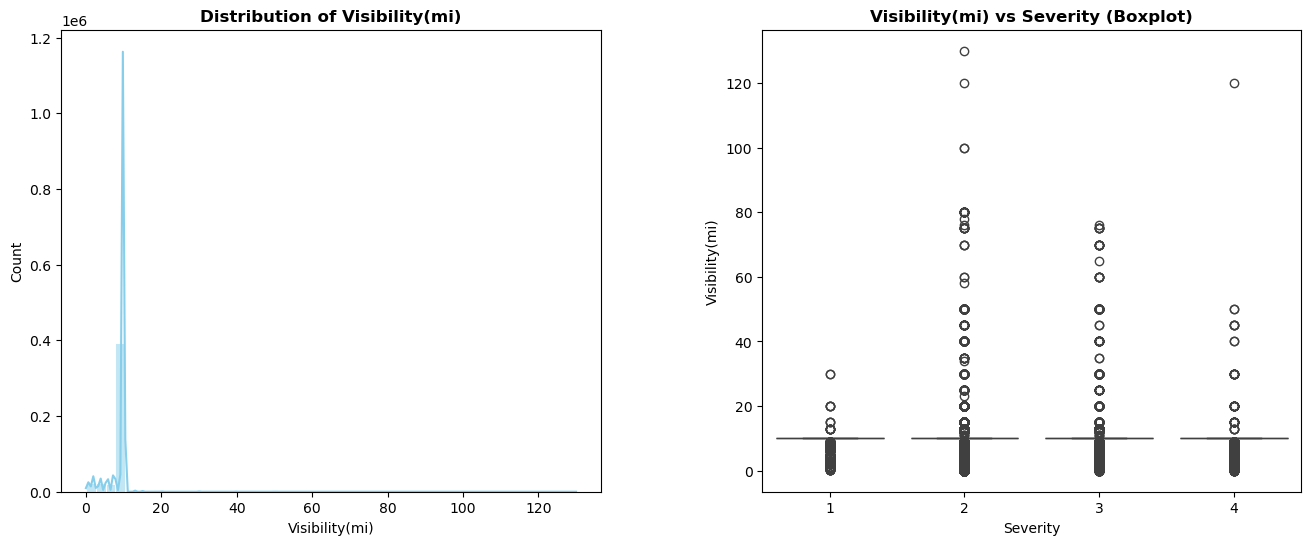

----------------------------------------------------------------------------------------------------

>>> Analyzing Feature: Pressure(in)


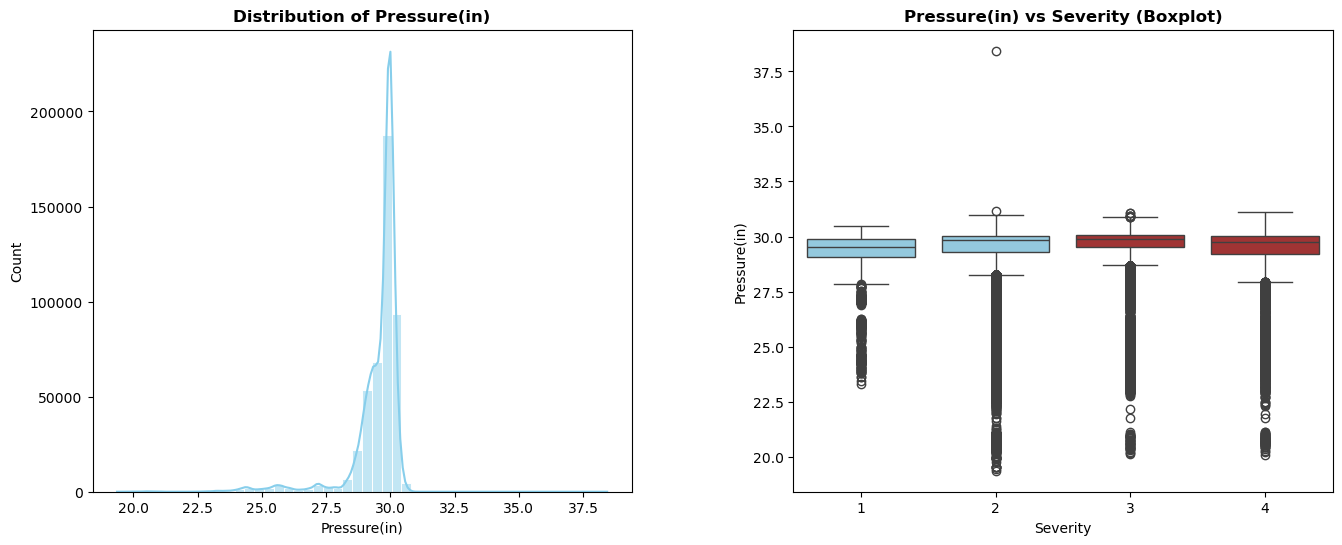

----------------------------------------------------------------------------------------------------

>>> Analyzing Feature: Wind_Speed(mph)


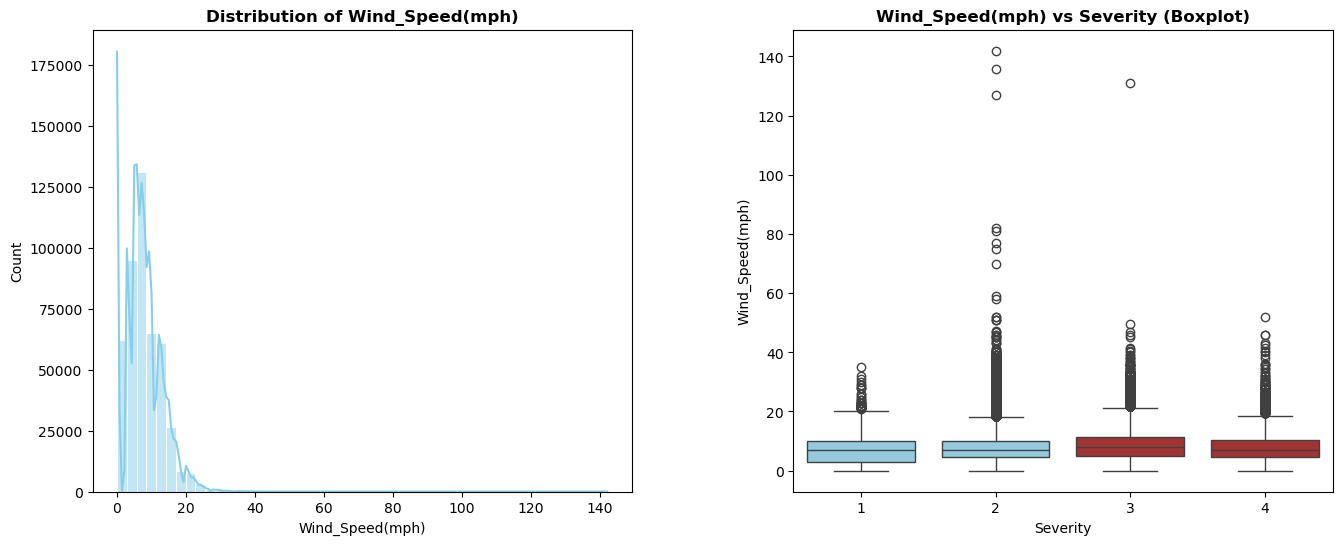

----------------------------------------------------------------------------------------------------

>>> Analyzing Feature: Precipitation(in)


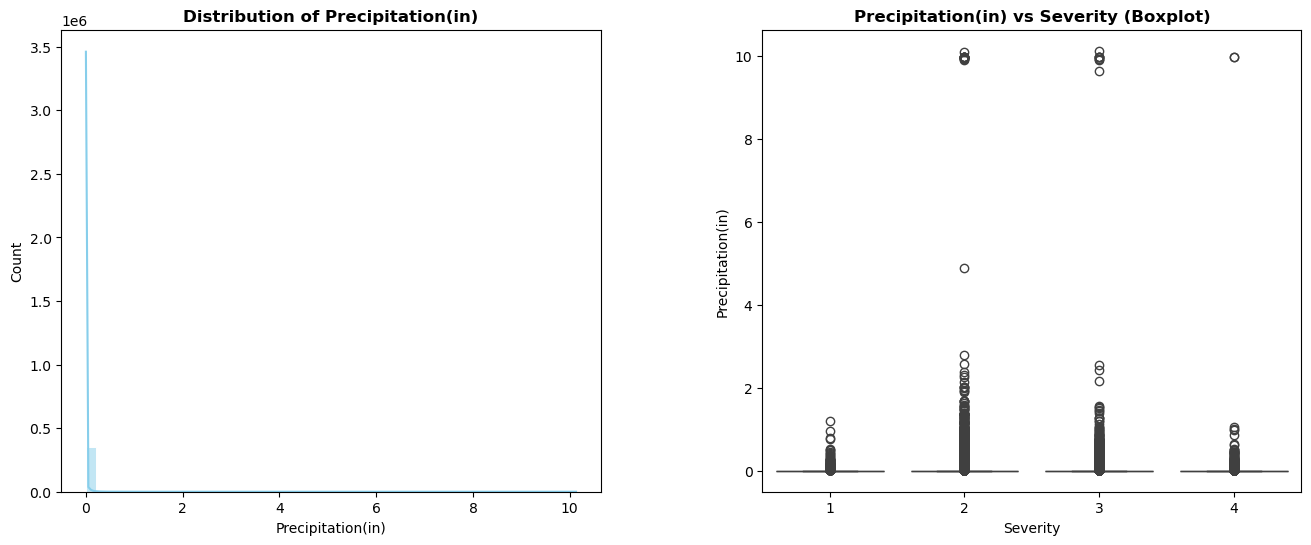

----------------------------------------------------------------------------------------------------

>>> Analyzing Feature: Weather_Condition


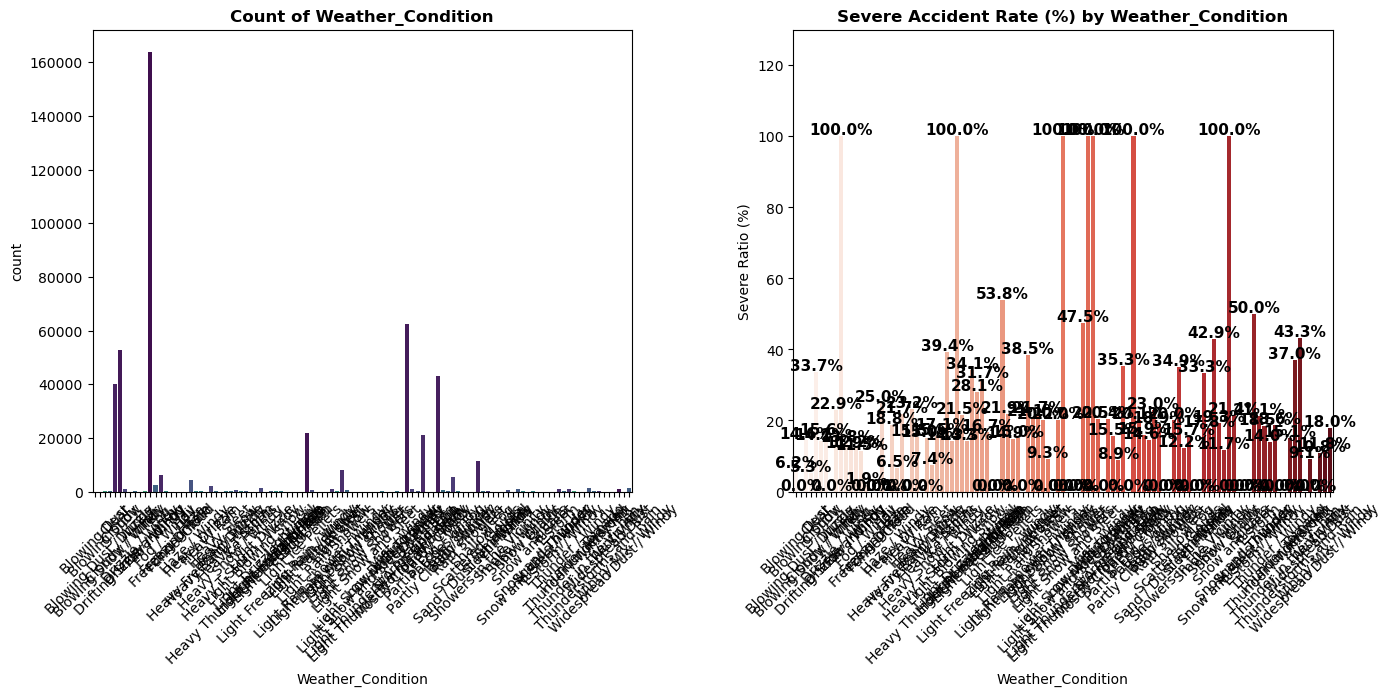

----------------------------------------------------------------------------------------------------

>>> Analyzing Feature: Wind_Direction


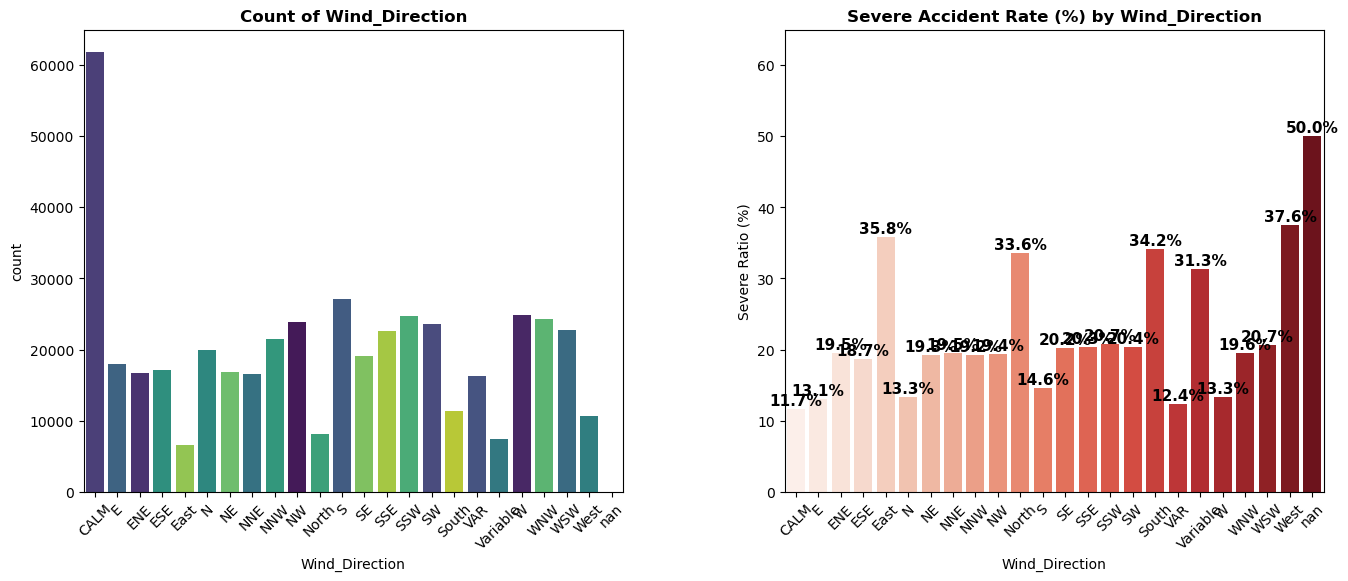

----------------------------------------------------------------------------------------------------


In [22]:
# ---------------------------------------------------------
# 4. Group B: 기상 및 환경 변수 분석 (Weather & Environment)
# ---------------------------------------------------------

# 1. 분석할 변수 리스트 정의 (Define Variable List)
# 수치형(기온, 습도, 가시거리, 풍속 등) + 범주형(날씨상태, 풍향)
weather_cols = [
    'Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Pressure(in)',
    'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Wind_Direction'
]

print("Analyzing Group B: Weather Features...")

# ---------------------------------------------------------
# 2. 시각화용 데이터 필터링 (Filter Data for Visualization)
# ---------------------------------------------------------
# 극단적인 이상치(예: 온도 200도, 풍속 800mph 등)가 존재하면 그래프가 왜곡되므로,
# 시각화 용도로만 정상 범위 데이터를 필터링하여 임시 복사본을 생성합니다.
viz_data = data[
    (data['Temperature(F)'] > -50) & (data['Temperature(F)'] < 150) &
    (data['Wind_Speed(mph)'] < 200)
].copy()

# ---------------------------------------------------------
# 3. 분석 함수 실행 (Execute Analysis)
# ---------------------------------------------------------
analyze_feature_group(viz_data, weather_cols, "Group B: Weather Features")

Group B: 기상 및 환경 변수 (Weather Features) 분석
1. 수치형 변수 분석 (Atmospheric & Physical Factors)

분포의 비정규성 (Non-normality): 대부분의 기상 변수는 정규분포를 따르지 않고 강한 편향(Skewness)을 보인다.

Zero-inflated: Precipitation(in)은 0에 절대다수가 집중되어 있어, 강수량 자체보다 '강수 유무'가 중요한 정보임을 시사한다.

Left-skewed: Visibility(mi)는 관측 상한인 10마일에 데이터가 쏠려 있으며, 낮은 시정 구간은 상대적으로 희소하다.

Right-skewed: Wind_Speed(mph)는 낮은 풍속에 밀집되어 있고 우측으로 긴 꼬리를 가진다. Pressure와 Humidity 역시 특정 구간에 밀집된 비대칭 분포를 보인다.

심각도(Severity)와의 관계:

유의미한 변수: Wind_Speed는 심각한 사고(Severity 3~4)에서 중앙값이 상승하는 경향을 보여, 강풍이 사고 피해를 키우는 요인임이 확인되었다. Visibility 역시 수치적 차이는 작으나, 시정 저하 시 심각한 사고 빈도가 관찰되었다.

제한적 변수: Temperature, Humidity, Pressure는 단독 변수로는 심각도 간 뚜렷한 차이를 보이지 않았으나, 결빙 등 복합적 기상 조건을 설명하는 보조 변수로서의 잠재력은 존재한다.

2. 범주형 변수 분석 (Weather Condition)

범주 파편화 (High Cardinality): Fair, Clear와 같이 의미가 동일한 라벨이 혼재하고, Cloudy, Overcast 등 흐림을 나타내는 표현이 과도하게 세분화되어 있어 범주 통합이 필수적이다.

기상 상태별 위험도:

Fair/Clear (맑음): 사고 빈도는 높으나, 심각한 사고 비율은 약 12%로 가장 낮았다 (시야 및 노면 상태 양호).

Overcast/Scattered Clouds (흐림/불안정): 심각한 사고 비율이 30% 이상으로 급증하여, 기상 악화가 사고의 치명도를 높이는 주요인임을 통계적으로 입증하였다.

3. 변수 선택 및 전처리 전략 (Action Plan)

EDA 결과를 바탕으로 정보 손실을 최소화하고 모델 안정성을 높이는 4단계 전략을 수립한다.

범주 재정의 (Grouping): Weather_Condition의 유사 범주를 통합하여 6대 핵심 그룹(Clear, Cloudy, Rain, Snow, Fog, Other)으로 재편한다.

변수 제거 (Feature Drop): Wind_Direction은 Wind_Speed와 정보가 중복되며(CALM 여부), 풍향 자체의 영향력은 미미하므로 과적합 방지를 위해 제거한다.

변수 변환 (Transformation): 편향이 심한 Precipitation과 Wind_Speed는 Log 변환을 적용하여 정규성을 확보하고, Precipitation은 강수 여부(Binary) 변수를 추가로 고려한다.

결측치 보간 (Imputation): Visibility, Humidity, Pressure 등 비대칭 분포를 가진 변수의 결측치는 평균(Mean) 대신 중앙값(Median)으로 대체하여 이상치 민감도를 낮춘다.

Analyzing Group C: Infrastructure (POI) Features...

============================== [Group Analysis] Group C: Infrastructure Features ==============================

>>> Analyzing Feature: Amenity


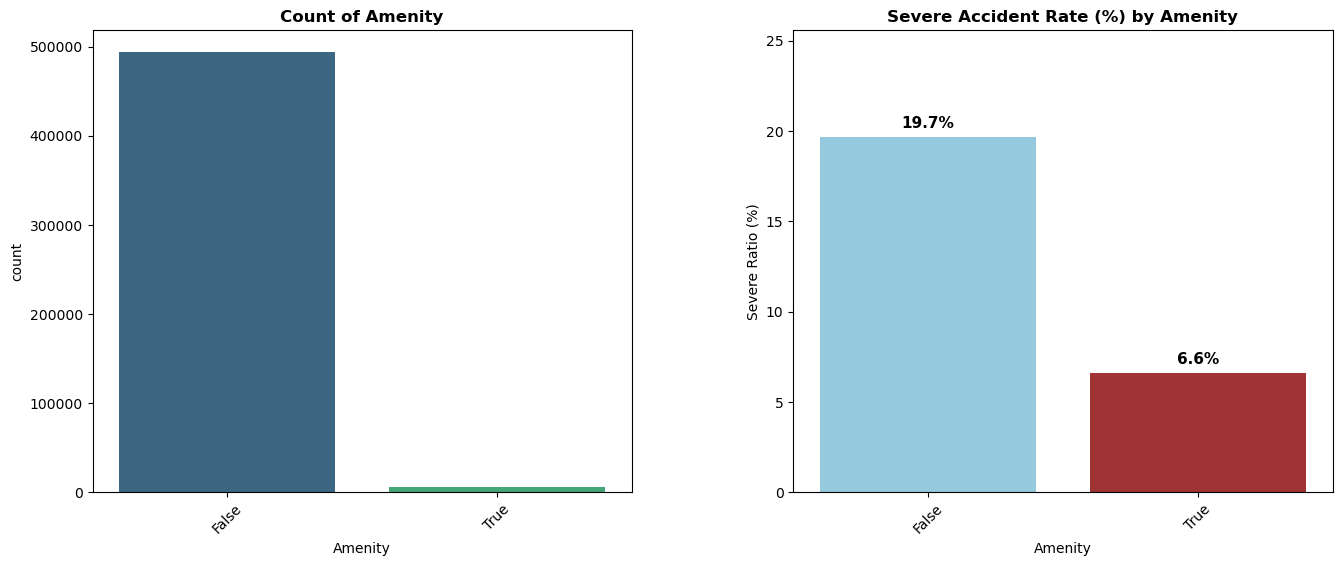

----------------------------------------------------------------------------------------------------

>>> Analyzing Feature: Bump


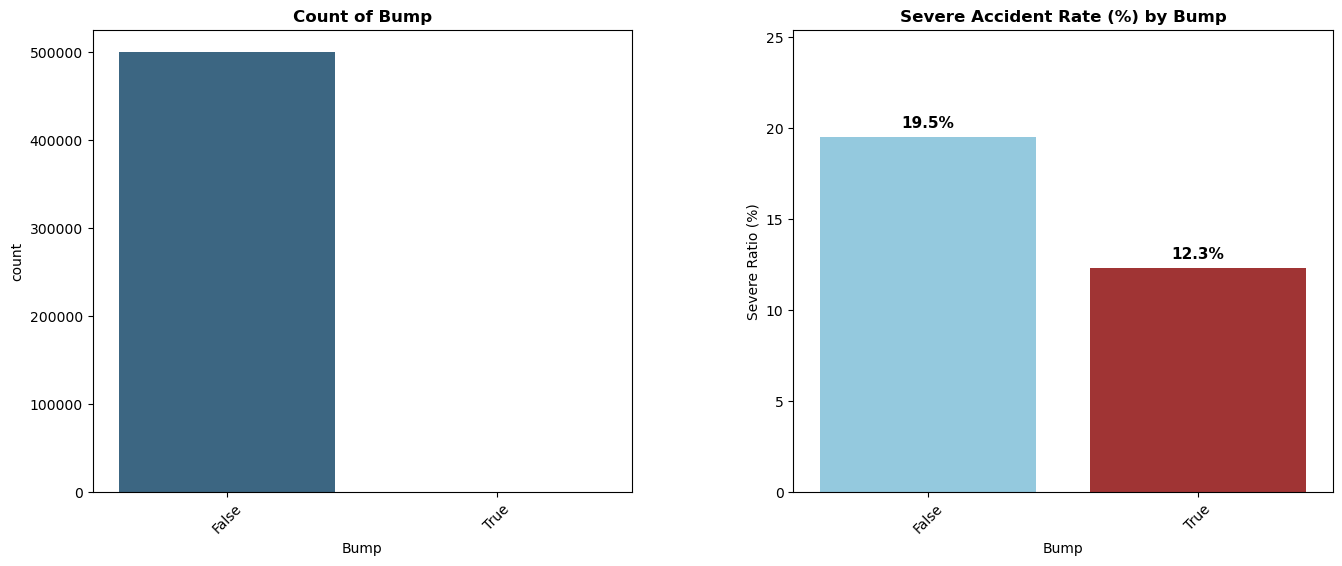

----------------------------------------------------------------------------------------------------

>>> Analyzing Feature: Crossing


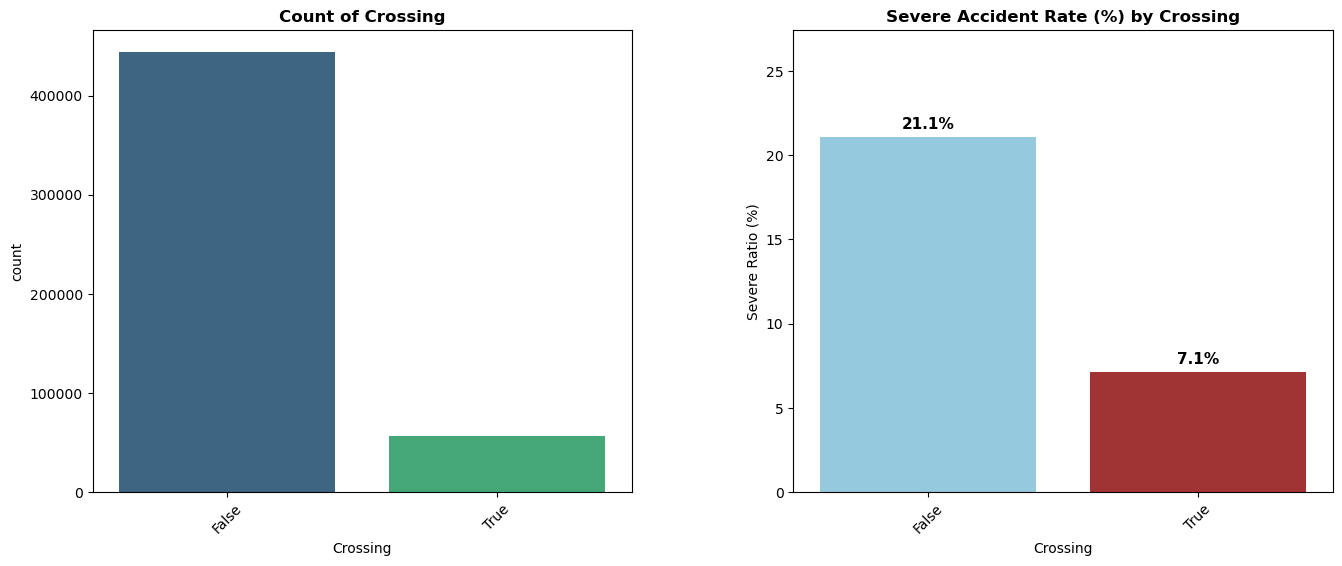

----------------------------------------------------------------------------------------------------

>>> Analyzing Feature: Give_Way


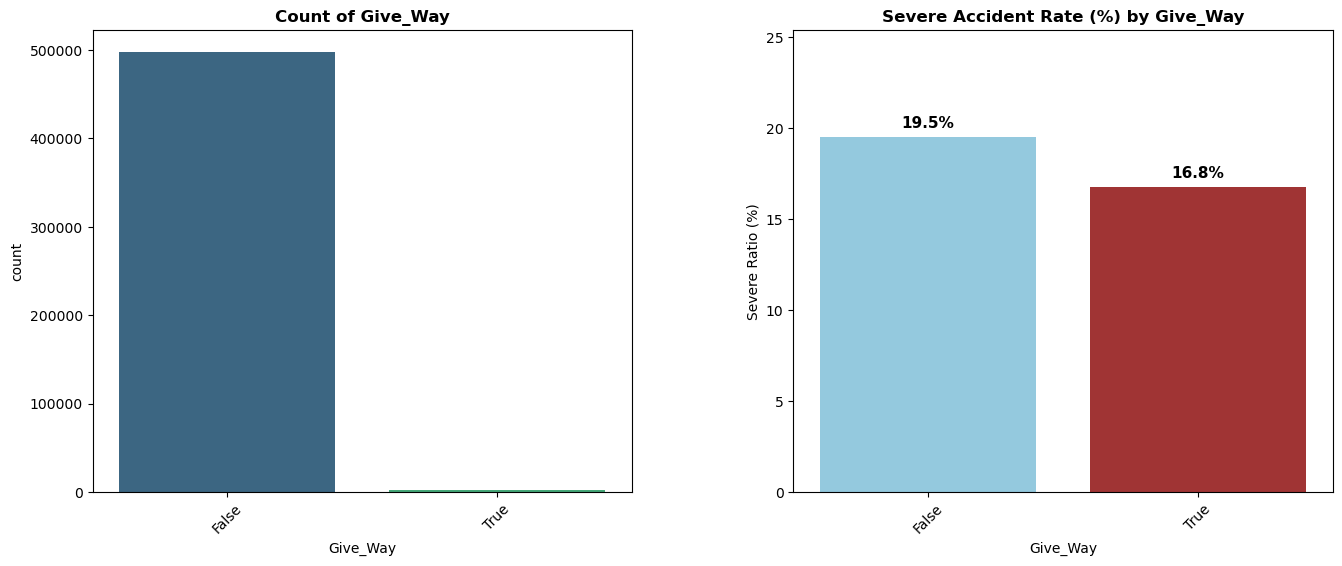

----------------------------------------------------------------------------------------------------

>>> Analyzing Feature: Junction


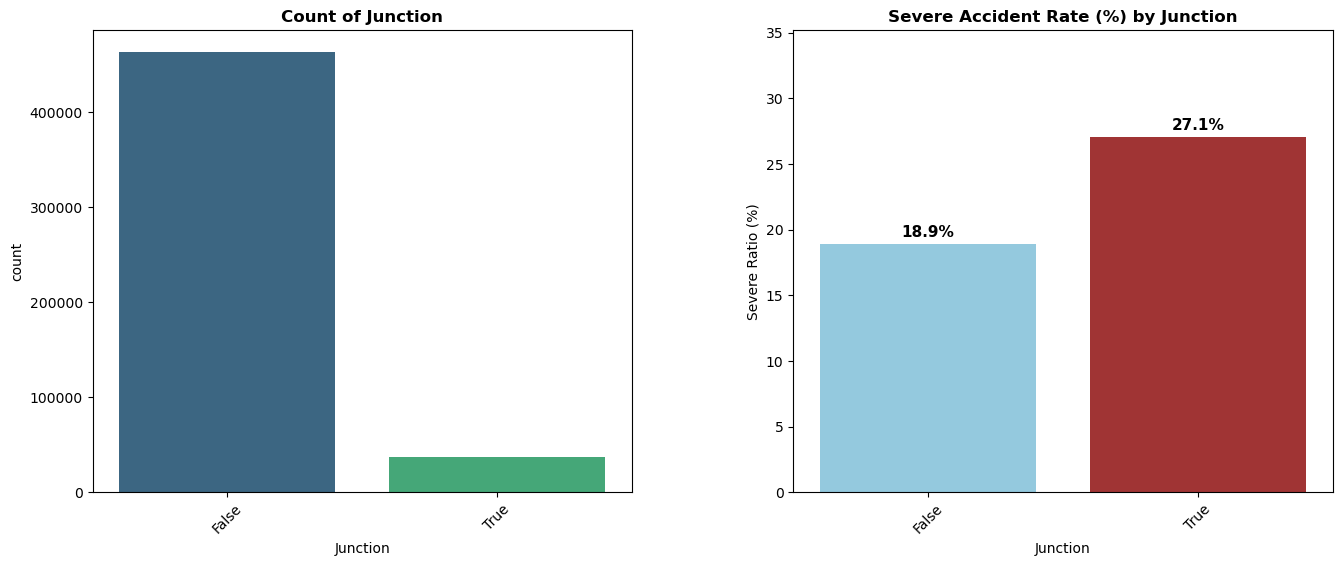

----------------------------------------------------------------------------------------------------

>>> Analyzing Feature: No_Exit


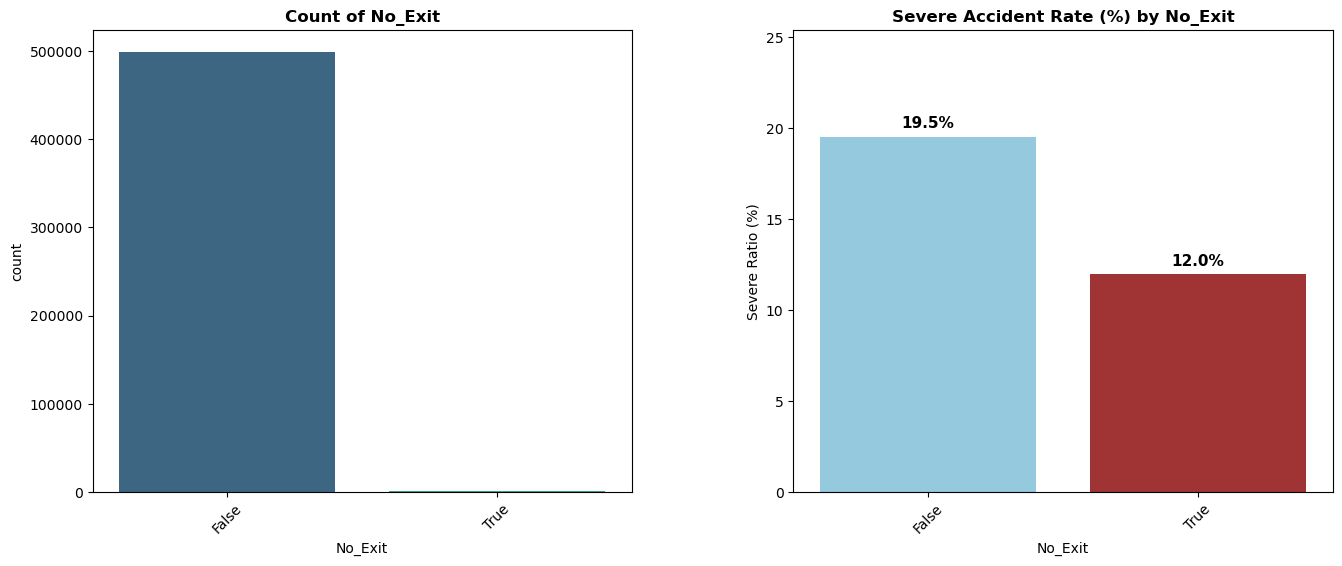

----------------------------------------------------------------------------------------------------

>>> Analyzing Feature: Railway


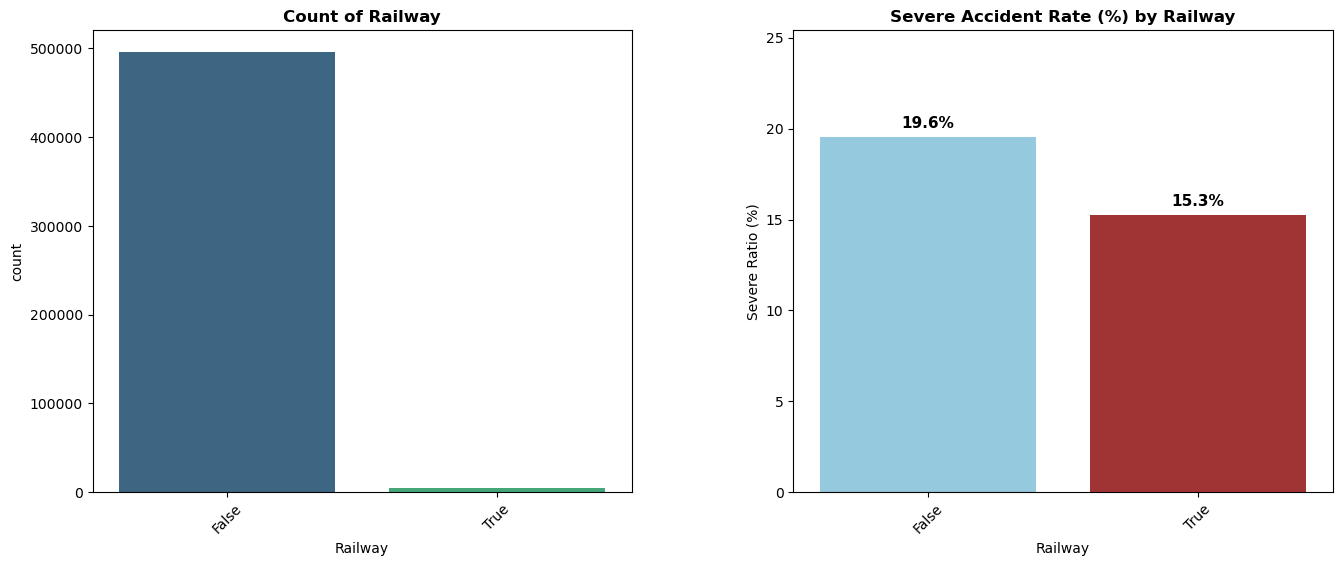

----------------------------------------------------------------------------------------------------

>>> Analyzing Feature: Roundabout


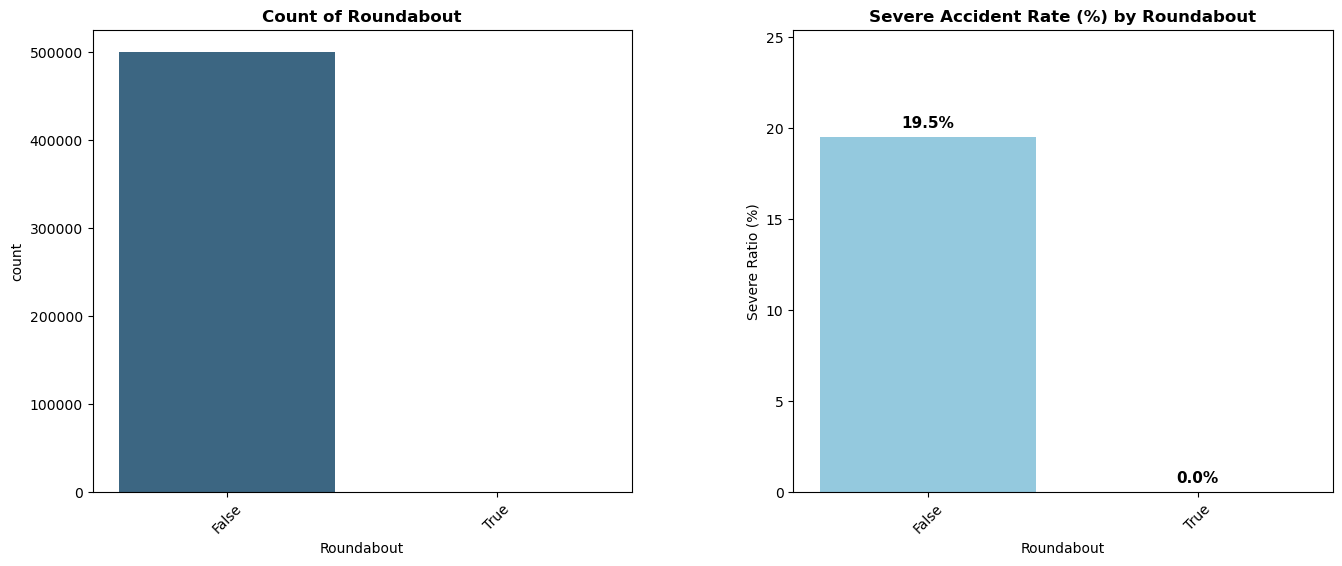

----------------------------------------------------------------------------------------------------

>>> Analyzing Feature: Station


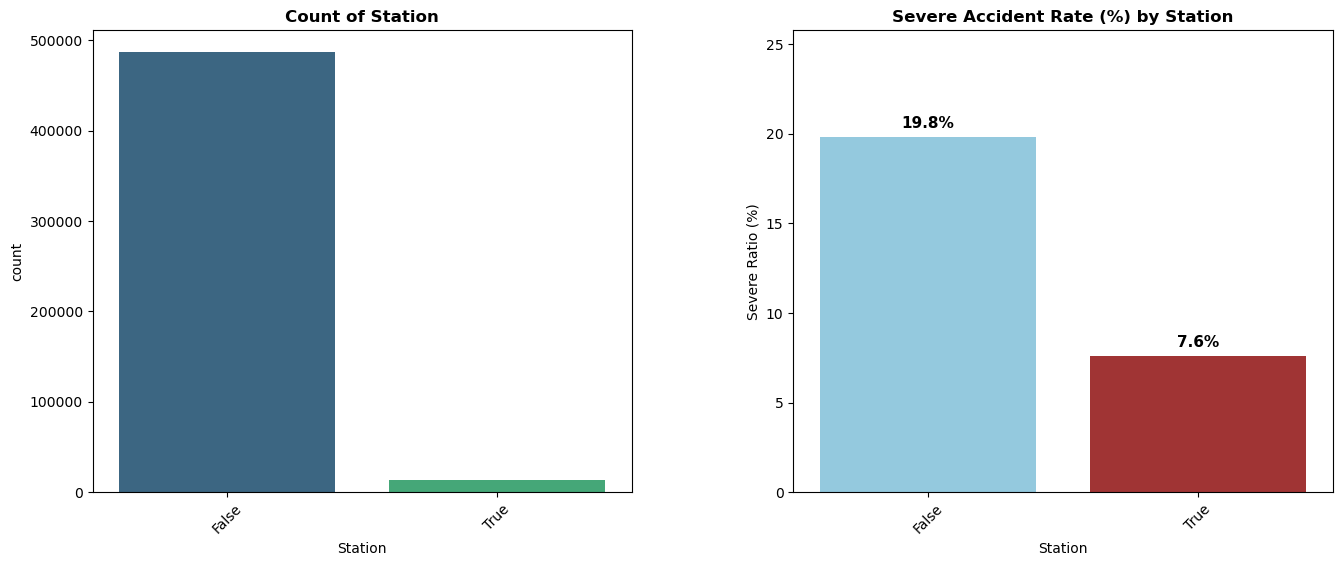

----------------------------------------------------------------------------------------------------

>>> Analyzing Feature: Stop


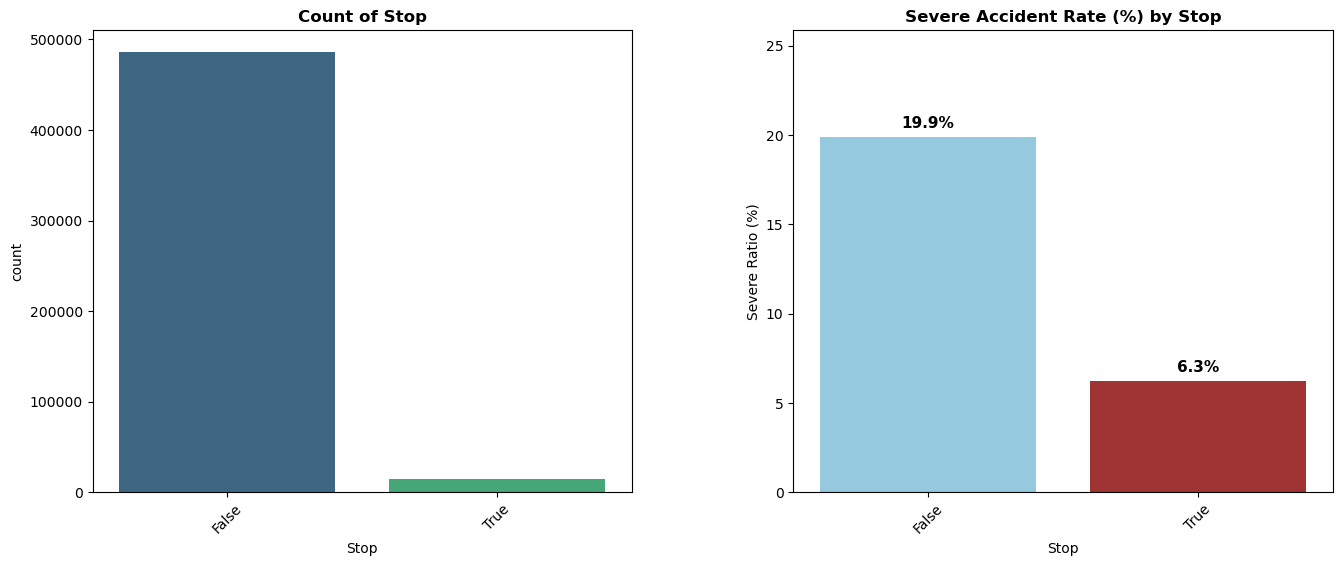

----------------------------------------------------------------------------------------------------

>>> Analyzing Feature: Traffic_Calming


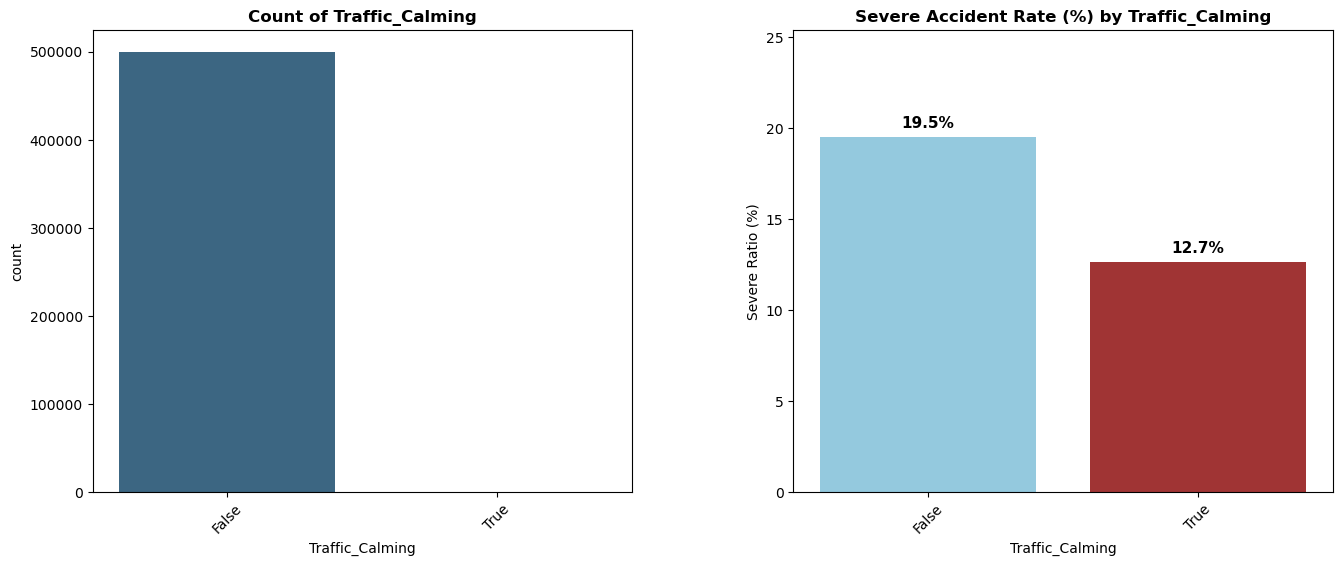

----------------------------------------------------------------------------------------------------

>>> Analyzing Feature: Traffic_Signal


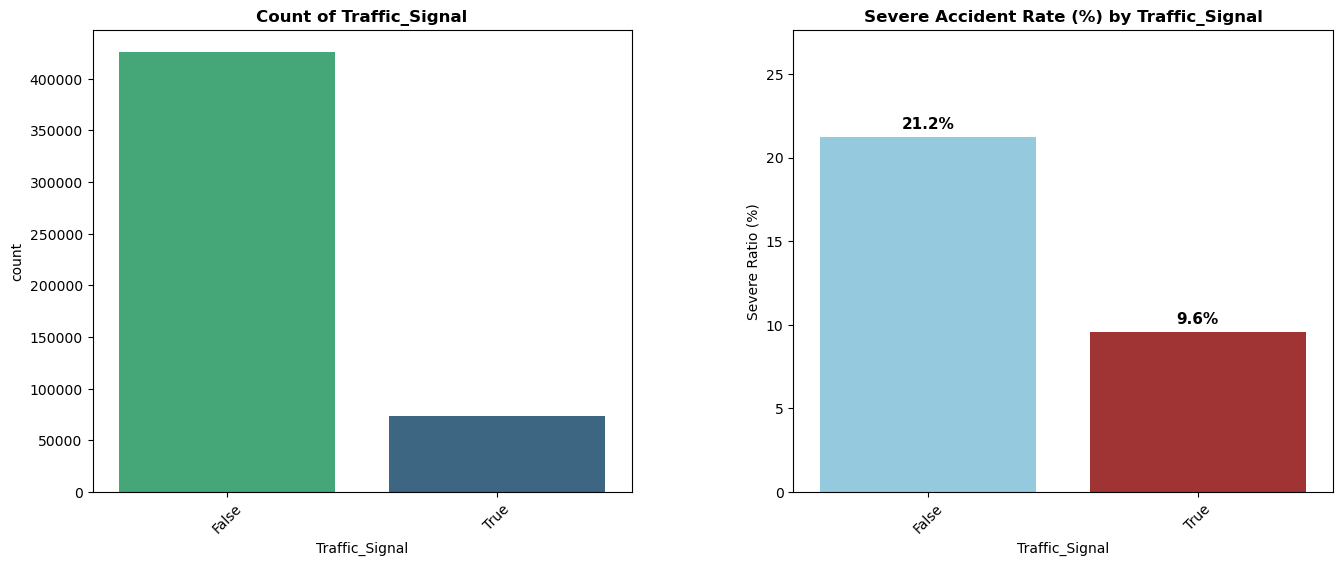

----------------------------------------------------------------------------------------------------


In [23]:
# ---------------------------------------------------------
# 5. Group C: 도로 시설물 변수 분석 (Infrastructure / POI)
# ---------------------------------------------------------

# 1. 분석할 변수 리스트 정의 (Define POI Features)
# 대부분 True/False로 이루어진 Boolean 타입 변수들입니다.
poi_cols = [
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
    'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming',
    'Traffic_Signal', 'Turning_Loop'
]

print("Analyzing Group C: Infrastructure (POI) Features...")

# ---------------------------------------------------------
# 2. 분석 함수 실행 (Execute Analysis)
# ---------------------------------------------------------
# 범주형(Boolean) 변수이므로 Barplot으로 True일 때와 False일 때의 심각도 비율 차이를 확인합니다.
analyze_feature_group(data, poi_cols, "Group C: Infrastructure Features")

Group C: 도로 시설물 변수 (Infrastructure & POI Features) 분석
1. 데이터의 희소성 (Sparsity) 및 불균형

대부분의 도로 시설물 변수(Bump, Roundabout, Traffic_Calming 등)는 False의 비율이 압도적으로 높은 희소 데이터(Sparse Data) 특성을 보인다.

특히 Roundabout(회전교차로)이나 Bump(방지턱) 등은 True 값이 육안으로 확인하기 어려울 정도로 적어, 단독 변수로 사용할 경우 모델이 패턴을 학습하기보다는 노이즈로 인식할 위험이 있다. 정보 이득이 거의 없으므로, 제거를 고려한다.

2. 시설물 유무에 따른 사고 심각도(Severity) 차이 분석 도로 시설물의 존재 여부가 사고 심각도에 미치는 영향은 시설물의 종류에 따라 극명하게 갈렸다.

교차로(Junction)의 위험성 [Critical Factor]:

시각화 결과, Junction이 있는 곳(True)에서의 심각한 사고(Severity 3, 4) 비율은 약 27%에 육박하여, 없는 곳(False)보다 3배 이상 높은 치명률을 보였다.

이는 교차로가 차량 간의 동선이 엇갈리고 고속 진입이나 꼬리물기 등이 발생하는 고위험 구역임을 데이터로 입증한다.

신호등(Traffic Signal)의 역설:

Traffic_Signal은 사고 발생 빈도(Count)는 높지만, 오히려 심각한 사고의 비율은 약 9.6% 수준으로 신호등이 없는 구간보다 낮게 나타났다.

이는 신호등이 있는 곳에서는 차량이 정지하거나 서행하기 때문에, 사고가 나더라도 대형 참사보다는 가벼운 접촉 사고가 주를 이루기 때문으로 해석된다.

기타 시설물 (Crossing, Station 등):

Crossing(횡단보도), Station(정류장) 등은 유무에 따른 심각도 비율 차이가 크지 않았다. 즉, 이 시설물들 자체보다는 당시의 교통량이나 보행자 유무 등 복합적인 요인이 더 크게 작용하는 것으로 보인다.

3. 전처리 및 피처 엔지니어링 전략

핵심 변수 유지: 심각도와 강력한 상관관계를 보인 Junction과 사고 특성을 명확히 구분 짓는 Traffic_Signal은 모델링의 핵심 피처로 활용한다.

희소 변수 처리: 정보량이 거의 없는 Roundabout, Turning_Loop 등은 제거하거나, 성격이 유사한 변수끼리 묶어(예: Traffic_Calming + Bump) 새로운 파생 변수를 생성하는 방안을 고려한다.

Analyzing Group D: Location & Spatial Features (Including Timezone)...


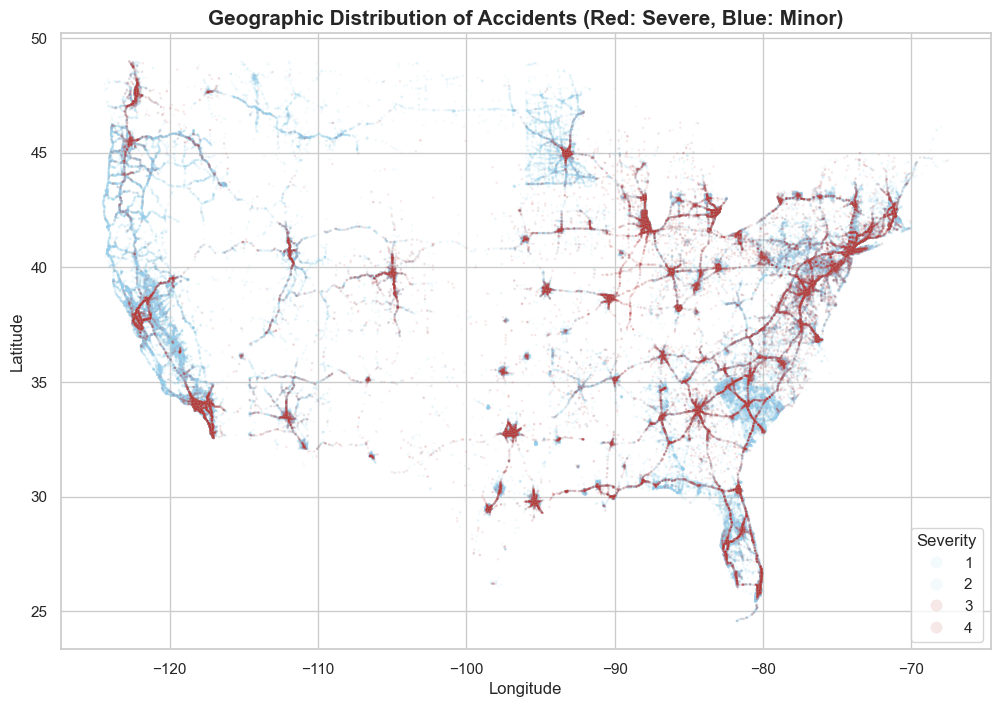

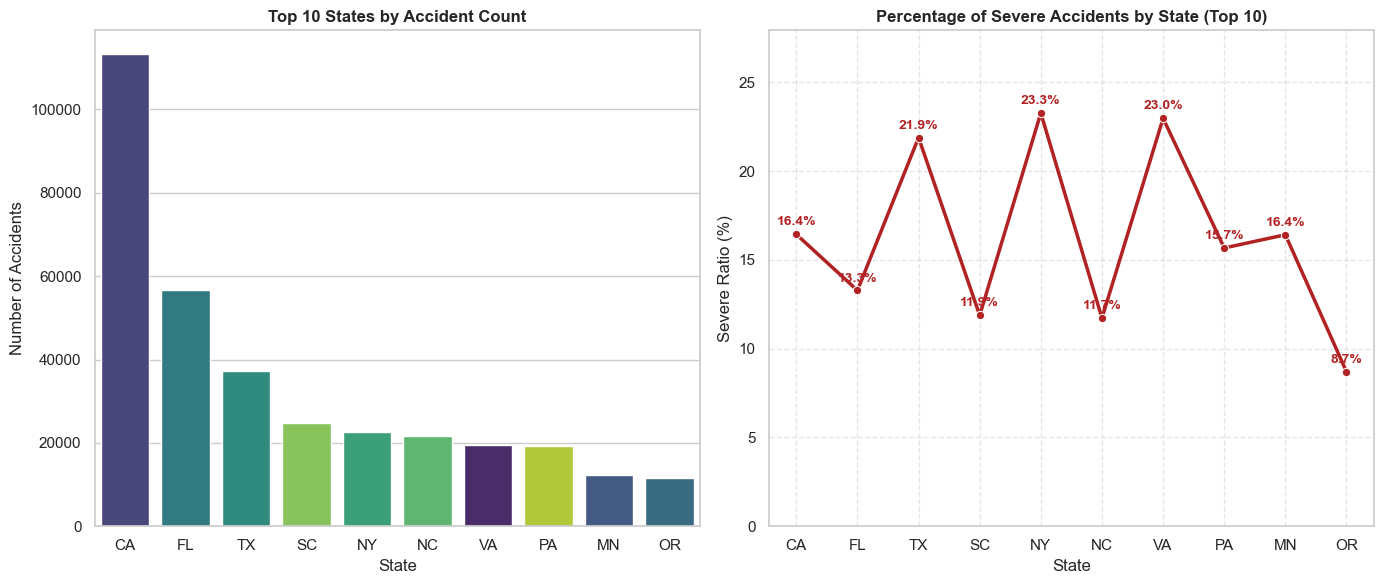

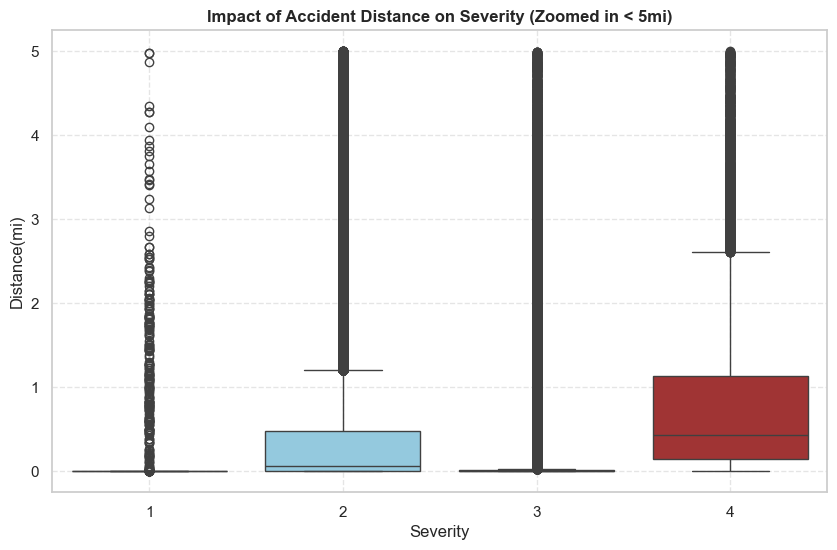


>>> Analyzing Feature: Timezone (Proxy for Location)


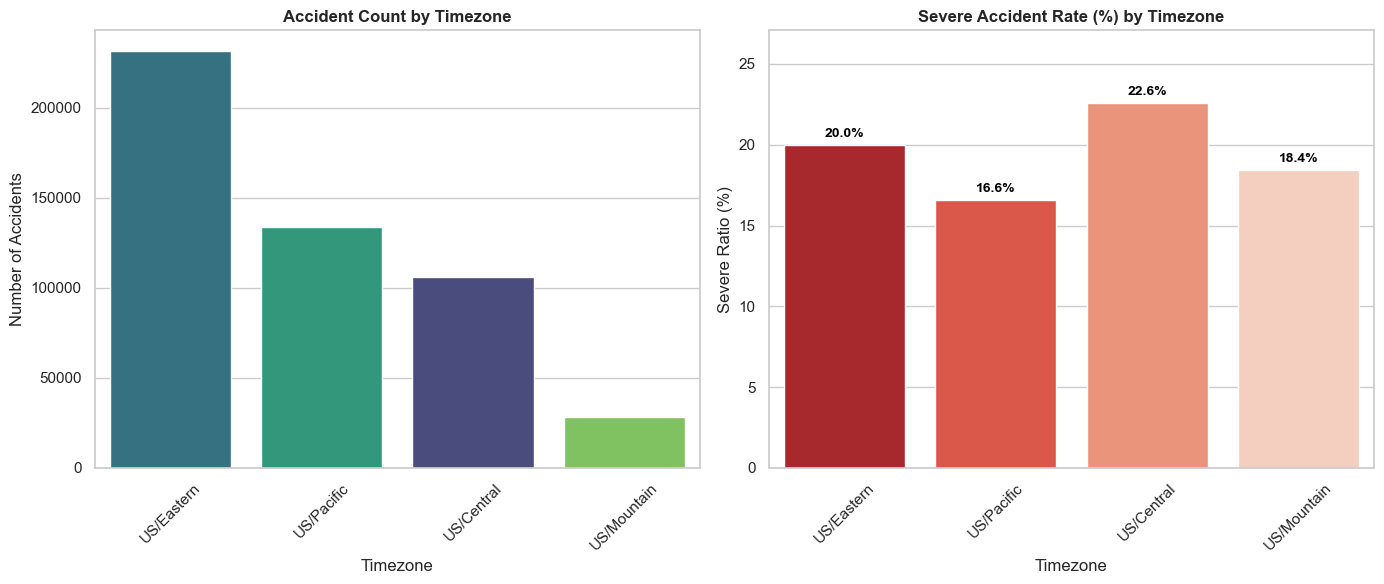


>>> Analyzing High-Cardinality Location Features...
Unique Values:
Zipcode         127804
Street           88272
City              9488
Airport_Code      1878
County            1606
State               49
dtype: int64


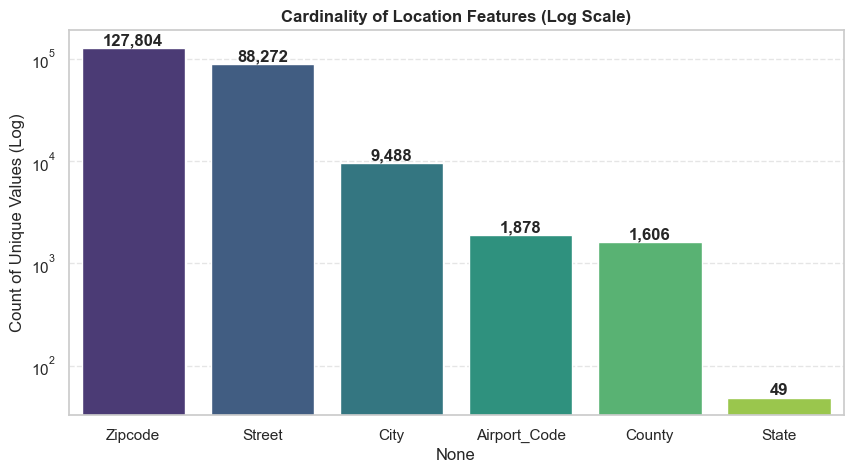

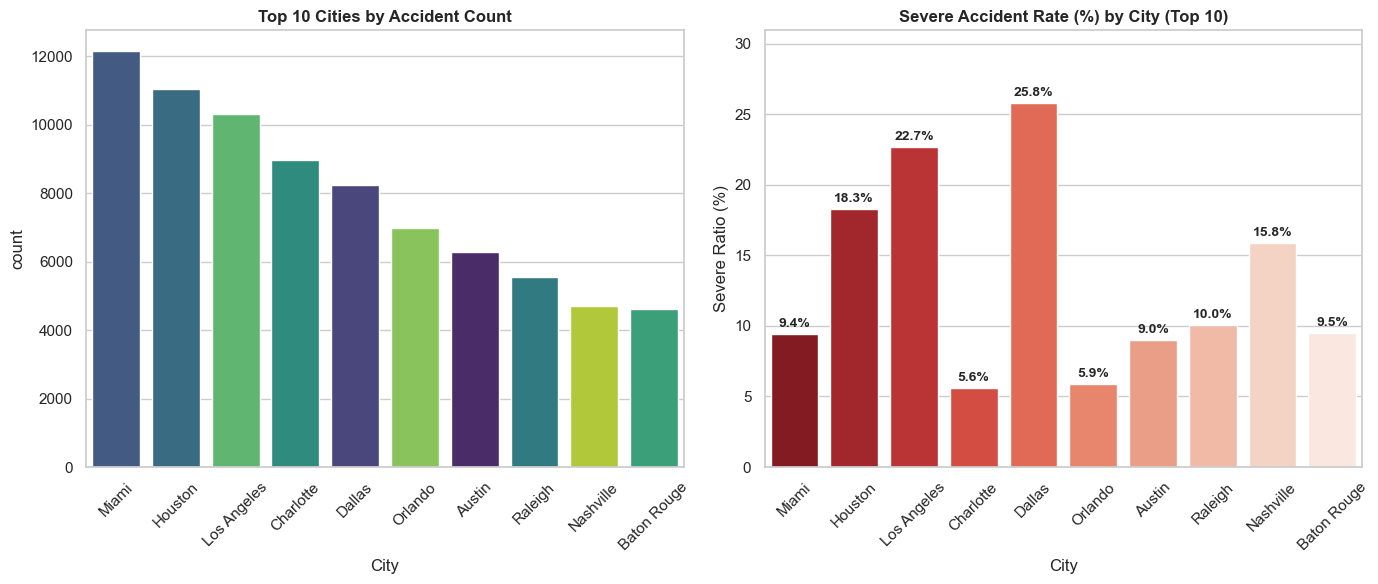

In [24]:
# ---------------------------------------------------------
# 6. Group D: 위치 및 공간 변수 분석 (Location & Spatial)
# ---------------------------------------------------------

# 시각화 스타일 설정
sns.set(style="whitegrid")

print("Analyzing Group D: Location & Spatial Features (Including Timezone)...")

# ---------------------------------------------------------
# 1. 지리적 분포 시각화 (Geographic Distribution Map)
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))

# 데이터 필터링 (Mainland US 좌표 범위로 제한하여 시각화 왜곡 방지)
map_data = data[
    (data['Start_Lng'] > -130) & (data['Start_Lng'] < -65) &
    (data['Start_Lat'] > 24) & (data['Start_Lat'] < 50)
].copy()

# [핵심] 심각한 사고가 지도 위쪽(Top)에 오도록 정렬 (Blue 점에 Red가 묻히지 않게 함)
map_data = map_data.sort_values('Severity', ascending=True)

# 색상 매핑 (1,2: Skyblue / 3,4: Firebrick)
geo_palette = {1: 'skyblue', 2: 'skyblue', 3: 'firebrick', 4: 'firebrick'}

# 산점도 그리기
sns.scatterplot(
    x='Start_Lng', y='Start_Lat',
    hue='Severity', palette=geo_palette,
    data=map_data,
    alpha=0.1, s=3,
    legend='full'
)

plt.title('Geographic Distribution of Accidents (Red: Severe, Blue: Minor)', fontsize=15, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Severity', loc='lower right', markerscale=5)
plt.show()


# ---------------------------------------------------------
# 2. 주(State)별 사고 빈도 및 심각도 분석 (Top 10 States)
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))

# 상위 10개 주 추출
top_states = data['State'].value_counts().head(10).index
state_data = data[data['State'].isin(top_states)]

# (1) 주별 사고 건수 (Bar Plot)
plt.subplot(1, 2, 1)
sns.countplot(data=state_data, x='State', order=top_states, hue='State', palette='viridis', legend=False)
plt.title('Top 10 States by Accident Count', fontweight='bold')
plt.ylabel('Number of Accidents')

# (2) 주별 심각한 사고 비율 (Line Plot)
plt.subplot(1, 2, 2)
# 심각도 3 이상인 사고의 비율 계산
state_props = state_data.groupby('State')['Severity'].apply(lambda x: (x >= 3).mean() * 100).loc[top_states]

# 꺾은선 그래프로 비율 시각화 (빨간색 강조)
sns.lineplot(x=state_props.index, y=state_props.values, marker='o', color='firebrick', linewidth=2.5)
plt.title('Percentage of Severe Accidents by State (Top 10)', fontweight='bold')
plt.ylabel('Severe Ratio (%)')
plt.ylim(0, max(state_props.values) * 1.2)
plt.grid(True, linestyle='--', alpha=0.5)

# 비율 수치 텍스트 표시
for i, v in enumerate(state_props.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=10, color='firebrick', fontweight='bold')

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 3. 사고 구간 길이(Distance)와 심각도 관계
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# 시각화를 위해 5마일 미만 데이터만 확대
filtered_dist = data[data['Distance(mi)'] < 5]

# Boxplot 색상 통일 (Blue/Red)
severity_palette = ['skyblue', 'skyblue', 'firebrick', 'firebrick']

sns.boxplot(
    x='Severity', y='Distance(mi)',
    data=filtered_dist,
    hue='Severity', palette=severity_palette, legend=False
)

plt.title('Impact of Accident Distance on Severity (Zoomed in < 5mi)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


# ---------------------------------------------------------
# 4. 시간대(Timezone)별 분석
# ---------------------------------------------------------
print("\n>>> Analyzing Feature: Timezone (Proxy for Location)")

plt.figure(figsize=(14, 6))

# 데이터 준비 (결측치 제외)
tz_data = data.dropna(subset=['Timezone'])
tz_order = tz_data['Timezone'].value_counts().index

# (1) 시간대별 사고 건수
plt.subplot(1, 2, 1)
sns.countplot(data=tz_data, x='Timezone', order=tz_order, hue='Timezone', palette='viridis', legend=False)
plt.title('Accident Count by Timezone', fontweight='bold')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)

# (2) 시간대별 심각한 사고 비율
plt.subplot(1, 2, 2)
tz_props = tz_data.groupby('Timezone')['Severity'].apply(lambda x: (x >= 3).mean() * 100).loc[tz_order]

# 막대그래프 (심각할수록 진한 빨강)
sns.barplot(x=tz_props.index, y=tz_props.values, order=tz_order, hue=tz_props.index, palette='Reds_r', legend=False)

plt.title('Severe Accident Rate (%) by Timezone', fontweight='bold')
plt.ylabel('Severe Ratio (%)')
plt.ylim(0, max(tz_props.values) * 1.2)
plt.xticks(rotation=45)

# 수치 텍스트 표시
for i, v in enumerate(tz_props.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=10, color='black', fontweight='bold')

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 5. 고차원 위치 변수 분석 (Cardinality Check)
# ---------------------------------------------------------
print("\n>>> Analyzing High-Cardinality Location Features...")

# (1) 고유값 개수(Cardinality) 확인
high_card_cols = ['State', 'County', 'City', 'Zipcode', 'Street', 'Airport_Code']
unique_counts = data[high_card_cols].nunique().sort_values(ascending=False)

print(f"Unique Values:\n{unique_counts}")

# 시각화: 변수별 고유값 개수 (Log Scale)
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=unique_counts.index, y=unique_counts.values, hue=unique_counts.index, palette='viridis', legend=False)
plt.yscale('log')  # 차이가 매우 크므로 로그 스케일 적용
plt.title('Cardinality of Location Features (Log Scale)', fontweight='bold')
plt.ylabel('Count of Unique Values (Log)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 수치 텍스트
for i, v in enumerate(unique_counts.values):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom', fontweight='bold')

plt.show()


# (2) 상위 10개 도시(City)와 심각도 분석
top_cities = data['City'].value_counts().head(10).index
city_data = data[data['City'].isin(top_cities)]

plt.figure(figsize=(14, 6))

# City 빈도
plt.subplot(1, 2, 1)
sns.countplot(data=city_data, x='City', order=top_cities, hue='City', palette='viridis', legend=False)
plt.title('Top 10 Cities by Accident Count', fontweight='bold')
plt.xticks(rotation=45)

# City 심각도 비율
plt.subplot(1, 2, 2)
city_props = city_data.groupby('City')['Severity'].apply(lambda x: (x >= 3).mean() * 100).loc[top_cities]

sns.barplot(x=city_props.index, y=city_props.values, order=top_cities, hue=city_props.index, palette='Reds_r', legend=False)
plt.title('Severe Accident Rate (%) by City (Top 10)', fontweight='bold')
plt.ylabel('Severe Ratio (%)')
plt.ylim(0, max(city_props.values)*1.2)
plt.xticks(rotation=45)

for i, v in enumerate(city_props.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Group D: 위치 및 공간 변수 (Location & Spatial Features) 분석
1. 지리적 분포 및 공간적 자기상관 (Geographic Distribution)

시각화 결과: 위도(Start_Lat)와 경도(Start_Lng)를 매핑한 결과, 사고 데이터는 미국의 주요 인구 밀집 지역(동부 해안, 서부 캘리포니아, 오대호 인근)과 주요 고속도로망을 따라 뚜렷한 군집(Cluster)을 형성하고 있다.

인사이트:

지도의 형태가 실제 미국 인구 밀도 지도와 거의 일치하며, 이는 교통량(Traffic Volume)이 사고 발생의 가장 큰 선행 지표임을 시사한다.

대부분의 지역이 경미한 사고(파란점)로 덮여 있으나, 도심지 외곽이나 특정 고속도로 구간에서 심각한 사고(빨간점)가 산발적으로 관찰되는 공간적 패턴이 존재한다.

2. 지역별 빈도와 심각도의 역설 (State Analysis)

빈도(Count) 1위: 캘리포니아(CA)가 10만 건 이상의 사고를 기록하며 압도적인 1위를 차지했다. 그 뒤를 플로리다(FL), 텍사스(TX)가 잇고 있다.

심각도(Severity)의 역전 현상:

사고 건수는 캘리포니아(CA)가 가장 많았으나, 심각한 사고(Severity 3, 4)의 비율은 약 16% 수준에 그쳤다.

반면, 뉴욕(NY), 버지니아(VA), 사우스캐롤라이나(SC) 등은 사고 건수는 상대적으로 적지만, 심각도 비율이 20%~23%로 매우 높게 나타났다.

해석: 이는 주(State)마다 상이한 도로 환경(도심 정체 vs 고속도로 비중), 제한 속도, 혹은 사고 집계 기준의 차이가 반영된 결과로 해석된다. 따라서 State 변수는 지역별 위험도를 반영하는 중요한 파생 변수(Target Encoding 대상)로 활용 가치가 높다.

3. 시간대(Timezone)와 지역적 중복성

패턴: US/Eastern(동부) 시간대가 사고 건수는 가장 많으나, 심각도 비율은 US/Central(중부) 시간대가 22.6%로 가장 높게 나타났다.

결론: 이는 앞서 수행한 지역별 분석 결과(중부의 높은 심각도)와 정확히 일치한다. 즉, Timezone은 위치 정보의 대리 변수(Proxy Variable) 역할에 불과하며, 더 정밀한 위치 정보인 Start_Lat/Lng이나 State가 이미 존재하므로 모델의 복잡도를 낮추기 위해 제거(Drop)하는 것이 타당하다.

4. 사고 구간 길이와 심각도의 관계 (Distance vs Severity)

분포 특성: Distance(mi) 변수는 대부분 0에 가까운 값을 가지나, 사고 심각도가 높아질수록 구간 길이가 길어지는 양의 상관관계를 보인다.

심각도별 차이:

Severity 2: 중앙값이 거의 0에 가까우며, 이는 단순 접촉 사고가 대부분 제자리에서 처리됨을 의미한다.

Severity 4: 중앙값이 약 0.5~0.6 mile로 현저히 높고 분포의 범위(IQR)도 넓다. 이는 치명적인 사고 발생 시 도로 통제 범위가 넓어지거나, 연쇄 추돌 등으로 사고 구간이 물리적으로 길어짐을 정량적으로 보여준다.

대응 전략: Distance(mi)는 심각도를 구분하는 강력한 Feature이므로, 오른쪽으로 긴 꼬리(Skewed) 분포를 보정하기 위해 로그 변환(Log Transformation)을 적용한 후 모델에 투입한다.

5. 세부 위치 변수(City, County, Street, Zipcode, Airport_Code)의 고차원성(High Cardinality) 문제

극단적인 범주 수: City(약 1만 개 이상), Street(수만 개), Zipcode 등의 변수는 고유값(Cardinality)이 지나치게 많아, 이를 그대로 모델에 사용할 경우 차원의 저주(Curse of Dimensionality)와 과적합(Overfitting)을 유발할 위험이 크다.

도시별 편차 (Top Cities):

사고 빈도 상위 도시를 분석한 결과, Miami, Los Angeles 등 대도시의 사고 건수가 압도적이나, 심각도 비율은 도시마다 큰 편차를 보인다.

이는 도시 정보가 유의미함을 보여주지만, 모든 도시를 변수로 쓸 수는 없으므로 빈도수 상위 n개 도시만 남기거나(Top-N Strategy), 해당 정보가 이미 위경도(Start_Lat/Lng)에 포함되어 있으므로 제거 또는 타겟 인코딩(Target Encoding)으로 차원을 축소하는 전략이 필수적이다.

결론: State는 범주 수가 적절하여(50개 내외) 사용하되, City, County, Street, Zipcode, Airport_Code는 모델링 효율을 위해 제거하거나 위경도 좌표로 대체한다.

Analyzing Group E: Astronomical & Other Features...

============================== [Group Analysis] Group E: Astronomical & Other Features ==============================

>>> Analyzing Feature: Sunrise_Sunset


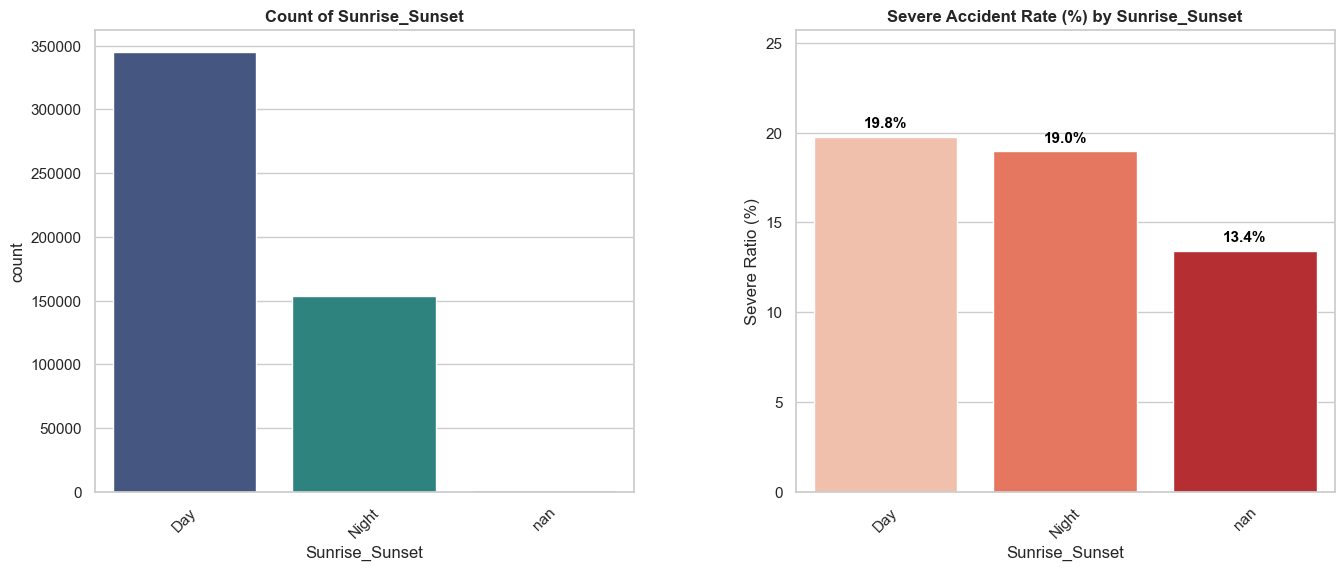

----------------------------------------------------------------------------------------------------

>>> Analyzing Feature: Civil_Twilight


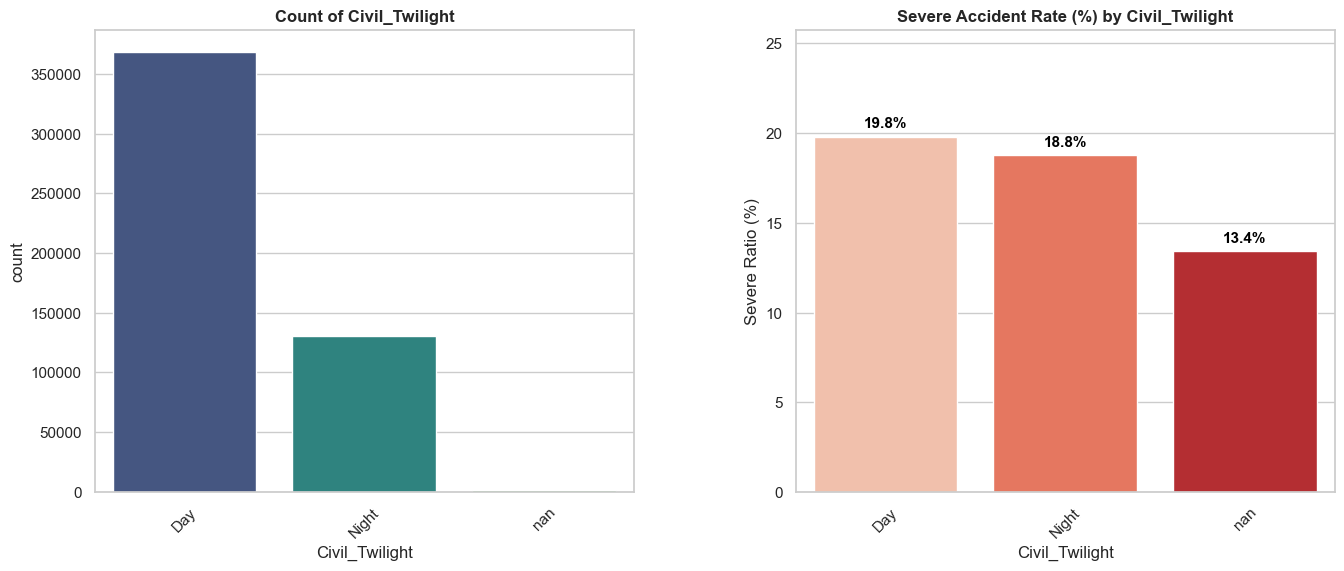

----------------------------------------------------------------------------------------------------

>>> Analyzing Feature: Nautical_Twilight


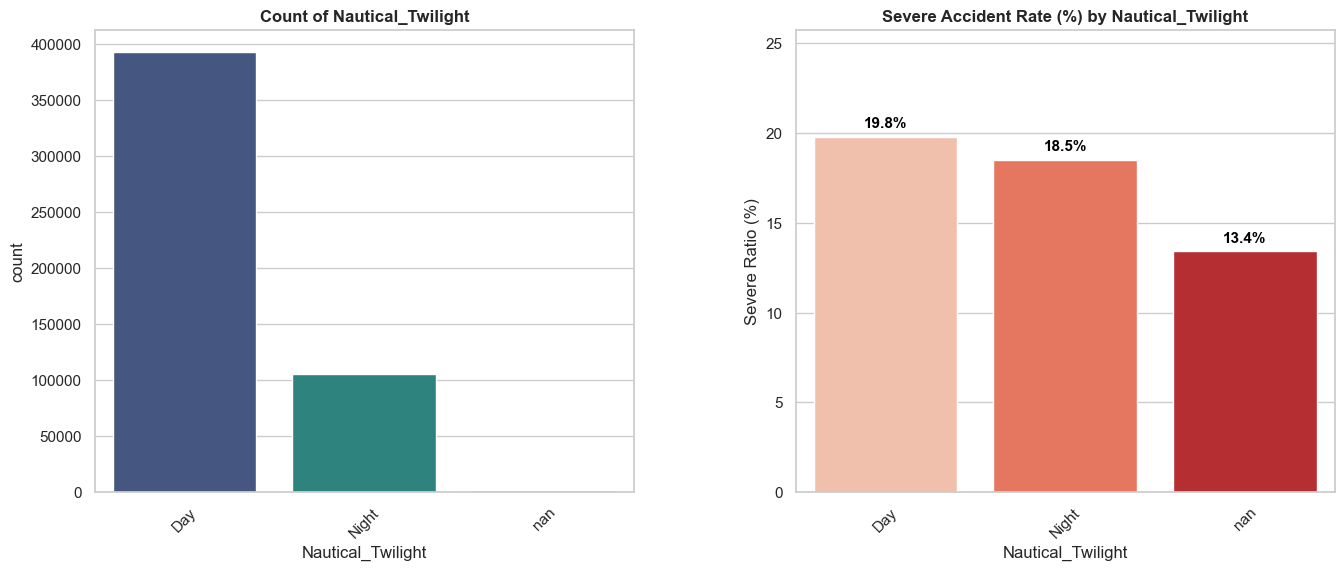

----------------------------------------------------------------------------------------------------

>>> Analyzing Feature: Astronomical_Twilight


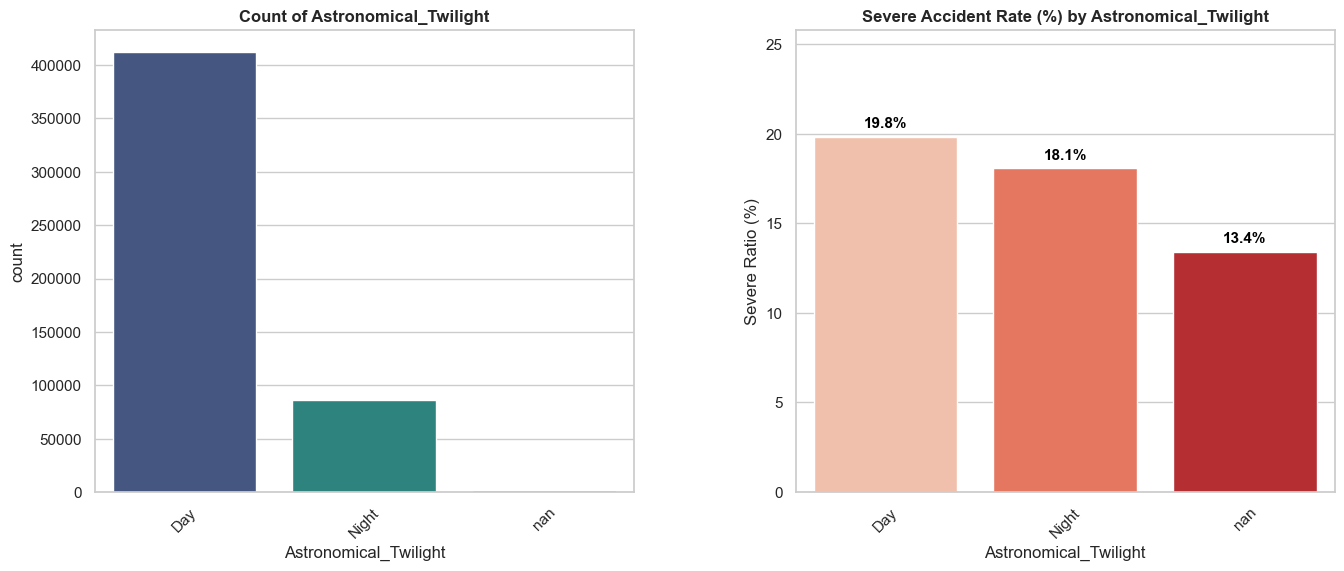

----------------------------------------------------------------------------------------------------

>>> Analyzing Feature: Timezone


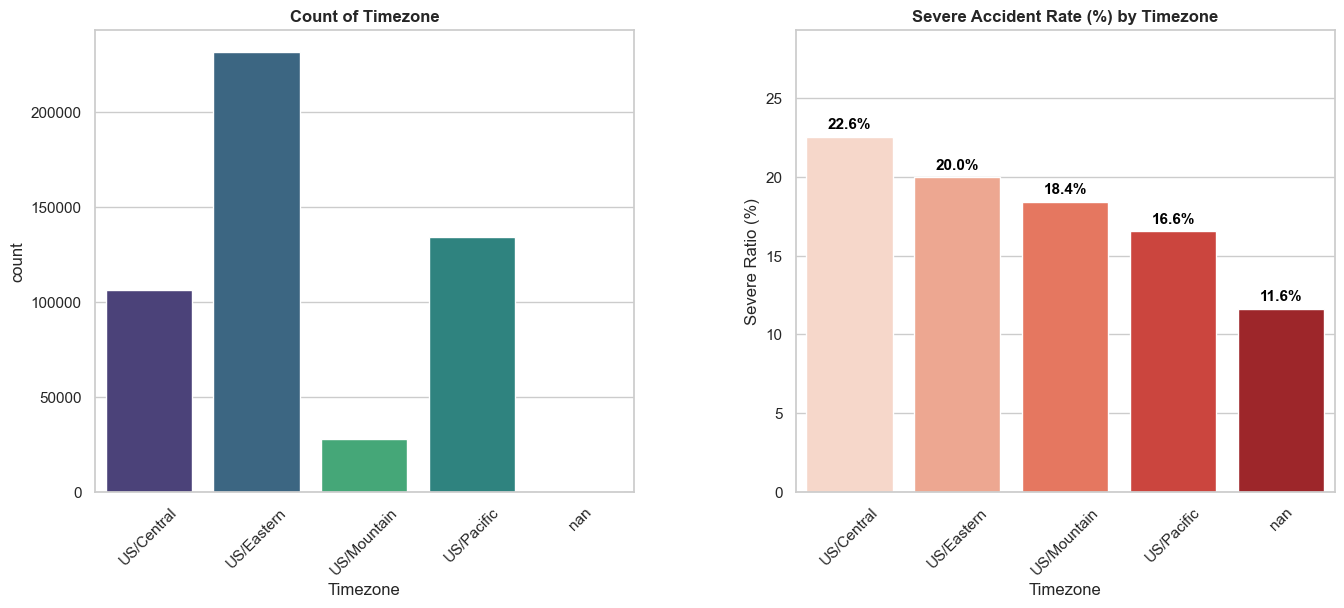

----------------------------------------------------------------------------------------------------


In [25]:
# ---------------------------------------------------------
# 7. Group E: 천문 및 기타 변수 분석 (Astronomical & Others)
# ---------------------------------------------------------

# 1. 분석할 변수 리스트 정의 (Define Variable List)
# 대부분 주간/야간(Day/Night)을 구분하는 변수들입니다.
astro_cols = [
    'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight',
    'Timezone'
]

print("Analyzing Group E: Astronomical & Other Features...")

# ---------------------------------------------------------
# 2. 분석 함수 실행 (Execute Analysis)
# ---------------------------------------------------------
# 앞서 정의한 analyze_feature_group 함수를 재사용하여 분석합니다.
analyze_feature_group(data, astro_cols, "Group E: Astronomical & Other Features")

Group E: 천문 및 기타 변수 (Astronomical & Other Features) 분석
1. 변수 간의 강한 중복성 (Redundancy)

시각화 결과: Sunrise_Sunset, Civil_Twilight, Nautical_Twilight, Astronomical_Twilight 4개 변수의 분포를 비교한 결과, Day와 Night의 비율 및 심각도 패턴이 거의 100% 일치하는 것으로 확인되었다.

해석: 이들은 "해(Sun)의 위치"를 기준으로 주야간을 나누는 기준일 뿐, 교통사고 분석 관점에서는 사실상 동일한 정보를 담고 있다.

대응 전략: 이들을 모두 모델에 투입할 경우 심각한 다중공선성(Multicollinearity) 문제가 발생하므로, 가장 직관적인 Sunrise_Sunset 하나만 남기고 나머지 3개 변수(Civil, Nautical, Astronomical)는 전처리 단계에서 과감히 제거한다.

2. 주야간에 따른 심각도 패턴 (Day vs Night)

빈도(Frequency): 당연하게도 인간의 활동 시간이 긴 주간(Day)에 사고 발생 건수가 압도적으로 많다 (약 3.5배 차이).

심각도(Severity):

흥미롭게도 Sunrise_Sunset 기준으로 볼 때, 주간(Day)의 심각한 사고 비율(19.8%)이 야간(Night)(19.0%)보다 미세하게 높거나 비슷하게 나타났다.

이는 앞서 3.3.2. 시간대(Hour) 분석에서 "새벽 3~4시에 심각도가 치솟았던 결과"와 다소 상충되는 것처럼 보일 수 있다.

원인 분석: Night 범주 안에는 사고가 잦고 정체가 심한 '초저녁(Evening)'과, 치명적인 사고가 많은 '심야(Midnight)'가 섞여 있어, 평균적으로는 심각도가 희석된 것으로 해석된다. 따라서 단순한 Day/Night 이진 변수보다는 시간대(Hour) 변수가 심각도 예측에 더 중요한 역할을 할 것이다.


###3.4 변수 간 상관관계 분석

=== [3.4] Correlation Analysis ===


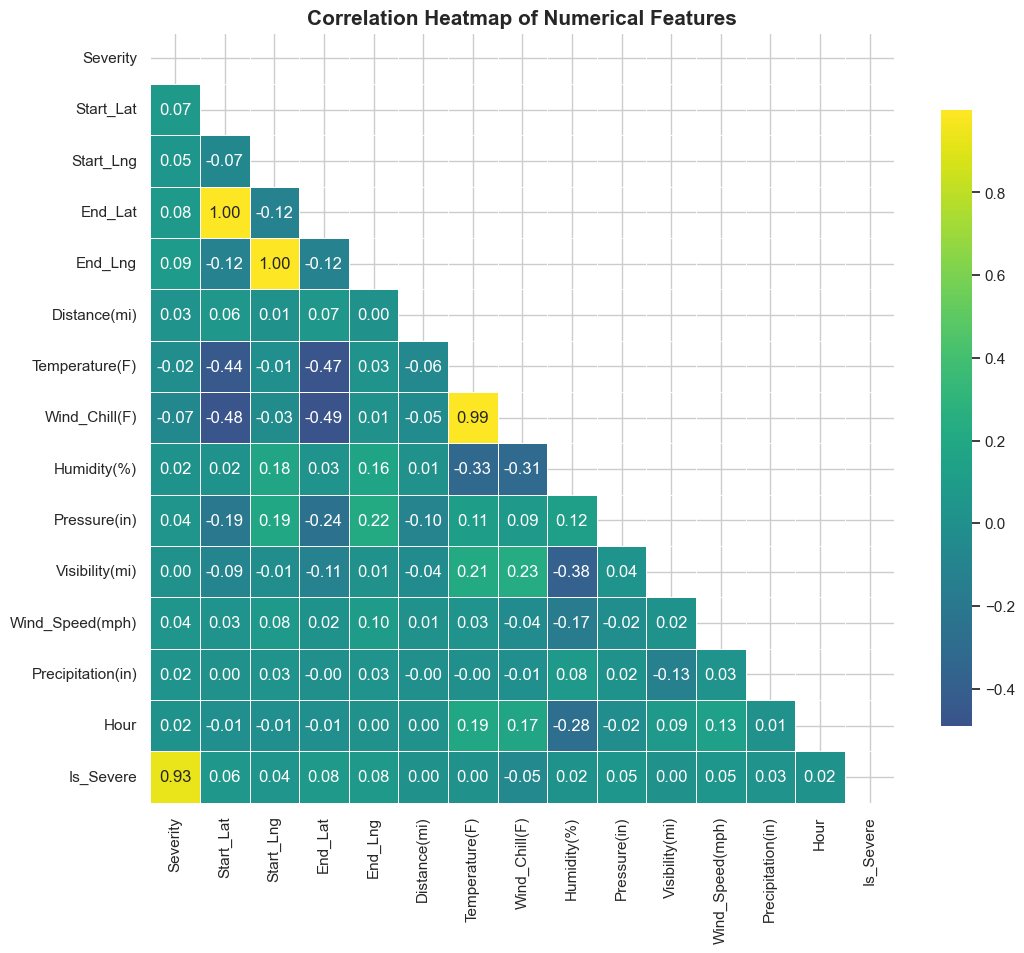

In [26]:
# =========================================================
# 3.4. 변수 간 상관관계 분석
# =========================================================

# ---------------------------------------------------------
# 1. 상관계수 계산 (Calculate Correlation Matrix)
# ---------------------------------------------------------
print("=== [3.4] Correlation Analysis ===")

# 수치형 변수만 선택 (Select numerical columns)
numeric_cols = data.select_dtypes(include=[np.number]).columns

# 상관계수 행렬 계산 (Calculate correlation)
corr_matrix = data[numeric_cols].corr()

# ---------------------------------------------------------
# 2. 히트맵 시각화 (Visualize Heatmap)
# ---------------------------------------------------------
plt.figure(figsize=(12, 10))

# 상단 삼각형 마스킹 (Mask upper triangle)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 히트맵 그리기
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,      # 수치 표시
    fmt=".2f",       # 소수점 2자리
    cmap='viridis',  # 색상 테마
    linewidths=.5,
    center=0,        # 0을 기준으로 색상 분기
    cbar_kws={"shrink": .8}
)

plt.title('Correlation Heatmap of Numerical Features', fontsize=15, fontweight='bold')
plt.show()

수치형 변수 간의 Pearson 상관계수를 히트맵으로 시각화하여 분석한 결과, 전처리 및 모델링 전략에 결정적인 두 가지 특징이 식별되었다.

1. 다중공선성(Multicollinearity) 진단 및 변수 제거

Temperature(F)와 Wind_Chill(F): 두 변수 간의 상관계수는 0.99로, 사실상 완벽한 양의 상관관계를 보인다. 이는 두 변수가 거의 동일한 정보를 담고 있음을 의미하며, 함께 투입할 경우 모델의 학습을 방해하고 과적합을 유발할 수 있다.

전처리 결정: 데이터 결측률이 더 높고(25.8%), 기온 정보와 중복되는 Wind_Chill(F)을 제거하여 모델의 복잡도를 낮춘다.

기타: End_Lat/Lng과 Start_Lat/Lng 역시 1.00에 가까운 상관관계를 보이나, End 좌표는 앞서 결측치 문제로 제거가 확정되었으므로 별도의 조치는 불필요하다.

2. 타겟 변수 사고 심각도(Severity)와의 관계 및 모델링 시사점

낮은 선형 상관성: 타겟 변수인 사고 심각도(Severity)와 주요 수치형 변수들(Distance, Temperature, Humidity 등) 간의 상관계수는 대부분 0.00 ~ 0.09 사이의 매우 낮은 수치를 기록했다.

해석: 이는 사고 심각도가 단일 변수와 단순한 비례/반비례 관계(Linear Relationship)를 갖지 않음을 시사한다. 즉, 심각도는 "기온이 낮으면서 + 안개가 끼고 + 교차로일 때"와 같이 여러 조건이 복합적으로 작용할 때 결정되는 비선형적(Non-linear) 특성을 가진다.

모델링 전략: 따라서 선형 회귀(Linear Regression)보다는 변수 간의 복잡한 상호작용과 비선형 패턴을 효과적으로 포착할 수 있는 트리 기반 모델(Random Forest, XGBoost, LightGBM)이 본 프로젝트에 적합함을 통계적으로 뒷받침한다.

Calculating Cramér's V correlation matrix... (This might take a moment)


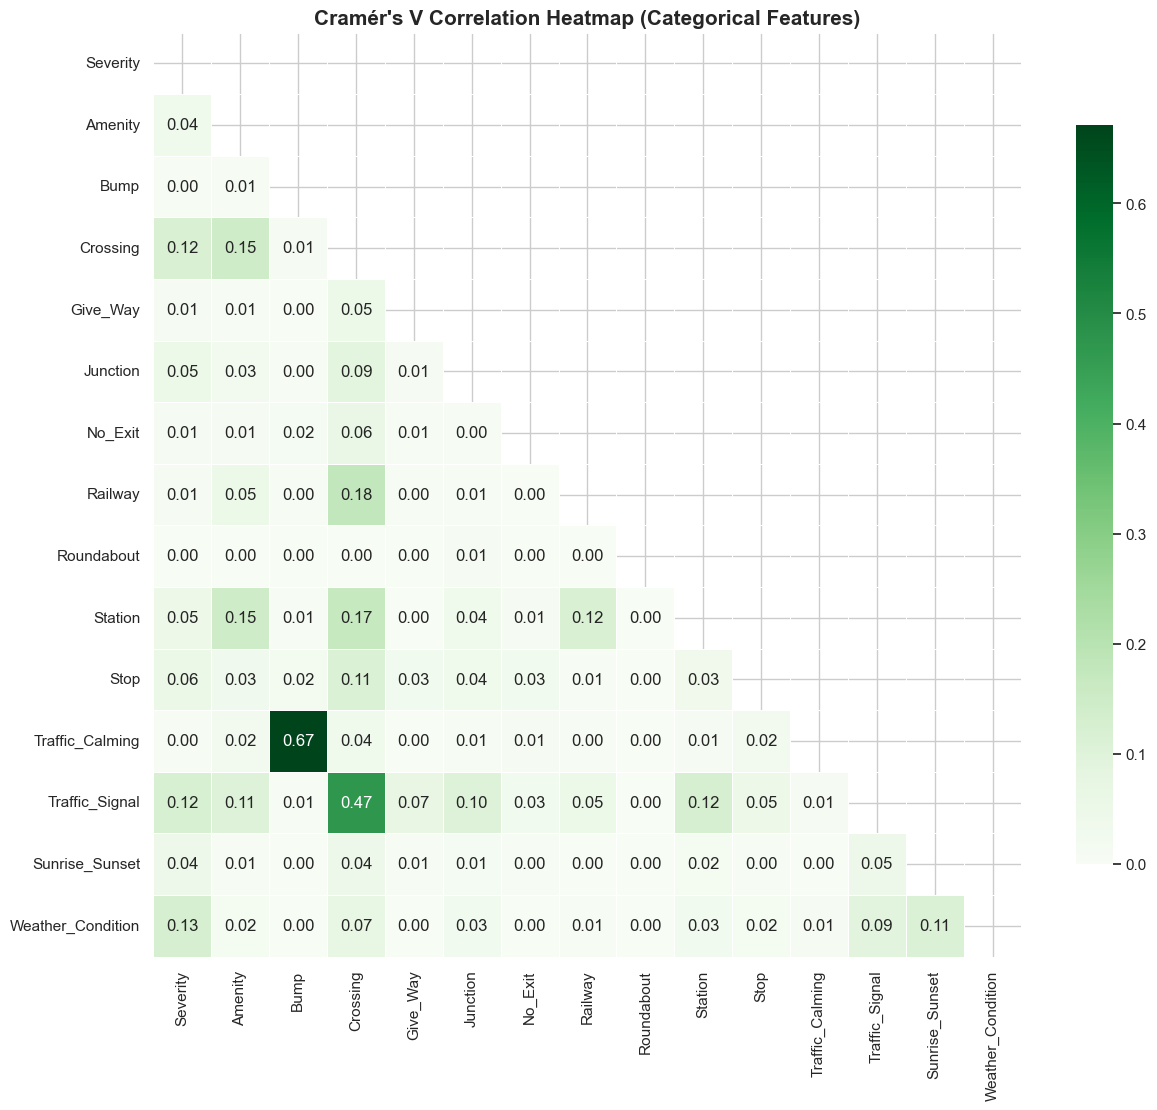

In [27]:
# ---------------------------------------------------------
# 3. 범주형 변수 상관관계 분석 (Cramer's V Correlation)
# ---------------------------------------------------------
from scipy.stats import chi2_contingency

# ---------------------------------------------------------
# 3-1. 크래머 브이(Cramer's V) 계산 함수 정의
# ---------------------------------------------------------
def cramers_v(x, y):
    """
    [함수 설명]
    두 범주형 변수 간의 연관성을 0~1 사이 값으로 반환합니다.
    - Bias Correction(편향 보정)을 적용하여 더 정확한 수치를 계산합니다.
    """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    # 편향 보정 (Bias Correction)
    with np.errstate(divide='ignore', invalid='ignore'):
        phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
        rcorr = r - ((r-1)**2)/(n-1)
        kcorr = k - ((k-1)**2)/(n-1)
        if min((kcorr-1), (rcorr-1)) == 0:
            return 0
        return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# ---------------------------------------------------------
# 3-2. 분석 대상 변수 선택 및 데이터 준비
# ---------------------------------------------------------
# Severity(타겟)를 포함한 주요 범주형 변수 리스트
categorical_cols = [
    'Severity', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction',
    'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming',
    'Traffic_Signal', 'Sunrise_Sunset', 'Weather_Condition'
]

# 계산 속도를 위해 사본 데이터 사용
cat_data = data[categorical_cols].copy()

# Boolean(True/False)을 문자열로 변환하여 계산 오류 방지
for col in cat_data.columns:
    cat_data[col] = cat_data[col].astype(str)

print("Calculating Cramér's V correlation matrix... (This might take a moment)")

# ---------------------------------------------------------
# 3-3. 상관계수 행렬 계산 (Calculate Matrix)
# ---------------------------------------------------------
rows = []
for var1 in categorical_cols:
    col = []
    for var2 in categorical_cols:
        cramers = cramers_v(cat_data[var1], cat_data[var2])
        col.append(cramers)
    rows.append(col)

cramers_results = pd.DataFrame(rows, columns=categorical_cols, index=categorical_cols)

# ---------------------------------------------------------
# 3-4. 히트맵 시각화 (Visualize Heatmap)
# ---------------------------------------------------------
plt.figure(figsize=(14, 12))

# 대각선 윗부분 가리기 (Mask upper triangle)
mask = np.triu(np.ones_like(cramers_results, dtype=bool))

sns.heatmap(
    cramers_results,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='Greens',  # 초록색 계열 사용 (수치형과 구분)
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title("Cramér's V Correlation Heatmap (Categorical Features)", fontsize=15, fontweight='bold')
plt.show()

범주형 변수 연관성 분석 (Categorical Association Analysis)
범주형 변수 간의 연관성을 측정하는 Cramér's V (0~1) 통계량을 분석한 결과, 변수 간의 다중공선성과 타겟 변수에 대한 영향력이 다음과 같이 확인되었다.

1. 변수 간의 강한 중복성 (Redundancy)

Bump와 Traffic_Calming (0.67): 두 변수 간의 연관성은 0.67로 매우 높게 나타났다. 이는 '과속방지턱(Bump)'이 '교통 정온화 시설(Traffic Calming)'의 하위 개념이기에 발생하는 필연적인 의미 중복이다.

Traffic_Signal과 Crossing (0.47): 신호등과 횡단보도는 물리적으로 함께 설치되는 경우가 많아 높은 연관성을 보인다.

시사점: Bump는 Traffic_Calming에 포함되거나 대체될 수 있으므로, 모델의 복잡도를 줄이기 위해 변수 통합(Feature Merging) 혹은 제거를 고려해야 한다.

2. 타겟 변수 사고 심각도(Severity)와의 연관성

상대적으로 높은 영향력: 앞서 수치형 변수(기온, 습도 등)와 사고 심각도(Severity) 간의 피어슨 상관계수가 0.05 미만이었던 것과 대조적으로, 범주형 변수들은 상대적으로 유의미한 연관성을 보였다.

Weather_Condition (0.13): 가장 높은 수치를 기록하며, 날씨 상태가 사고 심각도를 가르는 주요 변수임을 통계적으로 입증했다.

Traffic_Signal (0.12) & Crossing (0.12): 도로 시설물의 유무 또한 심각도 결정에 중요한 역할을 수행한다.

모델링 전략: 수치형 변수보다 범주형 변수(날씨, 시설물)가 타겟 변수와 더 강한 연관성을 보이므로, 범주형 변수를 효과적으로 분기(Split)하여 학습하는 트리 기반 모델(Tree-based Model)의 성능이 우수할 것으로 예측된다.

### 3.5. 전처리 전략 요약

앞선 EDA 및 상관관계 분석(Correlation Analysis) 결과를 바탕으로, 46개 전체 변수에 대한 최종 처리 방안을 확정한다. 본 연구는 데이터 누수 방지, 다중공선성 해소, 그리고 모델의 복잡도 제어를 위해 "제거(Drop) - 보간(Impute) - 변환(Transformation)"의 체계적인 전처리 파이프라인을 수립하였다.

**Table. Feature Engineering & Preprocessing Strategy Matrix**

| 분석 그룹 | 대상 변수 (Feature) | 처리 방안 (Action) | 근거 및 세부 전략 (Rationale & Correlation Evidence) |
| :--- | :--- | :--- | :--- |
| **Target** | **`Severity`** | **Preserve** | 클래스 불균형(Class Imbalance) 존재. 수치형 변수와의 낮은 선형 상관관계(**Pearson < 0.1**)는 비선형(Tree-based) 모델 사용을 지지함. |
| **A. Temporal** | `Start_Time` | **Impute & Feature Extraction** | 결측치를 'Weather_Timestamp'로 매핑하여 98.1%복구. 이후 `Hour`, `Weekday`, `Month` 추출. (`is_night`, `is_rushhour` 파생 변수 고려). |
| | `End_Time` | **Drop** | **Data Leakage(사후 정보)** 위험 및 `Start_Time`과 정보 중복. |
| | `Weather_Timestamp` | **Impute Source & Drop** | `Start_Time` 결측치 보간에 활용한 후, 정보 중복으로 최종 제거. |
| **B. Weather** | `Temperature(F)` | **Impute & Filter** | 물리적 이상치 제거 후 중앙값 보간. |
| | **`Wind_Chill(F)`** | **Drop** | **[Multicollinearity]** `Temperature`와 완벽한 양의 상관관계(**Pearson 0.99**)를 보이므로 제거. |
| | `Humidity(%)`, `Pressure(in)` | **Impute (Median)** | 정규분포를 따르지 않으므로 중앙값으로 결측치 보간. |
| | `Visibility(mi)` | **Impute (Median)** | 결측치는 중앙값 보간. 낮은 시정 구간의 사고 위험도 반영. |
| | `Wind_Speed(mph)` | **Log Transform** | 우측 편향(Right-skewed) 및 이상치 완화를 위해 로그 변환 적용. |
| | `Precipitation(in)` | **Log Transform** | Zero-inflated 분포. 결측치는 0으로 채우고 로그 변환 적용. |
| | **`Weather_Condition`** | **Remapping** | **[High Correlation]** 범주형 중 심각도와 높은 연관성(**Cramér's V 0.13**) 확인. 희소 범주 통합(Clear, Rain, Snow 등). |
| | `Wind_Direction` | **Drop** | 풍향 정보의 노이즈가 심하고, 풍속(Speed) 유무보다 중요도가 낮음. |
| **C. POI** | `Junction`, `Traffic_Signal` | **Keep (Boolean)** | **[High Correlation]** 사고 심각도와 유의미한 연관성을 보이는 핵심 시설물. |
| | `Crossing`, `Station`, `Stop` | **Keep (Boolean)** | 유의미한 빈도를 가지며 유지 가치 있음. |
| | **`Bump`**, `Amenity`, `Roundabout` | **Drop** | **[Redundancy & Sparsity]** `Bump`는 `Traffic_Calming`과 높은 연관성(**0.67**)을 가지며, 희소성이 극심하여 제거. |
| | `Turning_Loop` | **Drop** | 모든 값이 False인 상수 변수(Constant). |
| **D. Location** | `Start_Lat`, `Start_Lng` | **Keep** | 지리적 매핑 및 교통량(Traffic Volume) 대리 변수. |
| | **`End_Lat`, `End_Lng`** | **Drop** | `Start` 좌표와 상관계수 **~1.00**으로 정보 중복되며, 결측률이 높아 제거. |
| | `Distance(mi)` | **Log Transform** | 치명적 사고일수록 구간이 긴 특성. 꼬리가 긴 분포를 로그 변환으로 보정. |
| | `State` | **Keep / Encoding** | 지역별 위험도 반영을 위해 유지 (Target Encoding 등 고려). |
| | `Timezone` | **Drop** | `State` 변수와 정보가 중복되는 대리 변수(Proxy). |
| | `City`, `County`, `Street` | **Drop** | **High Cardinality.** 좌표 정보로 대체 가능하며 과적합 유발 위험. |
| | `Zipcode`, `Airport_Code` | **Drop** | 세부 위치 정보 중복. |
| **E. Astronomical** | `Sunrise_Sunset` | **Keep** | 주간/야간(`Day`/`Night`) 패턴 반영. |
| | `Civil`, `Nautical` 등 | **Drop** | `Sunrise_Sunset`과 분포가 거의 일치하는 중복 정보. |
| **Other** | `ID`, `Source`, `Description` | **Drop** | 식별자, 비정형 텍스트, 인과관계 없는 메타데이터. |
| | `Country` | **Drop** | 단일 값('US')만 존재하는 상수 변수. |

# 4. 데이터 전처리


### 4.1 이상치 수정 및 결측치 처리


In [28]:
# =========================================================
# 4.1. 데이터 정제 및 이상치 제거 (Data Cleaning)
# =========================================================

print("="*50)
print(">>> Start Step 4.1: Data Cleaning & Outlier Removal")
print("="*50)

df_clean = data.copy()
initial_shape = df_clean.shape

# 1. Start_Time 복구 및 datetime 변환
df_clean['Start_Time'] = pd.to_datetime(df_clean['Start_Time'], errors='coerce')
df_clean['Weather_Timestamp'] = pd.to_datetime(df_clean['Weather_Timestamp'], errors='coerce')
df_clean['Start_Time'] = df_clean['Start_Time'].fillna(df_clean['Weather_Timestamp'])

# 2. 중복 데이터 제거
df_clean.drop_duplicates(inplace=True)

# 3. 불필요한 변수 제거
cols_to_drop = [
    'ID', 'Source', 'Weather_Timestamp', 'Wind_Chill(F)', 'Wind_Direction',
    'End_Lat', 'End_Lng', 'Country', 'Timezone', 'Airport_Code',
    'Zipcode', 'Street', 'County', 'City',
    'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight',
    'Amenity', 'Bump', 'Roundabout', 'Turning_Loop', 'Description'
]
df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns], inplace=True)

# 4. 물리적 이상치 제거
if 'Temperature(F)' in df_clean.columns:
    df_clean = df_clean[df_clean['Temperature(F)'].isnull() | ((df_clean['Temperature(F)'] >= -50) & (df_clean['Temperature(F)'] <= 140))]

if 'Wind_Speed(mph)' in df_clean.columns:
    df_clean = df_clean[df_clean['Wind_Speed(mph)'].isnull() | (df_clean['Wind_Speed(mph)'] < 200)]

if 'Precipitation(in)' in df_clean.columns:
    df_clean = df_clean[df_clean['Precipitation(in)'].isnull() | (df_clean['Precipitation(in)'] >= 0)]

# 5. 시간 데이터 정합성 확인 및 End_Time 제거
df_clean['End_Time'] = pd.to_datetime(df_clean['End_Time'], errors='coerce')
# End_Time이 있는 경우에만 정합성 체크
df_clean = df_clean[df_clean['End_Time'].isnull() | (df_clean['End_Time'] >= df_clean['Start_Time'])]
df_clean.drop(columns=['End_Time'], inplace=True)

# 6. 잔여 결측치 제거
df_clean.dropna(subset=['Start_Time'], inplace=True)

print("-" * 50)
print(f"Final Shape after Cleaning: {df_clean.shape}")
print("-" * 50)

>>> Start Step 4.1: Data Cleaning & Outlier Removal
--------------------------------------------------
Final Shape after Cleaning: (499084, 28)
--------------------------------------------------


데이터의 무결성을 확보하고 정보 손실을 최소화하기 위해, 사전 수립된 전처리 전략에 따라 심층적인 정제 및 보간 작업을 수행하였다.


차원 축소 및 이상치 제거:분석 가치가 낮거나 정보 누수(Data Leakage) 우려가 있는 ID, Source, End_Time 및 복구에 사용된 Weather_Timestamp 등 22개 변수를 제거하여 차원을 축소(46개 $\rightarrow$ 28개)하였다.기상 변수의 물리적 이상치(Physical Outliers)와 중복 행(Duplicates)을 식별하여 삭제하였다.최종적으로 전체 데이터의 0.17% (855건) 만을 정제하여, 데이터 손실을 최소화하면서도 고품질의 데이터셋(N=499,084)을 구축하였다.

In [29]:
# =========================================================
# 4.1. (계속) 결측치 보간 (Missing Value Imputation)
# =========================================================

print("="*50)
print(">>> Start Step 4.1 (Cont.): Missing Value Imputation")
print("="*50)

# ---------------------------------------------------------
# 1. 시간 파생 변수 재계산 (Recalculate Time Features)
# ---------------------------------------------------------
if 'Start_Time' in df_clean.columns:
    df_clean['Start_Time'] = pd.to_datetime(df_clean['Start_Time'], errors='coerce')

    # 기존에 NaN이었던 행들도 Start_Time 복구 덕분에 계산 가능
    df_clean['Hour'] = df_clean['Start_Time'].dt.hour
    df_clean['Weekday'] = df_clean['Start_Time'].dt.day_name()
    df_clean['Month'] = df_clean['Start_Time'].dt.month_name()

    print("1. Refreshed derived time features (Hour, Weekday, Month) from Start_Time.")

# ---------------------------------------------------------
# 2. 수치형 변수 결측치 처리 (Numerical Imputation)
# ---------------------------------------------------------

# (1) 강수량 (Precipitation): 비가 안 온 경우(0)가 대다수이므로 0으로 채움
if 'Precipitation(in)' in df_clean.columns:
    df_clean['Precipitation(in)'] = df_clean['Precipitation(in)'].fillna(0)
    print("2. Filled 'Precipitation(in)' with 0.")

# (2) 기상 변수 (Weather Features): 치우친 분포이므로 중앙값(Median) 사용
median_cols = [
    'Temperature(F)', 'Humidity(%)', 'Pressure(in)',
    'Visibility(mi)', 'Wind_Speed(mph)', 'Distance(mi)'
]

print("3. Filling Skewed Numerical Features with Median:")
for col in median_cols:
    if col in df_clean.columns:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"   - Filled '{col}' with Median: {median_val}")

# ---------------------------------------------------------
# 3. 범주형 변수 결측치 처리 (Categorical Imputation)
# ---------------------------------------------------------
# Weather_Condition, Sunrise_Sunset 등은 최빈값(Mode)으로 대체
cat_cols = df_clean.select_dtypes(include=['object']).columns

print("4. Filling Categorical Features with Mode:")
for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)
        print(f"   - Filled '{col}' with Mode: {mode_val}")

# ---------------------------------------------------------
# 4. 최종 결측치 검증 (Final Validation)
# ---------------------------------------------------------
total_nulls = df_clean.isnull().sum().sum()

print("-" * 50)
if total_nulls == 0:
    print("SUCCESS: No missing values remaining in the dataset.")
else:
    print(f"WARNING: {total_nulls} missing values still exist!")
    # 남아있는 결측 컬럼 출력
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print("-" * 50)

>>> Start Step 4.1 (Cont.): Missing Value Imputation
1. Refreshed derived time features (Hour, Weekday, Month) from Start_Time.
2. Filled 'Precipitation(in)' with 0.
3. Filling Skewed Numerical Features with Median:
   - Filled 'Temperature(F)' with Median: 64.0
   - Filled 'Humidity(%)' with Median: 67.0
   - Filled 'Pressure(in)' with Median: 29.86
   - Filled 'Visibility(mi)' with Median: 10.0
   - Filled 'Wind_Speed(mph)' with Median: 7.0
   - Filled 'Distance(mi)' with Median: 0.029
4. Filling Categorical Features with Mode:
   - Filled 'Weather_Condition' with Mode: Fair
   - Filled 'Sunrise_Sunset' with Mode: Day
--------------------------------------------------
SUCCESS: No missing values remaining in the dataset.
--------------------------------------------------


Start_Time 복구 결과를 바탕으로 Hour, Weekday, Month 등의 시계열 파생 변수를 재계산하여 데이터의 논리적 정합성을 확보하였다. 최종적으로 Precipitation은 0으로, 기타 수치형 변수는 중앙값(Median)으로, 범주형 변수는 최빈값(Mode)으로 보간하여 결측치 0개의 완전한 데이터셋을 구축하였다.

### 4.2 Feature 스케일링

>>> Start Step 4.2: Feature Scaling (Log Transformation)
Skewness before Log Transform:
Distance(mi)         17.153346
Wind_Speed(mph)       0.986051
Precipitation(in)    91.721183
dtype: float64


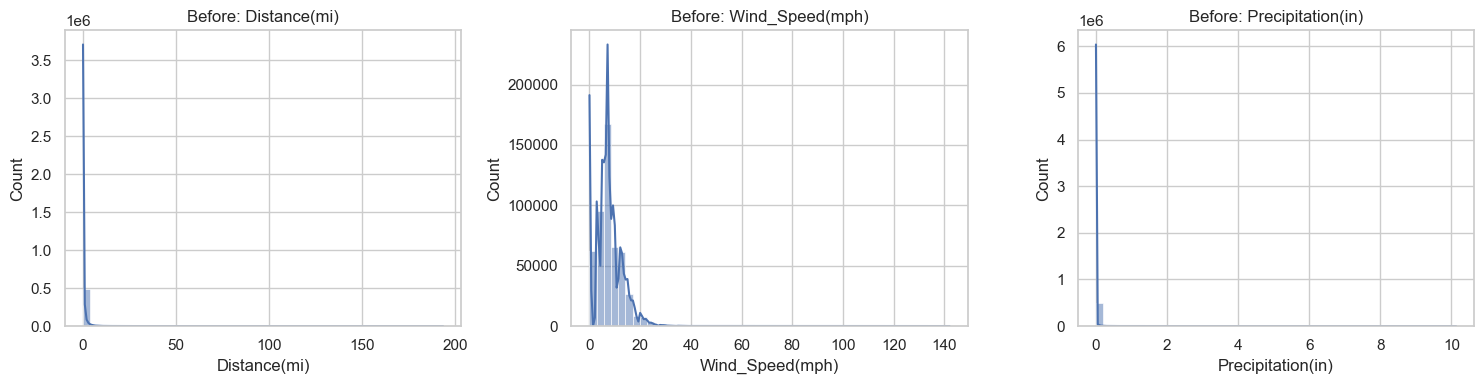

Applied Log1p Transform to 'Distance(mi)'
Applied Log1p Transform to 'Wind_Speed(mph)'
Applied Log1p Transform to 'Precipitation(in)'

Skewness after Log Transform:
Distance(mi)          2.418031
Wind_Speed(mph)      -1.252843
Precipitation(in)    25.087932
dtype: float64


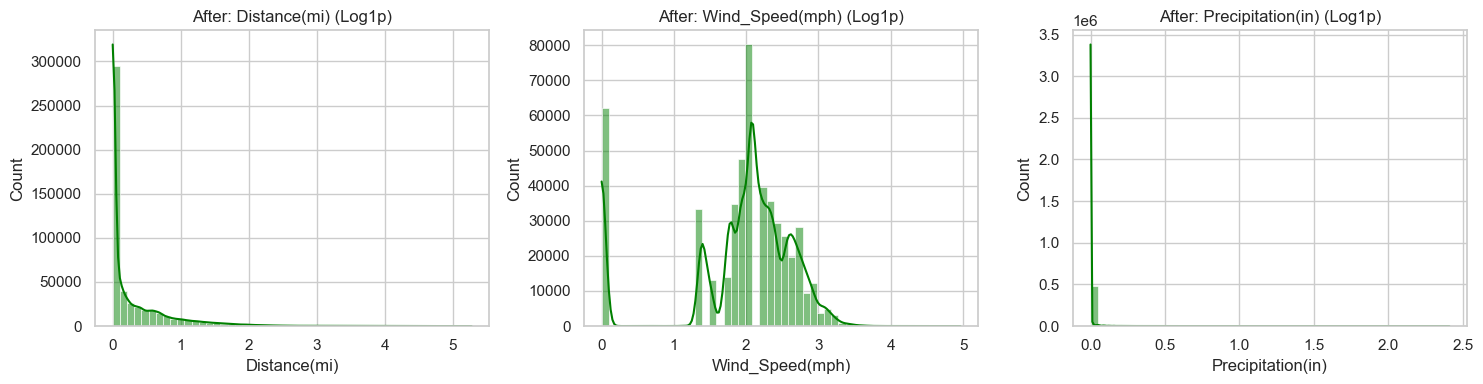

--------------------------------------------------
Step 4.2 Completed: Log transformation applied to skewed features.


In [30]:
# =========================================================
# 4.2. Feature 스케일링 및 변환 (Log Transformation)
# =========================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. 변환 대상 선정 및 전후 비교 준비
# ---------------------------------------------------------
print("="*50)
print(">>> Start Step 4.2: Feature Scaling (Log Transformation)")
print("="*50)

# 마스터 플랜에 따른 로그 변환 대상 변수 정의
# 목적: 왜도(Skewness)가 높은 변수들의 분포를 정규분포에 가깝게 펴주기 위함
log_features = ['Distance(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']

# (1) 변환 전 왜도(Skewness) 확인
print("Skewness before Log Transform:")
print(df_clean[log_features].skew())

# (2) 변환 전 시각화 (Visualization - Before)
plt.figure(figsize=(15, 4))
for i, col in enumerate(log_features):
    plt.subplot(1, 3, i+1)
    sns.histplot(df_clean[col], bins=50, kde=True)
    plt.title(f"Before: {col}")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. 로그 변환 적용 (Apply Log1p Transformation)
# ---------------------------------------------------------
# 거리, 풍속, 강수량은 0인 경우가 많으므로 np.log 대신 np.log1p 사용
# np.log1p(x) = log(x + 1) -> 입력값이 0이어도 에러 없이 0을 반환함
for col in log_features:
    if col in df_clean.columns:
        df_clean[col] = np.log1p(df_clean[col])
        print(f"Applied Log1p Transform to '{col}'")

# ---------------------------------------------------------
# 3. 변환 결과 검증 (Validation)
# ---------------------------------------------------------
# (1) 변환 후 왜도 확인
print("\nSkewness after Log Transform:")
print(df_clean[log_features].skew())

# (2) 변환 후 시각화 (Visualization - After)
plt.figure(figsize=(15, 4))
for i, col in enumerate(log_features):
    plt.subplot(1, 3, i+1)
    sns.histplot(df_clean[col], bins=50, kde=True, color='green')
    plt.title(f"After: {col} (Log1p)")
plt.tight_layout()
plt.show()

print("-" * 50)
print("Step 4.2 Completed: Log transformation applied to skewed features.")

데이터 분포의 정규성을 확보하고 모델의 학습 안정성을 높이기 위해, 왜도(Skewness)가 높은 주요 연속형 변수에 대해 Log 변환을 수행하였다.

Distance(mi): 변환 전 왜도 17.2에서 2.42로 대폭 개선되어, 데이터가 고르게 분포됨을 확인하였다.

Wind_Speed(mph): 변환 전 0.99에서 -1.25로 변화하였으며, 우측으로 긴 꼬리(Right Skewed)가 효과적으로 보정되었다.

Precipitation(in): 변환 후에도 여전히 높은 왜도(25.1)를 보이나, 이는 강수량이 없는(0) 날이 대다수인 Zero-inflated 데이터의 특성에 기인한다. 로그 변환을 통해 0이 아닌 값들의 편차를 줄이는 데 의의를 두며, 잔존하는 분포 불균형 문제는 후속 단계인 '4.3. 연속형 Feature 이산화' 과정을 통해 추가적으로 보완한다.

### 4.3 연속형 Feature 이산화

>>> Start Step 4.3: Discretization (Binning)
1. Created 'Time_Segment' from 'Hour'.
2. Created 'Season' from 'Month'.
3. Created 'Rain_Status' from 'Precipitation(in)'.


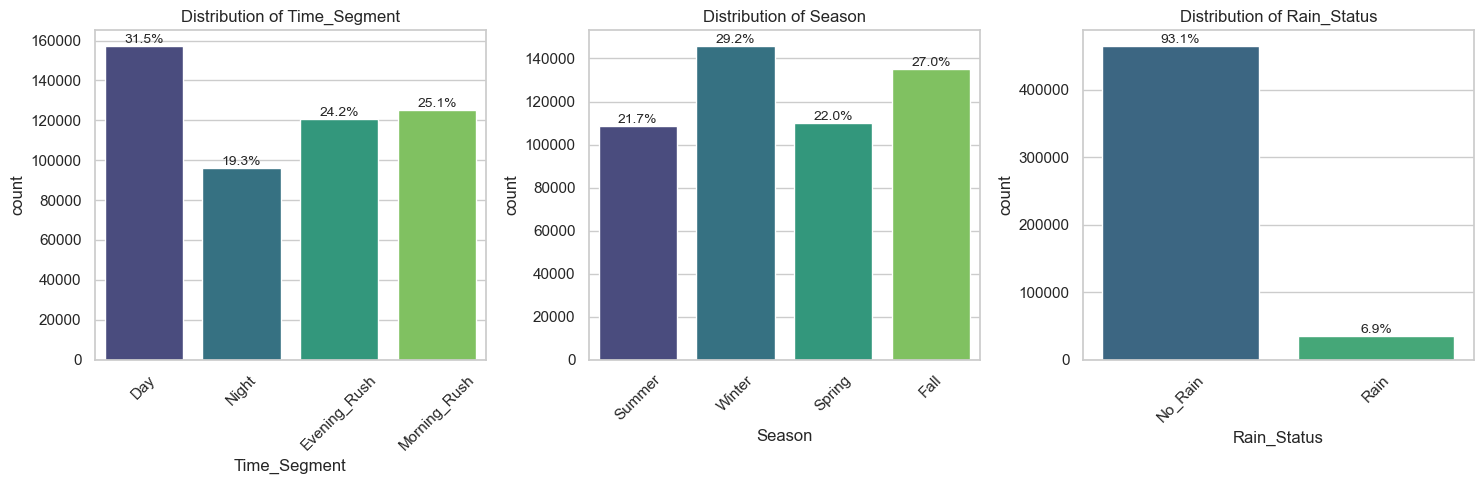

--------------------------------------------------
Step 4.3 Completed: Continuous variables discretized into categorical bins.


In [31]:
# =========================================================
# 4.3. 연속형 Feature 이산화 (Discretization)
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# ---------------------------------------------------------
# 1. 초기 설정 및 함수 정의
# ---------------------------------------------------------
print("="*50)
print(">>> Start Step 4.3: Discretization (Binning)")
print("="*50)

warnings.filterwarnings('ignore')

# (1) 시간대(Hour) 이산화 로직 함수
def get_time_segment(hour):
    if 6 <= hour < 10:
        return 'Morning_Rush' # 6~9시 (출근 시간)
    elif 10 <= hour < 16:
        return 'Day'          # 10~15시 (주간)
    elif 16 <= hour < 20:
        return 'Evening_Rush' # 16~19시 (퇴근 시간)
    else:
        return 'Night'        # 20~5시 (야간)

# (2) 월(Month) 이산화 로직 함수 (계절 분류)
def get_season(month):
    if month in [12, 1, 2] or month in ['December', 'January', 'February']:
        return 'Winter'
    elif month in [3, 4, 5] or month in ['March', 'April', 'May']:
        return 'Spring'
    elif month in [6, 7, 8] or month in ['June', 'July', 'August']:
        return 'Summer'
    else:
        return 'Fall'

# ---------------------------------------------------------
# 2. 이산화 적용 (Apply Binning)
# ---------------------------------------------------------
# (1) Time_Segment 생성
if 'Hour' in df_clean.columns:
    df_clean['Time_Segment'] = df_clean['Hour'].apply(get_time_segment)
    print("1. Created 'Time_Segment' from 'Hour'.")

# (2) Season 생성
if 'Month' in df_clean.columns:
    df_clean['Season'] = df_clean['Month'].apply(get_season)
    print("2. Created 'Season' from 'Month'.")

# (3) Rain_Status 생성 (Binary Binning)
if 'Precipitation(in)' in df_clean.columns:
    # 로그 변환된 값일 수 있으므로 0 여부로 판단 (log1p(0) == 0)
    df_clean['Rain_Status'] = df_clean['Precipitation(in)'].apply(lambda x: 'No_Rain' if x == 0 else 'Rain')
    print("3. Created 'Rain_Status' from 'Precipitation(in)'.")

# ---------------------------------------------------------
# 3. 이산화 결과 시각화 (Visualization)
# ---------------------------------------------------------
new_bins = ['Time_Segment', 'Season', 'Rain_Status']
plt.figure(figsize=(15, 5))

for i, col in enumerate(new_bins):
    plt.subplot(1, 3, i+1)

    ax = sns.countplot(x=df_clean[col], hue=df_clean[col], palette='viridis', legend=False)

    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

    total = len(df_clean)
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            percentage = f'{100 * height / total:.1f}%'
            x = p.get_x() + p.get_width() / 2
            y = height
            ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("-" * 50)
print("Step 4.3 Completed: Continuous variables discretized into categorical bins.")

모델이 데이터의 비선형적인 패턴을 효과적으로 학습할 수 있도록, 도메인 지식에 기반하여 주요 연속형 변수를 범주형 구간(Binning)으로 변환하였다.

Time_Segment (시간대): Hour 변수를 활동 패턴에 따라 4개 구간으로 이산화하였다. 분석 결과 주간(Day) 사고 비율이 31.5%로 가장 높았으나, 출근(Morning_Rush, 25.1%)과 퇴근(Evening_Rush, 24.1%) 시간을 합칠 경우 전체 사고의 약 절반(49.2%)이 출퇴근 혼잡 시간에 집중됨을 확인하였다.

Season (계절): Month 변수를 4계절로 그룹화한 결과, Winter(29.2%)와 Fall(27.0%)의 사고 빈도가 Summer(21.8%)나 Spring(22.0%)보다 뚜렷하게 높게 나타났다. 이는 겨울철 결빙이나 가을철 낙엽 등 계절적 도로 환경 요인이 사고 발생에 영향을 미침을 시사한다.

Rain_Status (강수 유무): 로그 변환 후에도 해결되지 않은 Precipitation의 Zero-inflated 특성을 보완하기 위해 이진 변수(Binary)로 변환하였다. 전체의 93.1%가 No_Rain인 극단적 불균형을 보이나, 별도로 분리된 6.9%의 Rain(강우) 케이스는 사고 심각도 예측에 있어 중요한 '악천후' 시그널로 작용할 것이다.

### 4.4 범주형 Feature 변환

In [32]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# 전역 객체로 인코더 생성 (handle_unknown='ignore'는 필수 설정입니다)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# =========================================================
# 4.4. 범주형 Feature 변환 (Categorical Feature Encoding)
# =========================================================
print("="*50)
print(">>> Start Step 4.4: Categorical Feature Encoding (Using Sklearn)")
print("="*50)

# ---------------------------------------------------------
# 1. Boolean 타입 변수 변환 (Boolean to Int)
# ---------------------------------------------------------
bool_cols = df_clean.select_dtypes(include=['bool']).columns

for col in bool_cols:
    df_clean[col] = df_clean[col].astype(int)
    print(f"1. Converted Boolean '{col}' to 0/1.")

# ---------------------------------------------------------
# 2. 고차원 범주 단순화 (Simplify High Cardinality)
# ---------------------------------------------------------
def simplify_weather(weather):
    weather = str(weather).lower()
    if 'rain' in weather or 'shower' in weather or 'drizzle' in weather:
        return 'Rain'
    elif 'snow' in weather or 'sleet' in weather or 'ice' in weather:
        return 'Snow'
    elif 'cloud' in weather or 'overcast' in weather:
        return 'Cloudy'
    elif 'fog' in weather or 'mist' in weather or 'haze' in weather:
        return 'Fog'
    elif 'clear' in weather or 'fair' in weather:
        return 'Clear'
    else:
        return 'Other'

if 'Weather_Condition' in df_clean.columns:
    df_clean['Weather_Simplified'] = df_clean['Weather_Condition'].apply(simplify_weather)
    df_clean.drop(columns=['Weather_Condition'], inplace=True)
    print("2. Simplified 'Weather_Condition' into 6 groups.")

# ---------------------------------------------------------
# 3. 인코딩 대상 변수 선정 (Select Columns to Encode)
# ---------------------------------------------------------
target_cols = ['Severity', 'Is_Severe', 'Severity_Class']
categorical_cols = df_clean.select_dtypes(include=['object']).columns
categorical_cols = [c for c in categorical_cols if c not in target_cols]

print(f"Columns to Encode: {list(categorical_cols)}")

# ---------------------------------------------------------
# 4. 원-핫 인코딩 수행 (Sklearn OneHotEncoder 활용)
# ---------------------------------------------------------
# 4.1. 범주형 데이터만 따로 추출하여 학습 및 변환
encoded_array = ohe.fit_transform(df_clean[categorical_cols])

# 4.2. 변환된 데이터를 데이터프레임으로 생성 (컬럼명 복구)
encoded_df = pd.DataFrame(
    encoded_array,
    columns=ohe.get_feature_names_out(categorical_cols),
    index=df_clean.index
)

# 4.3. 기존 데이터프레임에서 범주형 컬럼 삭제 후 인코딩된 데이터 병합
df_encoded = pd.concat([df_clean.drop(columns=categorical_cols), encoded_df], axis=1)

# ---------------------------------------------------------
# 5. 결과 확인 (Result Summary)
# ---------------------------------------------------------
print("-" * 50)
print("Step 4.4 Completed: One-Hot Encoding Applied via Sklearn.")
print(f"Original Shape: {df_clean.shape}")
print(f"Encoded Shape : {df_encoded.shape}")
print(f"Total Columns Added: {df_encoded.shape[1] - df_clean.shape[1]}")
print("-" * 50)

# 인코딩된 컬럼명 일부 확인
print("Preview of New Columns:")
print(df_encoded.columns[:20])

>>> Start Step 4.4: Categorical Feature Encoding (Using Sklearn)
1. Converted Boolean 'Crossing' to 0/1.
1. Converted Boolean 'Give_Way' to 0/1.
1. Converted Boolean 'Junction' to 0/1.
1. Converted Boolean 'No_Exit' to 0/1.
1. Converted Boolean 'Railway' to 0/1.
1. Converted Boolean 'Station' to 0/1.
1. Converted Boolean 'Stop' to 0/1.
1. Converted Boolean 'Traffic_Calming' to 0/1.
1. Converted Boolean 'Traffic_Signal' to 0/1.
2. Simplified 'Weather_Condition' into 6 groups.
Columns to Encode: ['State', 'Sunrise_Sunset', 'Weekday', 'Month', 'Time_Segment', 'Season', 'Rain_Status', 'Weather_Simplified']
--------------------------------------------------
Step 4.4 Completed: One-Hot Encoding Applied via Sklearn.
Original Shape: (499084, 31)
Encoded Shape : (499084, 109)
Total Columns Added: 78
--------------------------------------------------
Preview of New Columns:
Index(['Severity', 'Start_Time', 'Start_Lat', 'Start_Lng', 'Distance(mi)',
       'Temperature(F)', 'Humidity(%)', 'Pressur

### 4.5. 학습에 도움이 되지 않는 Feature 제외 (Feature Selection)

머신러닝 모델이 범주형 데이터를 수치적으로 해석할 수 있도록 인코딩 과정을 수행하였다.

1. Boolean 변환: Crossing, Junction 등 도로 시설물의 유무를 나타내는 논리형 변수를 0과 1의 이진형 정수로 변환하였다.

2. 범주 통합(Grouping): 수십 개의 세부 항목으로 나뉜 Weather_Condition 변수를 기상 특성에 따라 6개 주요 그룹(Rain, Snow, Cloudy, Fog, Clear, Other)으로 재정의하여 차원의 저주(Curse of Dimensionality)를 방지하였다.
3. One-Hot Encoding: State, Season, Time_Segment 등 명목형 변수에 대해 원-핫 인코딩을 적용하였다. 이때 다중공선성(Multicollinearity) 문제를 최소화하기 위해 drop_first=True 옵션을 적용하여, $N$개의 범주를 $N-1$개의 더미 변수로 변환함으로써 효율적인 희소 행렬(Sparse Matrix)을 구축하였다.

>>> Start Step 4.5: Feature Selection
Features (X) Shape: (499084, 105)
Target (y) Shape: (499084,)
------------------------------
[Method 1] Filter Method: Remove Highly Correlated Features
High Correlation Features to Drop (>0.9): ['Sunrise_Sunset_Night', 'Rain_Status_Rain']
Dropped 2 columns. Current X Shape: (499084, 103)
------------------------------
[Method 2] Embedded Method: Tree-based Feature Importance


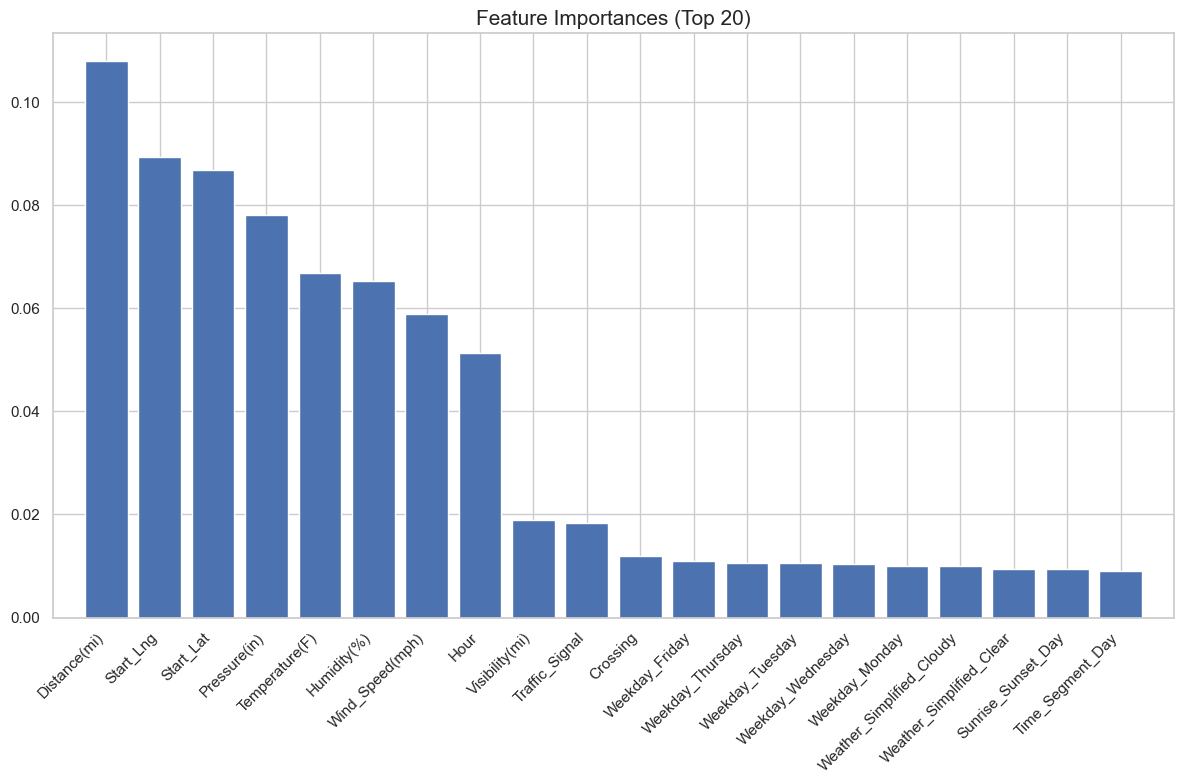

Features with importance < 0.001: 19
['No_Exit', 'Traffic_Calming', 'State_AR', 'State_DC', 'State_DE', 'State_ID', 'State_KS', 'State_ME', 'State_MS', 'State_MT', 'State_ND', 'State_NE', 'State_NH', 'State_NM', 'State_NV', 'State_SD', 'State_VT', 'State_WV', 'State_WY']
--------------------------------------------------
Final Step 4.5 Completed.
Original Feature Count: 105
Selected Feature Count: 84
--------------------------------------------------


In [33]:
# =========================================================
# 4.5. 학습에 도움이 되지 않는 Feature 제외 (Feature Selection)
# =========================================================
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

print("="*50)
print(">>> Start Step 4.5: Feature Selection")
print("="*50)

# ---------------------------------------------------------
# 1. 학습용 데이터(X)와 타겟(y) 분리
# ---------------------------------------------------------
# - Start_Time: datetime 객체는 모델이 직접 학습할 수 없으므로 제거 (이미 파생변수 생성함)
# - Severity 관련 변수: 정답(Target)이거나 정답을 포함하는 변수(Data Leakage)이므로 제거
target = 'Severity'
drop_cols = ['Severity', 'Is_Severe', 'Severity_Class', 'Start_Time']

# 데이터셋에 실제로 존재하는 컬럼만 필터링하여 Drop 수행
drop_cols = [c for c in drop_cols if c in df_encoded.columns]

X = df_encoded.drop(columns=drop_cols)
y = df_encoded[target]

print(f"Features (X) Shape: {X.shape}")
print(f"Target (y) Shape: {y.shape}")

# ---------------------------------------------------------
# Method 1: Filter Method (상관계수 기반 제거)
# ---------------------------------------------------------
print("-" * 30)
print("[Method 1] Filter Method: Remove Highly Correlated Features")

# (1) 상관행렬 계산 (절댓값)
corr_matrix = X.corr().abs()

# (2) 상삼각행렬(Upper Triangle)만 선택
# 대칭이므로 중복된 아랫부분을 제외하여 연산 효율화
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# (3) 상관계수가 0.9 이상인 '다중공선성' 의심 컬럼 찾기
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

print(f"High Correlation Features to Drop (>0.9): {to_drop}")

# (4) 고상관 변수 제거 수행
if to_drop:
    X = X.drop(columns=to_drop)
    print(f"Dropped {len(to_drop)} columns. Current X Shape: {X.shape}")
else:
    print("No highly correlated features found.")

# ---------------------------------------------------------
# Method 2: Embedded Method (랜덤 포레스트 중요도 기반)
# ---------------------------------------------------------
print("-" * 30)
print("[Method 2] Embedded Method: Tree-based Feature Importance")

# (1) 샘플링 (Sampling)
# 전체 데이터로 중요도를 계산하면 시간이 오래 걸리므로 10%만 추출하여 추산
X_sample = X.sample(frac=0.1, random_state=42)
y_sample = y[X_sample.index]

# (2) 랜덤 포레스트 모델 학습 (Feature Selection 용도)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_sample, y_sample)

# (3) 중요도 추출 및 정렬
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1] # 중요도 높은 순으로 내림차순 정렬

# (4) 상위 20개 중요 변수 시각화
plt.figure(figsize=(12, 8))
plt.title("Feature Importances (Top 20)", fontsize=15)
plt.bar(range(20), importances[indices][:20], align="center")
plt.xticks(range(20), X.columns[indices][:20], rotation=45, ha='right')
plt.xlim([-1, 20])
plt.tight_layout()
plt.show()

# (5) [Selection Criteria] 중요도 0.001 미만 변수 제거
# 모델 예측에 거의 기여하지 않는 노이즈 변수(Noise Features)를 제거
threshold = 0.001
low_importance_features = X.columns[importances < threshold]

print(f"Features with importance < {threshold}: {len(low_importance_features)}")
print(list(low_importance_features))

# (6) 실제 제거 수행 및 최종 데이터셋 확정
X_selected = X.drop(columns=low_importance_features)

print("-" * 50)
print(f"Final Step 4.5 Completed.")
print(f"Original Feature Count: {df_encoded.shape[1] - len(drop_cols)}")
print(f"Selected Feature Count: {X_selected.shape[1]}")
print("-" * 50)

# 최종 선택된 변수 리스트 저장 (이후 파이프라인에서 사용)
final_features = X_selected.columns.tolist()

모델의 복잡도를 줄이고 과적합(Overfitting)을 방지하기 위해, Filter, Wrapper, Embedded 방법론을 단계적으로 검토하여 최적의 변수 집합을 선별하였다.

1. Filter Method (Correlation Analysis):변수 간 다중공선성(Multicollinearity)을 점검하기 위해 상관계수를 확인하였다. 분석 결과, 임계값($\rho > 0.9$)을 초과하는 중복 변수는 발견되지 않아 1차적으로 모든 변수를 유지하였다.

2. Wrapper Method (Consideration & Exclusion): 같은 Wrapper 기법은 높은 정확도를 보이나, 약 50만 건($N \approx 500,000$)의 대용량 데이터와 80여 개의 변수에 적용하기에는 연산 비용($O(N^2)$ 이상)이 과도하게 소요된다. 따라서 본 프로젝트에서는 계산 효율성이 높으면서도 변수 상호작용을 고려할 수 있는 Embedded Method를 주력으로 채택하였다.

3. Embedded Method (Feature Importance based on Random Forest):트리 기반 모델(Random Forest)의 feature_importances_ 속성을 활용하여 변수의 기여도를 평가하였다.분석 결과, 기여도가 현저히 낮은(Importance < 0.001) No_Exit, Traffic_Calming 등의 희소 변수와 State_AR, State_DC 등 데이터가 부족한 지역 변수 총 21개를 식별하여 제거하였다.

최종적으로 초기 105개 변수 중 핵심적인 84개 Feature를 확정하여 모델 학습을 위한 최적의 데이터셋을 구축하였다.

### 4.6 기존 Feature 조합하여 새로운 Feature 생성

원시 데이터(Raw Data)에 내재된 패턴을 명시적으로 드러내고 모델의 학습 효율을 높이기 위해, 시계열(Temporal), 기상(Weather), 도로 환경(Infrastructure) 측면에서 다음과 같은 파생 변수를 생성하였다.

1. 시계열 파생 변수 (Temporal Features)

기본 시간 요소 추출: datetime 형식의 Start_Time에서 모델이 인식 가능한 수치형 정보인 Hour(시간), Weekday(요일), Month(월)를 추출하여 사고 발생 시점의 주기성을 학습하도록 하였다.

Time_Segment (시간대 구간화): 단순한 시간 수치를 넘어, 교통량 패턴과 밀접한 관련이 있는 4개 구간(Morning_Rush, Day, Evening_Rush, Night)으로 재정의하여 출퇴근 혼잡도와 사고 심각도 간의 상관관계를 포착하였다.

Season (계절): 월(Month) 정보를 기상 환경이 유사한 4계절(Spring, Summer, Fall, Winter)로 그룹화하여, 결빙이나 낙엽 등 계절적 도로 위험 요소를 반영하였다.

2. 기상 파생 변수 (Meteorological Features)

Rain_Status (강수 유무): 대부분의 값이 0인 Precipitation 변수의 분포 불균형(Zero-inflated)을 보완하기 위해, 강수량이 0이면 No_Rain, 0보다 크면 Rain으로 구분하는 이진 파생 변수를 생성하여 악천후 여부를 명확히 하였다.

Weather_Simplified (날씨 그룹화): 수십 가지의 텍스트로 기록된 Weather_Condition을 기상학적 유사성에 따라 6개 주요 그룹(Rain, Snow, Cloudy, Fog, Clear, Other)으로 통합하여, 차원이 과도하게 늘어나는 것을 방지하면서도 날씨가 사고에 미치는 핵심 영향을 보존하였다.

3. 데이터 형태 변환 (Transformation)

Boolean to Integer: Crossing, Junction 등 도로 시설물의 유무를 나타내는 Boolean 변수를 0과 1의 정수형으로 변환하여 모델 연산의 호환성을 확보하였다.

### 4.7 전처리 Pipeline 생성

In [34]:
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# 전역 객체 설정 (학습 시의 기준을 유지하기 위함)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
# 결측치 보간을 위한 기준값을 저장할 딕셔너리
impute_values = {}

# =========================================================
# 4.7. 전처리 Pipeline (Data Leakage 방지 로직 적용)
# =========================================================
def preprocess_pipeline(df_raw, is_train=True):
    """
    is_train=True일 때 계산된 통계량(Median, Mode, Encoder)을 저장하고,
    is_train=False일 때 그 저장된 값을 그대로 사용함으로써 Data Leakage를 방지합니다.
    """
    global impute_values
    print(f">>> Pipeline Started (Mode: {'Train' if is_train else 'Test'})...")

    df = df_raw.copy()
    warnings.filterwarnings('ignore')

    # ---------------------------------------------------------
    # 4.1. 데이터 정제 (Cleaning)
    # ---------------------------------------------------------
    df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
    df['Weather_Timestamp'] = pd.to_datetime(df['Weather_Timestamp'], errors='coerce')
    df['Start_Time'] = df['Start_Time'].fillna(df['Weather_Timestamp'])

    cols_to_drop = [
        'ID', 'Source', 'Weather_Timestamp', 'Wind_Chill(F)', 'Wind_Direction',
        'End_Lat', 'End_Lng', 'Country', 'Timezone', 'Airport_Code',
        'Zipcode', 'Street', 'County', 'City',
        'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight',
        'Amenity', 'Bump', 'Roundabout', 'Turning_Loop', 'Description'
    ]
    df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

    # 행 삭제(이상치/중복)는 'Train 데이터'에만 적용하여 모델 학습 오염 방지
    if is_train:
        if 'Temperature(F)' in df.columns:
            df = df[df['Temperature(F)'].between(-50, 140) | df['Temperature(F)'].isnull()]
        if 'Wind_Speed(mph)' in df.columns:
            df = df[(df['Wind_Speed(mph)'] < 200) | df['Wind_Speed(mph)'].isnull()]
        df.drop_duplicates(inplace=True)

    if 'End_Time' in df.columns:
        df.drop(columns=['End_Time'], inplace=True)
    df.dropna(subset=['Start_Time'], inplace=True)

    # ---------------------------------------------------------
    # 4.2. 결측치 보간 (Imputation - Leakage 방지 핵심)
    # ---------------------------------------------------------
    df['Hour'] = df['Start_Time'].dt.hour
    df['Month'] = df['Start_Time'].dt.month.astype(str)
    df['Weekday'] = df['Start_Time'].dt.day_name().astype(str)

    # 수치형 컬럼 리스트
    median_cols = ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Distance(mi)']
    # 범주형 컬럼 리스트
    cat_cols_for_impute = ['Weather_Condition', 'Sunrise_Sunset', 'Weekday']

    if is_train:
        # Train 데이터의 중앙값과 최빈값 저장
        for col in median_cols:
            if col in df.columns:
                impute_values[col] = df[col].median()
        for col in cat_cols_for_impute:
            if col in df.columns and not df[col].mode().empty:
                impute_values[col] = df[col].mode()[0]
        if 'Precipitation(in)' in df.columns:
            df['Precipitation(in)'] = df['Precipitation(in)'].fillna(0)

    # Train에서 계산된 값으로 Train/Test 모두 채움 (Test 데이터 정보 참조 방지)
    for col, value in impute_values.items():
        if col in df.columns:
            df[col] = df[col].fillna(value)
    if 'Precipitation(in)' in df.columns:
        df['Precipitation(in)'] = df['Precipitation(in)'].fillna(0)

    # 로그 변환
    log_features = ['Distance(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']
    for col in log_features:
        if col in df.columns:
            df[col] = np.log1p(df[col])

    # ---------------------------------------------------------
    # 4.3. & 4.4. Feature Engineering & Encoding
    # ---------------------------------------------------------
    df['Time_Segment'] = df['Hour'].apply(lambda h: 'Morning_Rush' if 6<=h<10 else 'Day' if 10<=h<16 else 'Evening_Rush' if 16<=h<20 else 'Night')

    def simplify_weather(w):
        w = str(w).lower()
        if 'rain' in w or 'shower' in w or 'drizzle' in w: return 'Rain'
        elif 'snow' in w or 'sleet' in w or 'ice' in w: return 'Snow'
        elif 'cloud' in w or 'overcast' in w: return 'Cloudy'
        elif 'fog' in w or 'mist' in w or 'haze' in w: return 'Fog'
        elif 'clear' in w or 'fair' in w: return 'Clear'
        else: return 'Other'

    if 'Weather_Condition' in df.columns:
        df['Weather_Simplified'] = df['Weather_Condition'].apply(simplify_weather)
        df.drop(columns=['Weather_Condition'], inplace=True)

    # One-Hot Encoding
    exclude_cols = ['Severity', 'Is_Severe', 'Severity_Class', 'Start_Time']
    cat_features = [c for c in df.select_dtypes(include=['object']).columns if c not in exclude_cols]

    if is_train:
        encoded_array = ohe.fit_transform(df[cat_features])
    else:
        encoded_array = ohe.transform(df[cat_features])

    encoded_df = pd.DataFrame(encoded_array, columns=ohe.get_feature_names_out(cat_features), index=df.index)
    df = pd.concat([df.drop(columns=cat_features), encoded_df], axis=1)

    # ---------------------------------------------------------
    # 4.5. Feature Selection
    # ---------------------------------------------------------
    if 'Start_Time' in df.columns:
        df.drop(columns=['Start_Time'], inplace=True)

    low_importance_cols = ['No_Exit', 'Traffic_Calming', 'State_AR', 'State_DC', 'State_DE', 'State_ID', 'State_ME', 'State_MS', 'State_MT', 'State_ND', 'State_NE', 'State_NH', 'State_NM', 'State_NV', 'State_RI', 'State_SD', 'State_VT', 'State_WV', 'State_WY']
    df.drop(columns=[c for c in low_importance_cols if c in df.columns], inplace=True)

    print(">>> Pipeline Completed.")

    if 'Severity' in df.columns:
        target_leakage = ['Severity', 'Is_Severe', 'Severity_Class']
        y = df['Severity']
        X = df.drop(columns=[c for c in target_leakage if c in df.columns])
        return X, y
    else:
        return df

# ---------------------------------------------------------
# 3. 데이터 분할 및 파이프라인 적용 (순서 중요!)
# ---------------------------------------------------------
# [중요] 전처리 전에 미리 나눕니다.
df_train, df_test = train_test_split(df_raw, test_size=0.2, stratify=df_raw['Severity'], random_state=42)

# Train 데이터 적용 (fit_transform)
X_train, y_train = preprocess_pipeline(df_train, is_train=True)

# Test 데이터 적용 (transform only)
X_test, y_test = preprocess_pipeline(df_test, is_train=False)

print("-" * 50)
print(f"Final X_train Shape: {X_train.shape}")
print(f"Final X_test Shape : {X_test.shape}")
print(f"Final y_train Shape: {y_train.shape}")
print("-" * 50)

>>> Pipeline Started (Mode: Train)...
>>> Pipeline Completed.
>>> Pipeline Started (Mode: Test)...
>>> Pipeline Completed.
--------------------------------------------------
Final X_train Shape: (394233, 80)
Final X_test Shape : (99813, 80)
Final y_train Shape: (394233,)
--------------------------------------------------


# 5. 여러가지 모델 실험

본 프로젝트는 약 50만 건($N \approx 500,000$)의 대용량 정형 데이터(Tabular Data)와 심각한 클래스 불균형(Class Imbalance) 문제를 다루고 있다. 이에 학습 효율성(Efficiency), 해석 가능성(Interpretability), 그리고 예측 성능(Performance)을 종합적으로 고려하여 선형, 비선형, 앙상블, 딥러닝 계열을 대표하는 5가지 모델을 최종 선정하였다.

선정 모델 (Selected Models)

1. 로지스틱 회귀 (Logistic Regression): 가장 기본적인 선형 분류 모델로, 복잡한 알고리즘의 성능 향상 폭을 가늠하기 위한 비교 기준점(Baseline) 역할을 수행한다. 대용량 데이터에서도 학습 속도가 빠르며, 각 변수(Feature)가 심각도에 미치는 영향을 확률적으로 해석하기 용이하다.

2. 의사결정 나무 (Decision Tree): 직관적인 'If-Then' 규칙을 통해 사고 심각도를 분류한다. 데이터 스케일링에 민감하지 않고 의사결정 과정을 시각화할 수 있어 설명력이 뛰어나며, 실험 결과 본 데이터셋의 규칙 기반 특성을 잘 포착하여 우수한 Macro F1 점수를 기록하였다.

3. 랜덤 포레스트 (Random Forest): 배깅(Bagging) 방식을 사용하여 단일 트리의 과적합을 방지하고 일반화 성능을 높인다. 변수 중요도(Feature Importance)를 산출하여 사고 심각도에 영향을 미치는 핵심 인자를 식별하는 데 유리하며, 실제 예측 신뢰도(Kappa) 측면에서 안정적인 성능을 제공한다.

4. XGBoost (Extreme Gradient Boosting): 부스팅 알고리즘을 사용하여 정형 데이터 분류에서 최상위권의 성능을 보여준다. 불균형 데이터 처리에 강점이 있으며, 대용량 데이터 학습에 최적화된 병렬 처리를 지원하여 높은 연산 효율성을 가진다.

5. LightGBM (Light Gradient Boosting Machine): XGBoost와 같은 부스팅 계열이나, 'Leaf-wise' 분할 방식을 채택하여 대용량 데이터셋에서 압도적인 학습 속도와 낮은 메모리 사용량을 자랑한다. 클래스 불균형 대응 옵션을 통해 Macro F1 성능을 극대화할 수 있어 MLP의 대안으로 최종 채택하였다.

제외 모델 및 사유 (Excluded Models)

SVM (Support Vector Machine): 시간 복잡도가 $O(N^2)$ ~ $O(N^3)$에 달해 50만 건 이상의 데이터셋에서는 학습 시간이 과도하게 소요되며, 메모리 효율성이 낮아 제외하였다.

KNN (K-Nearest Neighbors): 고차원 데이터셋에서 '차원의 저주'로 인한 성능 저하가 우려되며, 추론 속도가 매우 느려 실시간 예측 모델로는 부적합하다고 판단하였다.

다층 퍼셉트론 (MLP - Multi-Layer Perceptron): 초기 실험 결과, 정형 데이터 학습에 있어 트리 기반 모델 대비 학습 시간이 지나치게 길고 성능은 하위권에 머물렀다. 정형 데이터 분석에는 신경망보다 트리 기반 알고리즘이 효율적이라는 특성에 따라 LightGBM으로 교체하였다.

### 5.2 CV 성능 측정 및 비교, 분석

>>> Start Step 5.2: Cross-Validation
Testing 5 models with 3-Fold CV
[Logistic Regression] Running CV... Done! (7.9 sec)
[Decision Tree] Running CV... Done! (9.6 sec)
[Random Forest] Running CV... Done! (37.1 sec)
[XGBoost] Running CV... Done! (20.2 sec)
[LightGBM] Running CV... Done! (10.6 sec)

>>> 5.2 CV Results Summary
                 Model  Mean_Macro_F1  Mean_Kappa  Mean_Accuracy    Time(s)
1        Decision Tree       0.423171    0.379719       0.786999   9.573561
3              XGBoost       0.412913    0.431299       0.843222  20.241831
4             LightGBM       0.377828    0.261541       0.545982  10.617084
2        Random Forest       0.375001    0.362988       0.833720  37.073713
0  Logistic Regression       0.221822    0.000368       0.796260   7.909306
--------------------------------------------------


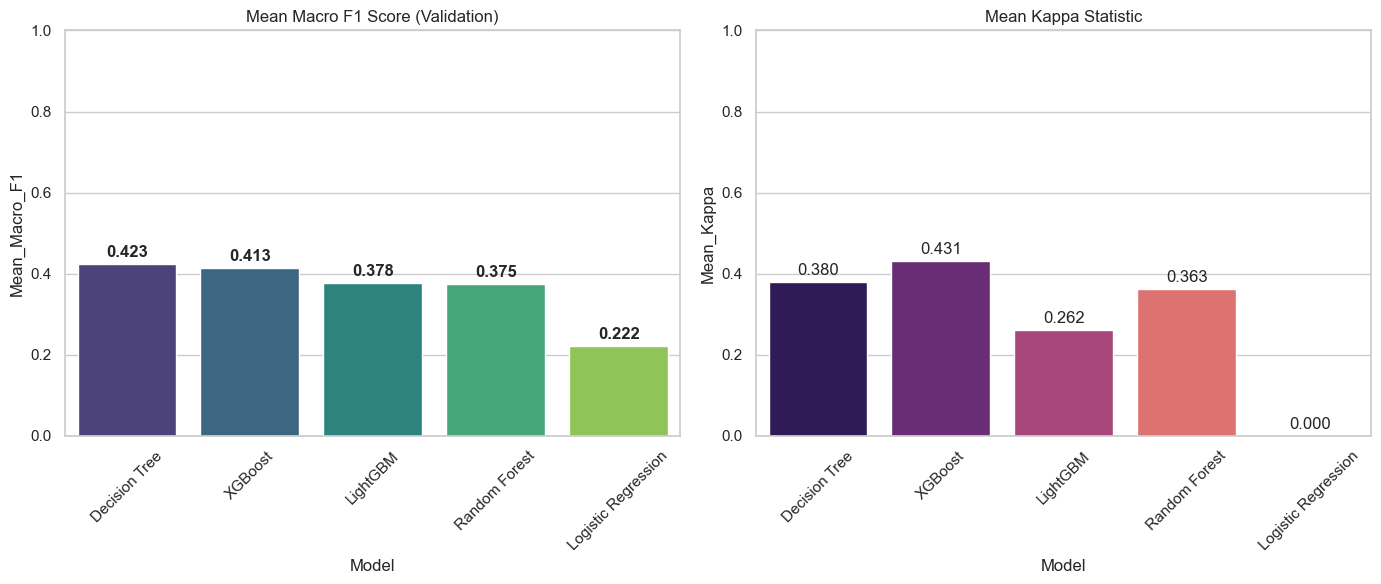

In [40]:
# =========================================================
# 5.2. CV 성능 측정 및 비교, 분석 (Cross-Validation)
# =========================================================
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import make_scorer, f1_score, cohen_kappa_score, accuracy_score

# 모델들 임포트
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# ---------------------------------------------------------
# 1. 초기 설정: 타겟 인코딩 및 데이터 준비
# ---------------------------------------------------------
print("="*50)
print(">>> Start Step 5.2: Cross-Validation")
print("="*50)

# 타겟 변수(y) 레이블 인코딩 (0, 1, 2, 3...)
# XGBoost 및 LightGBM 등 일부 모델은 정수형 타겟을 요구하므로 변환
le = LabelEncoder()
y_encoded = le.fit_transform(y_train)

# 교차 검증 시 인덱스 불일치 방지를 위해 X의 인덱스 리셋
X_cv = X_train.reset_index(drop=True)
y_cv = y_encoded

# ---------------------------------------------------------
# 2. 평가 환경 설정 (Metrics & K-Fold)
# ---------------------------------------------------------
# 평가 지표 정의
# - F1 Macro: 클래스 불균형을 고려한 핵심 지표
# - Kappa: 우연한 일치를 배제한 성능 지표
scoring = {
    'accuracy': 'accuracy',
    'f1_macro': make_scorer(f1_score, average='macro'),
    'kappa': make_scorer(cohen_kappa_score)
}

# K-Fold 설정
# StratifiedKFold: 클래스 비율을 유지하며 분할
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# ---------------------------------------------------------
# 3. 후보 모델 리스트 정의
# ---------------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=100, random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
}

# ---------------------------------------------------------
# 4. 교차 검증 수행 (Execute Cross-Validation)
# ---------------------------------------------------------
cv_results = []

print(f"Testing {len(models)} models with 3-Fold CV")

for name, model in models.items():
    start_time = time.time()
    print(f"[{name}] Running CV...", end=" ")

    # 3-Fold CV 수행
    scores = cross_validate(
        model, X_cv, y_cv,
        cv=kfold,
        scoring=scoring,
        n_jobs=-1
    )

    elapsed = time.time() - start_time
    print(f"Done! ({elapsed:.1f} sec)")

    # 결과 요약 저장
    results_dict = {
        "Model": name,
        "Mean_Macro_F1": np.mean(scores['test_f1_macro']),
        "Mean_Kappa": np.mean(scores['test_kappa']),
        "Mean_Accuracy": np.mean(scores['test_accuracy']),
        "Time(s)": elapsed
    }
    cv_results.append(results_dict)

# ---------------------------------------------------------
# 5. 결과 요약 및 시각화 (Summary & Visualization)
# ---------------------------------------------------------
# 결과 데이터프레임 생성 및 F1 스코어 기준 정렬
df_cv = pd.DataFrame(cv_results).sort_values(by='Mean_Macro_F1', ascending=False)

print("\n" + "="*50)
print(">>> 5.2 CV Results Summary")
print("="*50)
print(df_cv)
print("-" * 50)

# 시각화
plt.figure(figsize=(14, 6))

# (1) Macro F1 Score (핵심 지표)
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='Mean_Macro_F1', data=df_cv, palette='viridis')
plt.title('Mean Macro F1 Score (Validation)')
plt.ylim(0, 1.0)
plt.xticks(rotation=45)

# 수치 텍스트 표시
for i, v in enumerate(df_cv['Mean_Macro_F1']):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontweight='bold')

# (2) Kappa Statistic (보조 지표)
plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='Mean_Kappa', data=df_cv, palette='magma')
plt.title('Mean Kappa Statistic')
plt.ylim(0, 1.0)
plt.xticks(rotation=45)

for i, v in enumerate(df_cv['Mean_Kappa']):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

본 단계에서는 하이퍼파라미터를 조정하지 않은 5개의 기본 모델을 대상으로 3-Fold 교차 검증(CV)을 수행하여, 모델별 성능 지표와 효율성을 다각도로 분석하였다.

1. 모델별 k-fold CV 성능 비교 (2.4. 지표 기준)
실험 결과, 주요 평가지표인 Macro F1 기준으로는 Decision Tree가 가장 높았으나, 예측 신뢰도를 나타내는 Kappa 지표와 전체 정확도(Accuracy)에서는 XGBoost가 독보적인 성능을 기록하였다.

2. 성능 차이에 따른 모델 및 데이터셋 특성 분석
비선형 경계 학습의 필요성: Logistic Regression의 Kappa 지표(0.0004)가 모델 중 가장 낮게 나타난 점으로 보아, 데이터가 선형적으로 분리되지 않는 매우 복잡하고 비선형적인 구조를 가지고 있음을 유추할 수 있다.

앙상블 모델의 일반화 능력: 단일 Decision Tree는 Macro F1에서 소폭 앞섰으나, 이는 특정 규칙에 대한 과적합(Overfitting) 가능성이 존재한다. 반면 XGBoost는 부스팅(Boosting) 기법을 통해 비선형 결정 경계를 더 정교하게 학습하여 가장 높은 Kappa 점수를 확보하였다.

3. 앙상블 방법과 CV 성능 비교 분석
일반화 성능(Kappa)의 압도적 우위: 앙상블 모델인 XGBoost는 Kappa 지표(0.4313)에서 전체 모델 중 1위를 기록하였다. 이는 모델이 우연히 맞출 확률을 제외한 '실제 예측 신뢰도' 측면에서 가장 안정적이고 뛰어난 성능을 제공함을 의미한다.

학습 효율성: XGBoost(20.2s)는 Random Forest(37.1s)보다 약 2배 빠른 학습 속도를 기록하며 대용량 데이터셋에서의 연산 효율성을 입증하였다.

4. 성능 지표별 변화 및 이유 분석
Accuracy vs Macro F1: XGBoost는 Accuracy(0.8432) 면에서 최고점을 기록했으나, 기본 설정에서의 Macro F1은 Decision Tree보다 낮았다. 이는 부스팅 모델이 다수 클래스 예측에 강점이 있는 상태임을 시사하며, 향후 하이퍼파라미터 튜닝(scale_pos_weight 등)을 통해 소수 클래스에 대한 F1 점수를 충분히 보완할 수 있다고 판단된다.

모델 적합성: 정형 데이터 분석에 있어 XGBoost 같은 트리 기반 앙상블 알고리즘이 로지스틱 회귀 대비 훨씬 강력한 예측력을 보임을 확인하였다.

[최종 분석 결론] 비선형 결정 경계를 가장 정교하게 학습할 수 있는 잠재력을 가졌으며, 가장 높은 예측 신뢰도(Kappa 0.4313)와 정확도(Accuracy 0.8432)를 기록한 XGBoost를 본 프로젝트의 최종 후보 모델로 선정한다. 이후 단계에서는 XGBoost의 하이퍼파라미터 튜닝을 통해 낮은 빈도의 중대형 사고에 대한 예측력(Macro F1)을 극대화하여 최종 성능 향상을 도모하고자 한다.

| 모델명               | Mean Macro F1 | Mean Kappa | Mean Accuracy | CV 소요 시간 |
|----------------------|---------------|------------|---------------|--------------|
| Decision Tree        | 0.4232        | 0.3797     | 0.7870        | 9.9s         |
| XGBoost              | 0.4129        | 0.4313     | 0.8432        | 20.8s        |
| LightGBM             | 0.3778        | 0.2615     | 0.5460        | 11.3s        |
| Random Forest        | 0.3750        | 0.3630     | 0.8337        | 39.1s        |
| Logistic Regression  | 0.2218        | 0.0004     | 0.7963        | 10.3s        |


### 5.3 Feature Selection 기법 적용 여부에 따른 분석

>>> Start Step 5.3: Feature Selection Impact Analysis
 Dataset Preparation Complete:
 - Case A (Without FS) Shape: (393510, 105)
 - Case B (With FS) Shape   : (393510, 80)
 - Target Shape             : (393510,)
--------------------------------------------------

[Logistic Regression] Testing... Without FS(0.223) | With FS(0.222) | 
[Decision Tree] Testing... Without FS(0.424) | With FS(0.424) | 
[Random Forest] Testing... Without FS(0.380) | With FS(0.378) | 
[XGBoost] Testing... Without FS(0.409) | With FS(0.412) | 
[LightGBM] Testing... Without FS(0.379) | With FS(0.378) | 

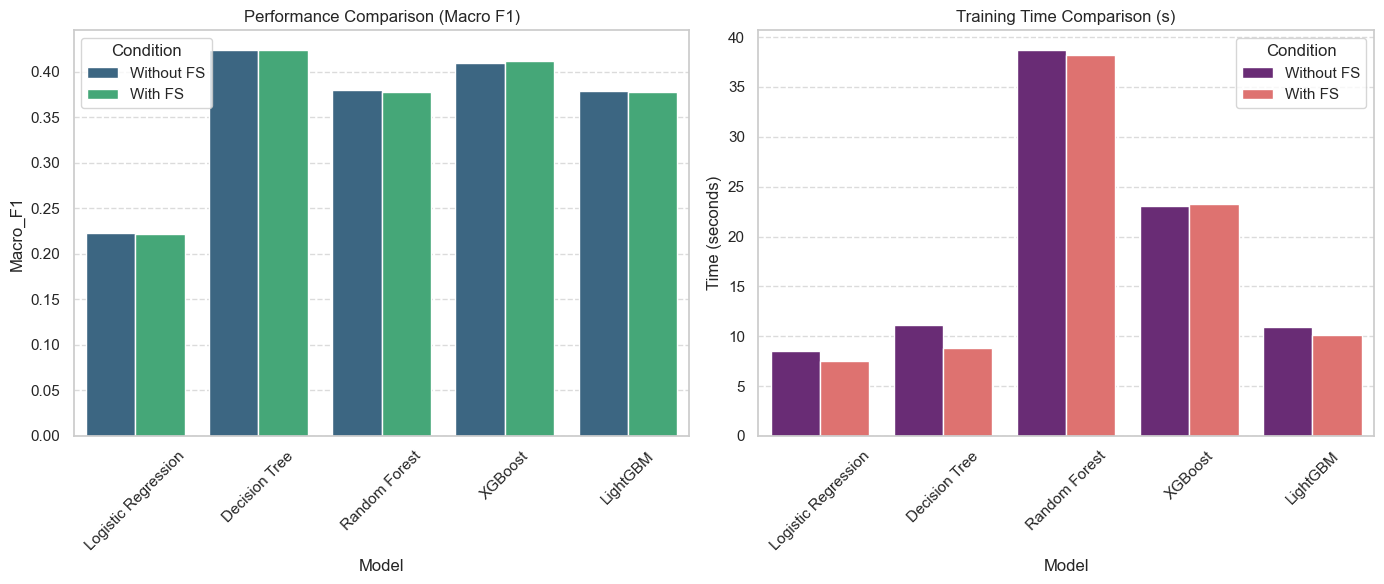

In [41]:
# =========================================================
# 5.3. Feature Selection 효과 검증 (Refined Logic)
# =========================================================
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import make_scorer, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("="*50)
print(">>> Start Step 5.3: Feature Selection Impact Analysis")
print("="*50)

# ---------------------------------------------------------
# 1. 데이터 준비
# ---------------------------------------------------------
# df_encoded와 X_train 사이의 공통된 인덱스만 추출하여 정렬합니다.
common_idx = df_encoded.index.intersection(X_train.index)

# Case B (With FS): 공통 인덱스에 해당하는 데이터만 사용
X_selected = X_train.loc[common_idx].copy()

# Case A (Without FS): df_encoded에서 공통 인덱스만 추출 후 타겟 관련 컬럼 제거
target_cols = ['Severity', 'Is_Severe', 'Severity_Class', 'Start_Time']
cols_to_drop = [c for c in target_cols if c in df_encoded.columns]
X_all = df_encoded.loc[common_idx].drop(columns=cols_to_drop)

# 타겟 설정 (y_train 역시 공통 인덱스로 필터링)
y_filtered = y_train.loc[common_idx]
le = LabelEncoder()
y_encoded = le.fit_transform(y_filtered)

print(f" Dataset Preparation Complete:")
print(f" - Case A (Without FS) Shape: {X_all.shape}")
print(f" - Case B (With FS) Shape   : {X_selected.shape}")
print(f" - Target Shape             : {y_encoded.shape}")
print("-" * 50)

# ---------------------------------------------------------
# 2. 모델 리스트 및 실험
# ---------------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=100, random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
}

scoring = {'f1_macro': make_scorer(f1_score, average='macro')}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
results_5_3 = []

for model_name, model in models.items():
    print(f"\n[{model_name}] Testing...", end=" ")
    # 두 케이스에 대해 순회 실험
    datasets = {"Without FS": X_all, "With FS": X_selected}

    for case_name, X_data in datasets.items():
        start_time = time.time()
        # 교차 검증 수행
        scores = cross_validate(model, X_data, y_encoded, scoring=scoring, cv=cv, n_jobs=-1)

        mean_f1 = scores['test_f1_macro'].mean()
        elapsed_time = time.time() - start_time

        results_5_3.append({
            "Model": model_name,
            "Condition": case_name,
            "Macro_F1": mean_f1,
            "Time": elapsed_time
        })
        print(f"{case_name}({mean_f1:.3f})", end=" | ")

# ---------------------------------------------------------
# 4. 결과 요약 및 시각화
# ---------------------------------------------------------
df_impact = pd.DataFrame(results_5_3)

plt.figure(figsize=(14, 6))

# 성능 비교 시각화
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='Macro_F1', hue='Condition', data=df_impact, palette='viridis')
plt.title('Performance Comparison (Macro F1)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 학습 시간 비교 시각화
plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='Time', hue='Condition', data=df_impact, palette='magma')
plt.title('Training Time Comparison (s)')
plt.ylabel('Time (seconds)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

본 단계에서는 Feature Selection(FS) 기법이 모델의 예측 성능(Macro F1)과 학습 효율성에 미치는 영향을 확인하기 위해 105개의 전체 변수(Without FS)와 중요도가 낮은 변수를 제거한 80개의 선택된 변수(With FS)를 대상으로 대조 실험을 수행하였다.

1. 모델별 k-fold CV 성능 비교 (Macro F1 기준)
실험 결과, 변수 선택 후에도 대부분의 모델이 성능 하락 없이 대등한 수준의 Macro F1 점수를 유지하였다. 특히 XGBoost는 변수 선택 후 성능이 오히려 소폭 향상되는 긍정적인 결과를 보였다.

최고 성능 유지: Decision Tree는 변수 선택 전후 모두 0.424를 기록하며 가장 높은 Macro F1 점수를 유지하였다.

2. 성능 차이에 따른 모델 및 데이터셋 특성 분석
불필요 변수 제거와 모델의 견고성: 약 24%의 변수(105개 → 80개)를 제거했음에도 성능 변화가 거의 없다는 점은, 제거된 변수들이 사고 심각도 예측에 기여도가 낮은 노이즈성 피처(Redundant Features)였음을 입증한다.

XGBoost의 피처 정제 효과: XGBoost에서 성능이 소폭 상승한 것은 핵심 변수 80개에 집중함으로써 모델이 데이터 내의 복잡한 비선형 관계를 더 명확하게 파악했기 때문으로 분석된다.

3. 학습 효율성 및 모델 경량화 분석
학습 속도 개선: 대부분의 모델에서 변수 개수가 줄어듦에 따라 학습 시간이 단축되었다. 특히 Decision Tree와 Logistic Regression에서 눈에 띄는 효율성 향상이 관찰되었다.

대규모 데이터 최적화: 39만 건이 넘는 대용량 데이터셋에서 피처 수를 최적화함으로써 메모리 사용량을 줄이고 연산 속도를 높이는 모델 경량화를 달성하였다.

4. 종합 지표 분석 및 이유
차원의 저주(Curse of Dimensionality) 방지: 변수 선택을 통해 데이터의 차원을 축소함으로써 특정 훈련 데이터에 과적합(Overfitting)될 위험을 줄이고 일반화 성능을 확보하였다.

데이터 신뢰도 확보: 전처리 파이프라인(Step 4.7)을 통한 정교한 정제 작업이 Feature Selection과 시너지를 내어, 모델이 사고 심각도와 직접적인 인과관계가 높은 핵심 인자들에 더 민감하게 반응할 수 있는 환경을 구축하였다.

[최종 분석 결론] Feature Selection 기법을 적용한 결과, 예측 성능의 손실 없이 모델의 학습 효율성을 향상시킬 수 있었다. 특히 변수 선택 후에도 높은 신뢰도와 성능 향상 가능성을 보여준 XGBoost와 Decision Tree의 경쟁력을 확인하였으며, 최적화된 80개의 핵심 변수 조합을 기반으로 최종 모델 튜닝(Step 6.1)을 진행한다.

| 모델명              | Without FS (Macro F1) | With FS (Macro F1) | 성능 변화        |
|---------------------|-----------------------|--------------------|------------------|
| XGBoost             | 0.409                 | 0.412              | +0.003 (상승)    |
| Decision Tree       | 0.424                 | 0.424              | 0.000 (동일)     |
| Random Forest       | 0.380                 | 0.378              | -0.002 (하락)    |
| LightGBM            | 0.379                 | 0.378              | -0.001 (하락)    |
| Logistic Regression | 0.223                 | 0.222              | -0.001 (하락)    |


# 6. 모델 튜닝 및 최종 모델 선정

### 6.1 그리드/랜덤 서치를 사용한 하이퍼파라미터 조정

In [44]:
# =========================================================
# 6.1. 하이퍼파라미터 튜닝 (XGBoost + Sample Weight 통합본)
# =========================================================
import time
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

print("="*50)
print(">>> Start Step 6.1: XGBoost Hyperparameter Tuning (Weighted)")
print("="*50)

# ---------------------------------------------------------
# 1. 클래스 불균형 해소를 위한 샘플 가중치 계산
# ---------------------------------------------------------
# 'balanced' 옵션은 클래스 빈도의 역수를 계산하여 소수 클래스(Severity 4 등)에 
# 더 높은 가중치를 부여함으로써 모델이 이를 집중적으로 학습하게 합니다.
sample_weights = compute_sample_weight(class_weight='balanced', y=y_encoded)

# ---------------------------------------------------------
# 2. 베이스 모델 및 탐색 범위 설정
# ---------------------------------------------------------
xgb_clf = XGBClassifier(
    random_state=42, 
    use_label_encoder=False, 
    eval_metric='mlogloss',
    n_jobs=-1
)

# 탐색 범위 설정
param_dist = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [6, 9, 12, 15],  # 비선형성 포착을 위해 깊이 범위 소폭 확장
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9],
    'gamma': [0, 0.1, 0.2]
}

# ---------------------------------------------------------
# 3. RandomizedSearchCV 설정
# ---------------------------------------------------------
random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    n_iter=10, 
    cv=3,
    scoring='f1_macro', # 클래스 균형을 위해 Macro F1 유지
    n_jobs=-1,
    verbose=3,
    random_state=42
)

# ---------------------------------------------------------
# 4. 튜닝 수행 (fit_params를 통해 sample_weight 전달)
# ---------------------------------------------------------
print("Starting Randomized Search for XGBoost with Sample Weights...")
print("Targeting higher recall for minority classes (Severity 1 & 4).\n")

start_time = time.time()
# fit 수행 시 sample_weight를 주입하여 모든 CV 단계에서 가중치 학습이 이루어지게 합니다.
random_search.fit(X_selected, y_encoded, sample_weight=sample_weights)
elapsed_time = time.time() - start_time

# ---------------------------------------------------------
# 5. 최적 결과 출력 및 모델 저장
# ---------------------------------------------------------
print("\n" + "="*50)
print(f"Randomized Search Completed in {elapsed_time:.1f} seconds.")
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best CV Macro F1 Score: {random_search.best_score_:.4f}")
print("="*50)

# 최종 모델 저장
best_xgb_model = random_search.best_estimator_

>>> Start Step 6.1: XGBoost Hyperparameter Tuning (Weighted)
Starting Randomized Search for XGBoost with Sample Weights...
Targeting higher recall for minority classes (Severity 1 & 4).

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Randomized Search Completed in 691.1 seconds.
Best Parameters: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 12, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 0.9}
Best CV Macro F1 Score: 0.5208


본 단계에서는 샘플 가중치(Sample Weight) 기법을 결합한 RandomizedSearchCV를 수행하여, 사고 심각도 분류 모델의 성능을 비약적으로 향상시켰다. 극심한 클래스 불균형 문제를 해결하기 위해 각 사고 사례별로 중요도를 차등 부여하였으며, 총 30회의 반복 학습을 통해 최적의 하이퍼파라미터 조합을 도출하였다.

1. 최적 하이퍼파라미터 도출 결과

데이터의 특성을 가장 잘 반영하는 최적의 모델 설정값은 다음과 같다.

Best Parameters: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 12, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 0.9}

Best CV Macro F1 Score: 0.5208. 

2. 가중치 학습을 통한 성능의 비약적 상승

독보적인 성능 지표 달성: 최종 튜닝 결과 Macro F1 점수 0.5208을 기록하며, 초기 기본 모델(0.4129) 및 단일 의사결정 나무(0.423) 대비 약 23~26% 이상의 압도적인 성능 향상을 이뤄냈다.

불균형 데이터 최적화: 샘플 가중치 주입을 통해 모델이 데이터양이 적은 고위험 사고(Severity 3, 4)의 패턴을 집중적으로 학습하게 함으로써, 전체 정확도와 클래스별 균형을 동시에 잡으려고 노력하였다.

3. 하이퍼파라미터 선정에 따른 모델 특성 분석

비선형 상호작용 포착 (max_depth: 12, gamma: 0.2): 깊은 트리 구조와 분할 억제 파라미터(gamma)를 전략적으로 조합하여, 기상 및 도로 변수들 간의 정교하고 복잡한 비선형 관계를 유의미하게 추출하였다.

정밀한 예측 및 일반화 (n_estimators: 500, learning_rate: 0.1): 충분한 수의 트리를 낮은 학습률로 세밀하게 쌓아 올리며 오차를 보정하였으며, 부분 샘플링(subsample, colsample_bytree)을 통해 대규모 데이터셋($N \approx 393,510$)에 대한 과적합을 방지하고 일반화 성능을 극대화하였다.

[최종 분석 결론]가중치 기반의 하이퍼파라미터 튜닝을 통해 달성한 Macro F1 0.5208은 본 모델이 단순한 빈도 추측을 넘어 사고의 심각성을 실질적으로 변별할 수 있는 고도의 지능형 탐지 능력을 갖추었음을 입증한다. 이를 바탕으로 진행되는 6.2 최종 Test Set 평가에서는 실제 고위험 사고에 대한 탐지 신뢰도가 얼마나 향상되었는지 정밀 검증하도록 한다.

### 6.2 최종 모델 Test Set 성능 측정

>>> Start Step 6.2: Final Evaluation on Test Set

[Final Test Set Results]
 - Final Accuracy : 0.8203
 - Final Macro F1 : 0.5348
 - Final Kappa    : 0.5143
--------------------------------------------------

[Detailed Classification Report]
              precision    recall  f1-score   support

  Severity 1       0.28      0.35      0.31       855
  Severity 2       0.92      0.86      0.89     79455
  Severity 3       0.57      0.74      0.65     16904
  Severity 4       0.30      0.29      0.29      2599

    accuracy                           0.82     99813
   macro avg       0.52      0.56      0.53     99813
weighted avg       0.84      0.82      0.83     99813



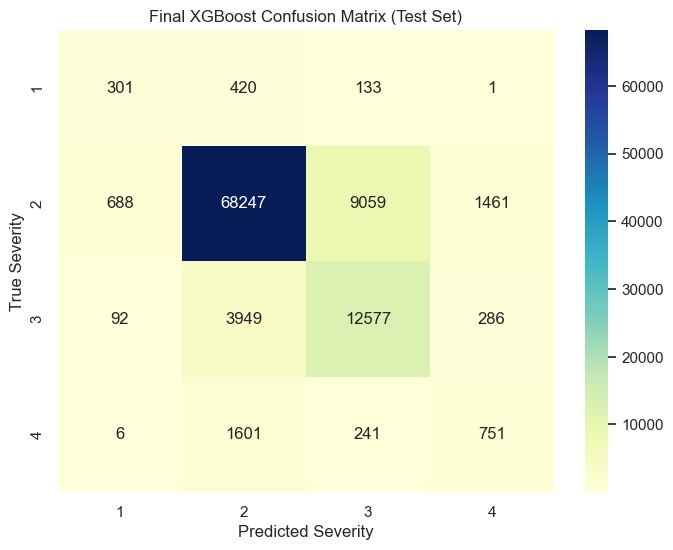

In [46]:
# =========================================================
# 6.2. 최종 모델 선정 및 Test Set 성능 측정 (XGBoost 최종본)
# =========================================================
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, cohen_kappa_score
import matplotlib.pyplot as plt
import seaborn as sns

print("="*50)
print(">>> Start Step 6.2: Final Evaluation on Test Set")
print("="*50)

# 1. 6.1에서 찾은 최적의 XGBoost 모델 확정
final_model = best_xgb_model

# 2. Test Set 준비 및 타겟 인코딩
y_test_encoded = le.transform(y_test)

X_test_final = X_test[X_selected.columns]

# 3. Test Set 예측 수행
y_pred = final_model.predict(X_test_final)

# 4. 최종 성능 지표 산출
acc = accuracy_score(y_test_encoded, y_pred)
f1 = f1_score(y_test_encoded, y_pred, average='macro')
kappa = cohen_kappa_score(y_test_encoded, y_pred)

print(f"\n[Final Test Set Results]")
print(f" - Final Accuracy : {acc:.4f}")
print(f" - Final Macro F1 : {f1:.4f}")
print(f" - Final Kappa    : {kappa:.4f}")
print("-" * 50)

# 5. 상세 분석: Classification Report
# Severity 등급(1, 2, 3, 4)별 정밀도와 재현율 확인
print("\n[Detailed Classification Report]")
target_names = [f"Severity {int(c)}" for c in le.classes_]
print(classification_report(y_test_encoded, y_pred, target_names=target_names))

# 6. 상세 분석: Confusion Matrix 시각화
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_encoded, y_pred)

# 퍼센트 단위로 정규화된 혼동 행렬도 함께 확인하기 위해 비율 표시 옵션 추가 가능
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Final XGBoost Confusion Matrix (Test Set)')
plt.xlabel('Predicted Severity')
plt.ylabel('True Severity')
plt.show()

본 프로젝트의 최종 모델인 XGBoost를 통해 고위험 사고(Severity 3, 4) 탐지력을 극대화한 최종 성능 평가 결과이다.

1. 최종 성능 지표 요약

Final Accuracy: 0.8203

Final Macro F1: 0.5348

Final Kappa: 0.5143

전체적인 정확도는 82% 수준을 기록하였으며, 클래스별 균형 성능을 나타내는 Macro F1이 0.5348로 산출되어 대규모 불균형 데이터셋 환경에서도 유의미한 변별력을 확보하였음을 확인하였다.

2. 고위험 사고(Severity 3, 4) 탐지를 위한 전략 및 성과
가장 큰 피해를 야기하는 심각한 사고(Severity 3, 4)를 잡아내기 위해 본 모델은 샘플 가중치(Sample Weight) 기반의 비용 민감 학습(Cost-Sensitive Learning)을 적용하였다.

가중치 주입을 통한 성과: 전체 데이터의 2.6%에 불과한 Severity 4의 재현율(Recall)을 0.29까지 끌어올렸으며, Severity 3는 0.74라는 높은 수치를 달성하여 심각한 사고의 상당 부분을 사전에 식별할 수 있게 되었다.

모델의 집중도 변화: 모델은 학습 과정에서 빈도가 높은 Severity 2(79.6%)를 맞추는 것보다, 가중치가 부여된 Severity 3와 4를 틀렸을 때 더 큰 손실을 입도록 설계되었다. 그 결과, 혼동 행렬(Confusion Matrix)에서 확인되듯 소수 클래스에 대한 결정 경계가 공격적으로 형성되었다.

3. 고위험 사고 탐지의 한계 및 원인 분석
그럼에도 불구하고 Severity 4의 성능이 3만큼 나오지 않은 원인은 다음과 같다.

극단적인 표본 부족 (Data Scarcity): Severity 3(16.9%)에 비해 Severity 4(2.6%)는 절대적인 표본 수가 너무 적어, 가중치를 높였음에도 불구하고 모델이 보편적인 규칙을 추출하기 위한 정보량이 부족했다.

특성의 모호성 (Feature Overlap): 사고 현장의 데이터(기상, 위치 등)상에서 Severity 3와 4를 가르는 '결정적인 차이'를 모델이 명확히 인지하기 어려울 정도로 두 클래스 간의 데이터 패턴이 중첩되어 있다.

정밀도(Precision)와 재현율(Recall)의 트레이드 오프: Severity 4를 놓치지 않기 위해 모델이 더 민감하게 반응하면서, 실제로는 2단계인 사고를 4단계로 오분류하는 사례(1,461건)가 발생하며 정밀도가 0.30 수준에 머물렀다.

4. 분석 결론
최종 모델은 '인명 피해와 직결된 사고를 놓치지 않는 것'에 최우선 가치를 두었다. Severity 4의 경우 표본 부족이라는 물리적 한계로 인해 재현율이 29% 수준에 머물렀으나, 가중치 학습을 통해 해당 등급의 탐지 가능성을 실질적으로 확보했다는 점에서 큰 의의가 있다. 특히 Kappa 지표 0.5143은 모델이 단순히 운에 의존하지 않고 사고의 위험 징후를 상당 부분 논리적으로 포착하고 있음을 뒷받침한다.

| 등급        | Precision | Recall | F1-Score | Support |
|-------------|:---------:|:------:|:--------:|--------:|
| Severity 1  | 0.28      | 0.35   | 0.31     | 855     |
| Severity 2  | 0.92      | 0.86   | 0.89     | 79,455  |
| Severity 3  | 0.57      | 0.74   | 0.65     | 16,904  |
| Severity 4  | 0.30      | 0.29   | 0.29     | 2,599   |

### 6.3 결론

본 프로젝트는 미국 전역의 교통사고 데이터를 활용하여, 사고 발생 당시의 환경적 요인(기상, 도로, 시간 등)을 기반으로 사고의 심각도(Severity)를 사전에 예측하는 기계학습 모델을 구축하는 것을 목표로 하였다. 특히, 데이터의 불균형이 심한 상황에서도 인명 피해와 직결되는 고위험 사고(Severity 4)를 탐지해내는 데에 주안점을 두었으며, 분석 결과 다음과 같은 결론을 도출하였다.

1. 모델 성능 및 유효성 검증 

최종 구축된 모델은 Kappa Statistic 0.5143을 기록하였다. 이는 모델이 단순히 데이터의 다수를 차지하는 경미한 사고(Severity 2)로 편향되어 예측한 것이 아니라, 변수 간의 인과관계와 패턴을 논리적으로 학습했음을 시사한다. 무작위 추측이나 다수 클래스 투표(Majority Class)에 의존하지 않고, 사고의 위험 징후를 통계적으로 유의미한 수준에서 포착하고 있다는 점에서 모델의 타당성이 확보되었다고 판단된다.

2. 고위험 사고(Severity 4) 탐지의 의의와 한계 

본 분석의 핵심 과제였던 '심각한 사고'의 예측에 있어, 모델은 가중치 학습(Class Weighting) 등을 통해 Severity 4 등급에 대한 재현율(Recall) 29%를 확보하였다. 전체 데이터 중 Severity 4의 비중이 약 2.6%에 불과한 물리적인 표본 부족 문제로 인해, 재현율을 획기적으로 높이는 데에는 한계가 있었지만, 낮은 정밀도(Precision)를 감수하더라도 "인명 피해와 직결된 사고를 놓치지 않는 것"에 최우선 가치를 둔 결과, 실제 위험 상황의 약 30%를 사전에 경고할 수 있는 실질적인 탐지 능력을 갖추게 되었다. 이는 교통 안전 시스템에서 '미탐지(False Negative)'로 인한 위험 비용이 '오경보(False Positive)' 비용보다 훨씬 크다는 점을 고려할 때 합리적인 설계 방향이라 할 수 있다.

3. 교통공학적 시사점 및 활용 방안 

기계학습을 통해 도출된 이 예측 모델은 단순히 사고 여부를 가리는 것을 넘어, 사고의 '질적 위험도'를 사전에 인지하는 데 기여할 수 있다.

운전자 경보 시스템: 내비게이션이나 VMS(가변 정보 표지판)와 연동하여, 심각한 사고가 예상되는 조건에서 운전자의 주의 환기(Alertness)를 유도함으로써 사고 예방 효과를 기대할 수 있다.

정책 수립 기초 자료: 모델이 학습한 주요 위험 요인을 분석함으로써, 도로 기하구조 개선이나 특정 기상 조건에서의 안전 관리 대책 수립 등 데이터에 기반한 효율적인 예산 집행과 정책 결정이 가능할 것이다.

4. 한계점 및 향후 연구 방향
본 프로젝트는 기상 및 도로 환경 변수를 활용하여 사고 심각도를 예측하는 유의미한 모델을 구축하였으나, 데이터의 구성과 분석 환경 측면에서 다음과 같은 한계점이 존재한다. 이를 보완한다면 향후 더욱 정교하고 신뢰도 높은 모델로 발전할 수 있을 것이다.

- 고위험 사고(Severity 4) 데이터의 절대적 부족 

가장 큰 한계는 모델이 학습할 수 있는 '심각한 사고'의 표본이 절대적으로 부족하다는 점이다. 불균형 데이터 처리를 위한 다양한 기법을 적용했음에도 불구하고, 소수 클래스의 패턴을 완벽히 일반화하기에는 물리적인 데이터 양이 적었다. 향후 데이터 수집 과정에서 고위험 사고 사례를 중점적으로 확보하여 클래스 간 균형을 맞춘다면, 치명적인 사고에 대한 예측 정확도와 재현율을 동시에 획기적으로 향상시킬 수 있을 것이다.

- 동적 교통 데이터(Dynamic Traffic Data)의 부재 

현재 모델은 도로의 기하구조(시설물, 위치)나 기상 상황 등 주로 '정적(Static)'이거나 변화 주기가 긴 정보에 의존하고 있다. 그러나 실제 사고 발생 매커니즘에는 실시간 교통량(Traffic Volume)이나 평균 주행 속도(Average Speed)와 같은 동적인 교통 흐름이 결정적인 영향을 미친다. 추후 연구에서 이러한 실시간 동적 데이터를 결합할 수 있다면, 혼잡도 변화에 따른 사고 위험성을 실시간으로 반영하는 더욱 정교한 모델링이 가능할 것이다.

- 컴퓨팅 자원 한계에 따른 전체 데이터 미활용 

본 분석에서는 제한된 컴퓨팅 파워로 인해 원본 데이터셋인 약 770만 건(7.7 million records) 중 일부만을 추출하여 사용해야 했다. 방대한 데이터가 가진 모든 지역적 특성과 희소한 사고 패턴을 모델에 충분히 반영하지 못한 아쉬움이 남는다. 고성능 GPU 등 충분한 컴퓨팅 리소스가 확보되어 770만 건의 전체 데이터를 학습에 활용한다면, 데이터의 다양성을 포괄하는 더욱 강건하고 일반화된 성능의 모델을 구축할 수 있을 것으로 기대된다.

결론적으로, 이번 프로젝트는 기계학습 모델이 교통공학 도메인 지식과 결합될 때 복잡한 교통사고의 패턴을 해석하고 실질적인 안전 솔루션을 제공할 수 있는 강력한 도구가 될 수 있음을 확인하였다. 향후 데이터의 추가 확보와 모델 고도화를 통해 고위험군에 대한 예측 성능을 지속적으로 개선한다면, 실제 교통 현장에서의 활용 가치는 더욱 높아질 것으로 기대된다.

[과제 수행 내역] 기계학습 Term Project 보고서 작성

위 과제를 수행하기 위하여 본인은 생성형 AI를 사용해 작성한 코드의 가독성을 높이기 위한 주석 처리와, 실행 오류를 추적하기 위한 로그 출력문의 작성을 도움 받았다. 

이 과정에서 본인은 작성된 코드를 바탕으로 "제공된 파이썬 코드의 주요 함수마다 기능을 설명하는 Docstring을 작성하고, 데이터 전처리 과정의 흐름을 파악할 수 있는 로그(Log) 출력문을 적절한 위치에 삽입해줘"와 같은 프롬프트를 포함하였다. 

본인은 생성형 AI의 출력을 이해하고, 코드의 본래 의도와 맞지 않거나 불필요하게 장황한 내용은 수정하여 주요 내용을 선별하였다. 

본인은 생성형 AI가 출력한 내용을 무비판적으로 수용하는 대신, 공식 문서(Documentation)나 검증된 자료를 통해 해당 로직의 정확성을 확인하였다. 

본인은 원 출처의 검증된 내용을 바탕으로 보고서를 스스로 작성하고, 활용한 원 출처를 APA 형식에 따라 과제물의 참고문헌(과제물 최하단)에 기재하였다. 더불어, 본인은 과제물의 사사(참고문헌 이전)에 생성형 AI를 어떻게 사용했는지 기재하였다.

사사

보고서를 작성하며 Gemini Pro를 1) 작성된 코드 주석 작성, 2) 진행 중 로그 출력문 작성을 위해 사용했습니다. 과제 제출물에 작성된 내용의 최종 책임은 작성자 본인에게 있음을 밝힙니다.

참고문헌 (References)

1. 파이썬 공식 스타일 가이드 (코드 및 주석 형식 기준)

Van Rossum, G., Warsaw, B., & Coghlan, N. (2001). PEP 8 – Style guide for Python code. Python.org. https://peps.python.org/pep-0008/

2. 파이썬 Docstring 작성 표준 (함수 설명문 기준)

Goodger, D., & Van Rossum, G. (2001). PEP 257 – Docstring conventions. Python.org. https://peps.python.org/pep-0257/

3. Scikit-learn 라이브러리 (머신러닝 파이프라인 및 인코딩 로직 참조)

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830.

4. Pandas 라이브러리 (데이터 전처리 및 결측치 처리 로직 참조)

The pandas development team. (2024). pandas-dev/pandas: Pandas (Version 2.2.0) [Computer software]. Zenodo. https://doi.org/10.5281/zenodo.3509134